# Gemma3-SD: Dual CLIP Scaffold → Native Gemma Conditioning for Stable Diffusion 1.5

Goal: migrate SD1.5 from CLIP conditioning to Gemma 3 270M native conditioning without relying on a CLIP-space linear bake.

Transition path:

```text
SD1.5 CLIP path intact
    + native Gemma cross-attention branch
    → train Gemma branch under CLIP scaffold
    → decay CLIP-teacher loss while student stays Gemma-only
    → prune to Gemma-only inference
```

CLIP is a training scaffold and teacher. Final target is no CLIP at inference.


## Section 0: Google Drive Mount

Mount Google Drive for saving all artifacts (probe, LoRA, samples, complete model).

In [1]:
# @title 0.1 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_OUT = '/content/drive/MyDrive/gemma3-sd'
os.makedirs(DRIVE_OUT, exist_ok=True)
print(f"Artifacts will be saved to: {DRIVE_OUT}")


Mounted at /content/drive
Artifacts will be saved to: /content/drive/MyDrive/gemma3-sd


## Section 1: Environment Setup

In [2]:
# @title 1.1 Simple install — Colab + Kohya, no Torch/NumPy changes

!pip install -q -U --upgrade-strategy only-if-needed \
  "Pillow==11.3.0" \
  "accelerate==1.6.0" \
  "transformers==4.54.1" \
  "diffusers[torch]==0.32.1" \
  "safetensors==0.4.5" \
  "datasets" \
  "peft" \
  "bitsandbytes" \
  "ftfy" \
  "einops" \
  "opencv-python==4.10.0.84" \
  "lion-pytorch" \
  "schedulefree" \
  "pytorch-optimizer" \
  "prodigyopt" \
  "prodigy-plus-schedule-free" \
  "toml" \
  "voluptuous" \
  "imagesize" \
  "rich" \
  "sentencepiece" \
  "wandb" \
  "matplotlib" \
  "tensorboard" \
  "tqdm"

!git clone --depth 1 https://github.com/kohya-ss/sd-scripts.git /content/sd-scripts 2>/dev/null || true
!pip install -q --no-deps -e /content/sd-scripts

# SaRA optimizer dependency for RUN_SARA_PHASE=True.
!git clone --depth 1 https://github.com/sjtuplayer/SaRA.git /content/SaRA 2>/dev/null || true
import sys
if "/content/SaRA" not in sys.path:
    sys.path.insert(0, "/content/SaRA")
from optim import adamw as sara_adamw
print("SaRA optimizer import PASS")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.8/434.8 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [3]:
import torch, numpy as np, PIL
import transformers, diffusers, accelerate

print("OK")
print("Torch:", torch.__version__, "CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("NumPy:", np.__version__)
print("Pillow:", PIL.__version__)
print("Transformers:", transformers.__version__)
print("Diffusers:", diffusers.__version__)

OK
Torch: 2.10.0+cu128 CUDA: 12.8
GPU: NVIDIA L4
NumPy: 2.0.2
Pillow: 11.3.0
Transformers: 4.54.1
Diffusers: 0.32.1


In [4]:
# @title 1.3 HuggingFace Login via Colab Secrets
from google.colab import userdata
import os
hf_token = userdata.get("HF_TOKEN")
if not hf_token:
    raise ValueError("Missing HF_TOKEN in Colab secrets. Add it via the key icon in the sidebar.")
os.environ["HF_TOKEN"] = hf_token
print("HF_TOKEN: verified")
print("HF_TOKEN loaded from Colab secrets.")
print("Make sure you accepted the Gemma license: https://huggingface.co/google/gemma-3-270m-it")


HF_TOKEN: verified
HF_TOKEN loaded from Colab secrets.
Make sure you accepted the Gemma license: https://huggingface.co/google/gemma-3-270m-it


In [ ]:
# @title 1.4 Run Configuration + wandb via Colab Secrets
import wandb
import os
from datetime import datetime

# Modes:
#   diagnostic   = run smoke diagnostics only; training cells skip.
#   overfit_train = connector-only overfit on 64 repeated images (frozen UNet/Gemma/VAE).
#   short_train  = diagnostics + modest train run (dual_native path).
#   full_train   = diagnostics + longer train run using same code paths.
RUN_MODE = "full_train"  # @param ["diagnostic", "overfit_train", "short_train", "full_train"]
RUN_TRAINING = RUN_MODE in {"overfit_train", "short_train", "full_train"}
RUN_DIAGNOSTICS = True
RUN_FINAL_PROOF = True
RUN_FIXED_VALIDATION_GRIDS = True

# ── Conditioning architecture ──
# dual_native:                  existing Gemma cross-attn branch inside UNet (surgery path).
# ella_gemma_connector:         frozen original UNet cross-attn + trainable timestep-aware
#                               Perceiver connector (ELLA-style). No UNet surgery.
# gemma_clip_semantic_adapter:  frozen original UNet cross-attn + Gemma→CLIP-state adapter.
CONDITIONING_ARCH = "gemma_clip_semantic_adapter"  # @param ["dual_native", "ella_gemma_connector", "gemma_clip_semantic_adapter"]
print(f"CONDITIONING_ARCH = {CONDITIONING_ARCH}")

BASE_SEED = 1234

# ── Mode-dependent defaults ──
if RUN_MODE == "overfit_train":
    MAX_SAMPLES_WARMUP = 64
    MAX_SAMPLES_PHASEB = 64
    FULLRANK_EPOCHS = 40
    PHASEB_EPOCHS = 0
    PHASE_A_MAX_OPT_STEPS = 300
    PHASE_B_MAX_OPT_STEPS = 0
    TEACHER_DECAY_STEPS = 300
    VALIDATION_EVERY_OPT_STEPS = 50
    SHUFFLE_STREAMING = False
elif RUN_MODE == "short_train":
    MAX_SAMPLES_WARMUP = 15_000
    MAX_SAMPLES_PHASEB = 15_000
    FULLRANK_EPOCHS = 1
    PHASEB_EPOCHS = 1
    PHASE_A_MAX_OPT_STEPS = 100
    PHASE_B_MAX_OPT_STEPS = 200
    TEACHER_DECAY_STEPS = 200
    VALIDATION_EVERY_OPT_STEPS = 50
    SHUFFLE_STREAMING = True
elif RUN_MODE == "full_train":
    MAX_SAMPLES_WARMUP = 10_000
    MAX_SAMPLES_PHASEB = 10_000
    FULLRANK_EPOCHS = 2
    PHASEB_EPOCHS = 1
    PHASE_A_MAX_OPT_STEPS = None
    PHASE_B_MAX_OPT_STEPS = None
    TEACHER_DECAY_STEPS = 1000
    VALIDATION_EVERY_OPT_STEPS = 250
    SHUFFLE_STREAMING = True
elif RUN_MODE == "diagnostic":
    MAX_SAMPLES_WARMUP = 128
    MAX_SAMPLES_PHASEB = 128
    FULLRANK_EPOCHS = 0
    PHASEB_EPOCHS = 0
    PHASE_A_MAX_OPT_STEPS = 0
    PHASE_B_MAX_OPT_STEPS = 0
    TEACHER_DECAY_STEPS = 200
    VALIDATION_EVERY_OPT_STEPS = 0
    SHUFFLE_STREAMING = True
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

VALIDATION_TRAINING_STEPS = 20  # cheaper than final 30-step proof grids
VRAM_LOG_EVERY_OPT_STEPS = 50

FULLRANK_LR = 1e-5
PHASEB_LR = 5e-5
TRAIN_BATCH_SIZE = 4  # dataset batch; text-delta internally runs cond/uncond pairs, so UNet batch is 2x this
GRADIENT_ACCUMULATION_STEPS = 4
LAMBDA_DIFFUSION = 0.25
LAMBDA_TEXT_DELTA = 1.0
TEXT_DELTA_ENABLED = True

SHUFFLE_BUFFER = 10_000
SKIP_CLIP_COMPUTE_WHEN_ZERO = True

# ── ELLA-style connector config (used when CONDITIONING_ARCH == "ella_gemma_connector") ──
GEMMA_CONNECTOR_INPUT_DIM = 640
GEMMA_CONNECTOR_WIDTH = 768
GEMMA_CONNECTOR_OUTPUT_DIM = 768
GEMMA_CONNECTOR_LAYERS = 2
GEMMA_CONNECTOR_HEADS = 8
GEMMA_CONNECTOR_NUM_LATENTS = 64
GEMMA_CONNECTOR_TIME_CHANNEL = 320
GEMMA_CONNECTOR_TIME_EMBED_DIM = 768
CONNECTOR_LR = 1e-4

# ── Gemma→CLIP semantic adapter config (used when CONDITIONING_ARCH == "gemma_clip_semantic_adapter") ──
RUN_SEMANTIC_ADAPTER_TRAIN = CONDITIONING_ARCH == "gemma_clip_semantic_adapter"
# Phase A is always 77-token Gemma→CLIP reconstruction only.
# RUN_LONG_TOKEN_PHASE means: after Phase A, add extra conditioning tokens and train that path with sparse UNet adaptation.
RUN_TIMESTEP_RESIDUAL = False
RUN_LONG_TOKEN_PHASE = True
RUN_SARA_PHASE = True

SEMANTIC_NUM_TOKENS = 77
SEMANTIC_WIDTH = 768
SEMANTIC_LAYERS = 4
SEMANTIC_HEADS = 8
SEMANTIC_FF_MULT = 4
SEMANTIC_DROPOUT = 0.0
SEMANTIC_LR = 1e-4
SEMANTIC_MAX_OPT_STEPS = None if RUN_MODE == "full_train" else 500
SEMANTIC_VALIDATE_EVERY = 50
SEM_W_MSE = 1.0
SEM_W_COS = 0.5
SEM_W_NORM = 0.25
SEM_W_CONTRASTIVE = 0.2
SEM_CONTRASTIVE_TEMP = 0.07

TIMESTEP_RESIDUAL_LAYERS = 2
TIMESTEP_RESIDUAL_GATE_INIT = -4.0
LONG_CONTEXT_TOTAL_TOKENS = 128
LONG_EXTRA_TOKENS = LONG_CONTEXT_TOTAL_TOKENS - SEMANTIC_NUM_TOKENS
LONG_EXTRA_GATE_INIT = -5.0
LONG_TOKEN_EPOCHS = 1
LONG_TOKEN_MAX_OPT_STEPS = 1000 if RUN_MODE == "full_train" else 200
LONG_TOKEN_LR = 5e-5
LONG_TOKEN_UNET_LOSS_WEIGHT = 1.0
LONG_TOKEN_ANCHOR_LOSS_WEIGHT = 0.25

SARA_SCOPE = "whole_unet_sparse"
SARA_THRESHOLD = 1e-3
SARA_PROGRESSIVE_ITER = 100
SARA_LAMBDA_RANK = 0.0005
SARA_LR = 1e-5
SARA_WEIGHT_DECAY = 1e-2
SARA_MAX_SPARSE_FRACTION_WARN = 0.02
SARA_MAX_SPARSE_FRACTION_ABORT = 0.05

VAL_PROMPTS = [
    "a cat sitting on a windowsill looking outside",
    "a watercolor painting of a mountain lake",
    "a neon-lit cyberpunk alleyway at night",
]

# Long-token eval prompts differ after the first CLIP-length prefix. The short controls
# intentionally omit late attributes so 77-token vs 128-token behavior is comparable.
LONG_EVAL_PROMPTS = [
    "a cinematic photo of a red vintage motorcycle parked beside a stone cottage, "
    "with a brass telescope on the seat, blue wildflowers in the basket, and a tiny owl perched on the handlebar at sunrise",
    "a detailed product photograph of hiking boots on a wooden table, "
    "with orange laces, a folded trail map, a silver compass, and raindrops on the leather",
]
LONG_EVAL_SHORT_CONTROLS = [
    "a cinematic photo of a red vintage motorcycle parked beside a stone cottage",
    "a detailed product photograph of hiking boots on a wooden table",
]
LONG_EVAL_CHECKLIST = [
    ["brass telescope", "blue wildflowers", "tiny owl", "sunrise"],
    ["orange laces", "folded trail map", "silver compass", "raindrops"],
]
DIAGNOSTIC_PROMPTS = [
    "a red sports car on a city street",
    "a snowy mountain at dawn",
    "an underwater coral reef with colorful fish",
    "a rustic Italian kitchen with tomatoes",
    "abstract geometric shapes in neon colors",
]
VAL_SEED = 42
VAL_STEPS = 30
VAL_GUIDANCE = 5.0

TEST_NEGATIVE_PROMPT = "(bonnet), (hat), (beanie), cap, (((wide shot))), (cropped head), bad framing, out of frame, deformed, cripple, old, fat, ugly, poor, missing arm, additional arms, additional legs, additional head, additional face, multiple people, group of people, dyed hair, black and white, grayscale"
TEST_GENERATION_CASES = [
    {
        "name": "retrofuturism_cars_popular_mechanics",
        "prompt": "highly detailed infographic of retrofuturism cars found in popular mechanics magazine | vintage | intricate detail | digital art | digital painting | concept art | poster | award winning | max detail",
        "negative_prompt": TEST_NEGATIVE_PROMPT,
        "steps": 30,
        "guidance": 7.0,
        "sampler": "DPM++ SDE Karras",
        "seed": 3197632166,
        "width": 768,
        "height": 960,
    },
    {
        "name": "warrior_princess_poster",
        "prompt": "poster of warrior princess| standing on hill | centered| key visual| intricate| highly detailed| breathtaking| precise lineart| vibrant| panoramic| cinematic| Carne Griffiths| Conrad Roset",
        "negative_prompt": TEST_NEGATIVE_PROMPT,
        "steps": 30,
        "guidance": 7.0,
        "sampler": "DPM++ SDE Karras",
        "seed": 4267154965,
        "width": 768,
        "height": 960,
    },
]

# Overfit validation should use exact training captions first; generic VAL_PROMPTS are controls.
OVERFIT_VALIDATION_PROMPTS_N = 4
TRAIN_VAL_PROMPTS = []

RUN_CONFIG = {
    "run_mode": RUN_MODE,
    "conditioning_arch": CONDITIONING_ARCH,
    "model": "Gemma 3 270M → SD 1.5 dual CLIP-teacher/Gemma-student",
    "gemma_hidden_size": 640,
    "original_cross_attn_dim": 768,
    "new_cross_attn_dim": 640,
    "max_prompt_length": 77,
    "fullrank_epochs": FULLRANK_EPOCHS,
    "phaseb_epochs": PHASEB_EPOCHS,
    "max_samples_warmup": MAX_SAMPLES_WARMUP,
    "max_samples_phaseb": MAX_SAMPLES_PHASEB,
    "fullrank_lr": FULLRANK_LR,
    "phaseb_lr": PHASEB_LR,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "paired_unet_batch_size": 2 * TRAIN_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "phase_a_max_opt_steps": PHASE_A_MAX_OPT_STEPS,
    "phase_b_max_opt_steps": PHASE_B_MAX_OPT_STEPS,
    "teacher_decay_steps": TEACHER_DECAY_STEPS,
    "validation_every_opt_steps": VALIDATION_EVERY_OPT_STEPS,
    "validation_training_steps": VALIDATION_TRAINING_STEPS,
    "vram_log_every_opt_steps": VRAM_LOG_EVERY_OPT_STEPS,
    "lambda_diffusion": LAMBDA_DIFFUSION,
    "lambda_text_delta": LAMBDA_TEXT_DELTA,
    "text_delta_enabled": TEXT_DELTA_ENABLED,
    "shuffle_streaming": SHUFFLE_STREAMING,
    "shuffle_buffer": SHUFFLE_BUFFER,
    "skip_clip_compute_when_zero": SKIP_CLIP_COMPUTE_WHEN_ZERO,
    "phase_a_trainables": "semantic_adapter_only" if CONDITIONING_ARCH == "gemma_clip_semantic_adapter" else ("connector-only" if CONDITIONING_ARCH == "ella_gemma_connector" else "gemma_norm + gemma_attn.to_k/to_v full-rank"),
    "phase_b_trainables": "semantic_optional_residual_longtoken_sara" if CONDITIONING_ARCH == "gemma_clip_semantic_adapter" else ("connector-only (skip)" if CONDITIONING_ARCH == "ella_gemma_connector" else "K/V LoRA + gemma_norm + gemma_attn.to_out[0]"),
    "device": str(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else "cpu",
    "connector_layers": GEMMA_CONNECTOR_LAYERS if CONDITIONING_ARCH == "ella_gemma_connector" else 0,
    "connector_num_latents": GEMMA_CONNECTOR_NUM_LATENTS if CONDITIONING_ARCH == "ella_gemma_connector" else 0,
    "connector_width": GEMMA_CONNECTOR_WIDTH if CONDITIONING_ARCH == "ella_gemma_connector" else 0,
    "run_semantic_adapter_train": RUN_SEMANTIC_ADAPTER_TRAIN,
    "run_timestep_residual": RUN_TIMESTEP_RESIDUAL,
    "run_long_token_phase": RUN_LONG_TOKEN_PHASE,
    "run_sara_phase": RUN_SARA_PHASE,
    "semantic_num_tokens": SEMANTIC_NUM_TOKENS if CONDITIONING_ARCH == "gemma_clip_semantic_adapter" else 0,
    "semantic_width": SEMANTIC_WIDTH if CONDITIONING_ARCH == "gemma_clip_semantic_adapter" else 0,
    "semantic_layers": SEMANTIC_LAYERS if CONDITIONING_ARCH == "gemma_clip_semantic_adapter" else 0,
    "semantic_lr": SEMANTIC_LR if CONDITIONING_ARCH == "gemma_clip_semantic_adapter" else 0,
    "semantic_max_opt_steps": SEMANTIC_MAX_OPT_STEPS if CONDITIONING_ARCH == "gemma_clip_semantic_adapter" else 0,
    "long_context_total_tokens": LONG_CONTEXT_TOTAL_TOKENS if RUN_LONG_TOKEN_PHASE else SEMANTIC_NUM_TOKENS,
    "long_token_epochs": LONG_TOKEN_EPOCHS if RUN_LONG_TOKEN_PHASE else 0,
    "long_token_max_opt_steps": LONG_TOKEN_MAX_OPT_STEPS if RUN_LONG_TOKEN_PHASE else 0,
    "long_token_lr": LONG_TOKEN_LR if RUN_LONG_TOKEN_PHASE else 0,
    "sara_scope": SARA_SCOPE if RUN_SARA_PHASE else "disabled",
}

# Load wandb key from Colab secrets
wb_key = userdata.get("WANDB_API_KEY") or userdata.get("WANDB_KEY")
if wb_key is None:
    raise ValueError("Missing WANDB_API_KEY or WANDB_KEY in Colab secrets.")
os.environ["WANDB_API_KEY"] = wb_key
print("WANDB_API_KEY loaded from Colab secrets.")

run_name = f"gemma3-sd-{RUN_MODE}-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
wandb.init(project="gemma3-stable-diffusion", name=run_name, config=RUN_CONFIG)
print(f"wandb run: {wandb.run.name}")
print("Run config:")
for k, v in RUN_CONFIG.items():
    print(f"  {k}: {v}")


In [6]:
# @title 2.1 Load Gemma 3 270M
from transformers import AutoTokenizer, AutoModelForCausalLM

device = torch.device("cuda")
MAX_GEMMA_LEN = 77  # Start at SD1.5's CLIP length. Extend only after Gemma-only works.
GEMMA_LAYER_INDEX = -1  # TODO experiment with middle/upper layers after baseline works.

print("Loading Gemma 3 270M...")
gemma_path = "google/gemma-3-270m"
gemma_tokenizer = AutoTokenizer.from_pretrained(gemma_path, token=os.environ.get("HF_TOKEN"))
if gemma_tokenizer.pad_token is None:
    gemma_tokenizer.pad_token = gemma_tokenizer.eos_token

gemma_model = AutoModelForCausalLM.from_pretrained(
    gemma_path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=os.environ.get("HF_TOKEN"),
    low_cpu_mem_usage=True,
).eval()
for p in gemma_model.parameters():
    p.requires_grad = False

gemma_hidden_size = gemma_model.config.hidden_size  # 640 for Gemma 3 270M
print(f"  Gemma hidden_size: {gemma_hidden_size}")
print(f"  Gemma dtype: {next(gemma_model.parameters()).dtype}")
print(f"  Gemma layer index for conditioning: {GEMMA_LAYER_INDEX}")
print("  Gemma frozen. Native Gemma cross-attention branch will learn to read these states.")


Loading Gemma 3 270M...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/133 [00:00<?, ?B/s]

  Gemma hidden_size: 640
  Gemma dtype: torch.bfloat16
  Gemma layer index for conditioning: -1
  Gemma frozen. Native Gemma cross-attention branch will learn to read these states.


## Section 2B: Dual Encoder Setup

CLIP remains loaded during transition as a scaffold/teacher. Gemma gets its own native cross-attention branch; we do not solve a static CLIP/Gemma linear mapping.


In [7]:
# @title 2.2 Load CLIP Persistently (training scaffold / teacher)
from transformers import CLIPTextModel, CLIPTokenizer

CLIP_ID = "openai/clip-vit-large-patch14"
print(f"Loading CLIP scaffold: {CLIP_ID}")
clip_tokenizer = CLIPTokenizer.from_pretrained(CLIP_ID)
clip_model = CLIPTextModel.from_pretrained(
    CLIP_ID,
    torch_dtype=torch.float16,
).to(device).eval()
for p in clip_model.parameters():
    p.requires_grad = False

clip_hidden_size = clip_model.config.hidden_size  # 768 for ViT-L/14
print(f"  CLIP hidden size: {clip_hidden_size}")
print(f"  Gemma hidden size: {gemma_hidden_size}")
assert clip_hidden_size == 768, "SD1.5 UNet expects CLIP hidden size 768"
assert gemma_hidden_size == 640, "Gemma 3 270M expected hidden size 640"
print("  CLIP frozen. It is a teacher/scaffold only; final inference uses the pruned Gemma-only checkpoint.")


Loading CLIP scaffold: openai/clip-vit-large-patch14


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

  CLIP hidden size: 768
  Gemma hidden size: 640
  CLIP frozen. It is a teacher/scaffold only; final inference uses the pruned Gemma-only checkpoint.


## Legacy linear bake removed

The previous static ridge/bake route is intentionally removed from the mainline. Runtime evidence showed the linear map collapsed to near-zero signal, so this notebook now learns native Gemma attention behavior through the UNet instead.


## No static embedding target

We do not train Gemma to imitate CLIP embeddings. Gemma remains frozen and supplies hidden states; the UNet learns a native Gemma-conditioning branch under a frozen CLIP teacher/scaffold.


## Section 3: Dual Cross-Attention UNet Setup

Every SD1.5 cross-attention block keeps its original CLIP `attn2` path and gains a parallel Gemma-native attention path. `clip_scale` and `gemma_scale` control the transition.


In [8]:
# @title 3.1 Load StyleJourney SD UNet + VAE + Scheduler from Colab safetensors
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, AutoencoderKL, DDPMScheduler
import os, gc

# Local Colab checkpoint requested for this run.
# Put the file at /content/models/stylejourney_v10.safetensors.
# If your Colab runtime mounted it as /models/stylejourney_v10.safetensors, the resolver below also accepts that.
SD_BASE_ID = "runwayml/stable-diffusion-v1-5"  # only a compatibility label/fallback for SD1.5-shaped config
SD_CHECKPOINT_CANDIDATES = [
    "/content/drive/MyDrive/model/stylejourney_v10.safetensors",
    "/models/stylejourney_v10.safetensors",
]


def resolve_sd_checkpoint():
    for path in SD_CHECKPOINT_CANDIDATES:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(
        "stylejourney_v10.safetensors not found. Upload/copy it to one of: "
        + ", ".join(SD_CHECKPOINT_CANDIDATES)
    )


SD_CHECKPOINT = resolve_sd_checkpoint()
SD_ID = SD_CHECKPOINT  # downstream metadata/reload cells should point at the actual local checkpoint
print(f"Loading Stable Diffusion checkpoint from: {SD_CHECKPOINT}")


def load_stylejourney_components(torch_dtype=torch.float32, target_device=device):
    """Load local StyleJourney safetensors once, then extract UNet/VAE/scheduler.

    Diffusers loads .safetensors checkpoints through StableDiffusionPipeline.from_single_file.
    We immediately drop text encoder/tokenizer/safety-checker because this notebook uses
    its own CLIP teacher and final Gemma-only conditioning path.
    """
    pipe = StableDiffusionPipeline.from_single_file(
        SD_CHECKPOINT,
        torch_dtype=torch_dtype,
        safety_checker=None,
        requires_safety_checker=False,
    )
    base_unet = pipe.unet.to(target_device)
    base_vae = pipe.vae.to(target_device).eval()
    train_scheduler = DDPMScheduler.from_config(pipe.scheduler.config)

    # Drop unused pipeline parts to reduce VRAM/RAM pressure after extracting modules.
    pipe.text_encoder = None
    pipe.tokenizer = None
    pipe.safety_checker = None
    del pipe
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return base_unet, base_vae, train_scheduler


# Keep UNet/VAE fp32 for stability; trainable Gemma branch is small enough for L4/T4 class GPUs.
unet, vae, scheduler = load_stylejourney_components(torch_dtype=torch.float32, target_device=device)

unet_dtype = next(unet.parameters()).dtype
print(f"  UNet cross_attention_dim: {unet.config.cross_attention_dim}")  # 768 for SD1.x checkpoints
print(f"  UNet dtype: {unet_dtype}")
print(f"  VAE dtype: {next(vae.parameters()).dtype}")
print("  Original CLIP-sized cross-attention remains intact, initialized from StyleJourney.")


Loading Stable Diffusion checkpoint from: /content/drive/MyDrive/model/stylejourney_v10.safetensors


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Some weights of the model checkpoint were not used when initializing CLIPTextModel: 
 ['text_model.embeddings.position_ids']
In this conversion only the non-EMA weights are extracted. If you want to instead extract the EMA weights (usually better for inference), please make sure to add the `--extract_ema` flag.


  UNet cross_attention_dim: 768
  UNet dtype: torch.float32
  VAE dtype: torch.float32
  Original CLIP-sized cross-attention remains intact, initialized from StyleJourney.


In [9]:
# @title 3.2 UNet Surgery: Add Dual Native Gemma Cross-Attention

if CONDITIONING_ARCH == "dual_native":
    # @title 3.2 UNet Surgery: Add Dual Native Gemma Cross-Attention
    import math
    import torch.nn as nn
    from diffusers.models.attention_processor import Attention

    class DualNativeAttention(nn.Module):
        """Original CLIP cross-attn plus parallel native Gemma cross-attn.

        CLIP path is the untouched SD1.5 attn2 module.
        Gemma path is a new Attention module with cross_attention_dim=gemma_hidden_size.
        The output is a scheduled weighted sum. CLIP can later be pruned structurally.
        """
        def __init__(self, clip_attn, gemma_dim, dtype=None, device=None):
            super().__init__()
            self.clip_attn = clip_attn
            self.gemma_dim = int(gemma_dim)
            query_dim = clip_attn.to_q.in_features
            inner_dim = clip_attn.to_k.out_features
            heads = int(clip_attn.heads)
            dim_head = inner_dim // heads
            out_bias = clip_attn.to_out[0].bias is not None
            dtype = dtype or clip_attn.to_k.weight.dtype
            device = device or clip_attn.to_k.weight.device

            self.gemma_norm = nn.LayerNorm(self.gemma_dim, device=device, dtype=dtype)
            self.gemma_attn = Attention(
                query_dim=query_dim,
                cross_attention_dim=self.gemma_dim,
                heads=heads,
                dim_head=dim_head,
                bias=True,       # Keep Gemma K/V bias; recreate Q below if source Q is biasless.
                out_bias=out_bias,
            ).to(device=device, dtype=dtype)

            def clone_linear_shape(src_linear):
                return nn.Linear(
                    src_linear.in_features,
                    src_linear.out_features,
                    bias=src_linear.bias is not None,
                    device=device,
                    dtype=dtype,
                )

            # Copy SD1.5 image-side projections (Q and OUT) into Gemma branch.
            # Preserve source bias/no-bias exactly; Diffusers SD1.5 Q is often biasless,
            # while Attention(bias=True) would otherwise create a mismatched Q bias.
            self.gemma_attn.to_q = clone_linear_shape(self.clip_attn.to_q)
            self.gemma_attn.to_q.load_state_dict(self.clip_attn.to_q.state_dict(), strict=True)
            self.gemma_attn.to_out[0].load_state_dict(self.clip_attn.to_out[0].state_dict(), strict=True)
            for mod in [self.gemma_attn.to_k, self.gemma_attn.to_v]:
                if hasattr(mod, "weight") and mod.weight is not None:
                    nn.init.normal_(mod.weight, mean=0.0, std=0.02)
                if hasattr(mod, "bias") and mod.bias is not None:
                    nn.init.zeros_(mod.bias)

            self.register_buffer("clip_scale", torch.tensor(1.0, dtype=torch.float32), persistent=True)
            self.register_buffer("gemma_scale", torch.tensor(0.0, dtype=torch.float32), persistent=True)

        def set_scales(self, clip_scale=None, gemma_scale=None):
            if clip_scale is not None:
                self.clip_scale.fill_(float(clip_scale))
            if gemma_scale is not None:
                self.gemma_scale.fill_(float(gemma_scale))

        def forward(self, hidden_states, encoder_hidden_states=None, attention_mask=None, **cross_attention_kwargs):
            # Do not mutate the shared kwargs dict flowing through all transformer blocks.
            kwargs = dict(cross_attention_kwargs or {})
            # Prefer module-local context to avoid global cross_attention_kwargs leaking into
            # Diffusers self-attention processors and causing repeated "ignored" warnings.
            gemma_encoder_hidden_states = kwargs.pop("gemma_encoder_hidden_states", None)
            if gemma_encoder_hidden_states is None:
                gemma_encoder_hidden_states = getattr(self, "_gemma_encoder_hidden_states", None)
            gemma_attention_mask = kwargs.pop("gemma_attention_mask", None)
            if gemma_attention_mask is None:
                gemma_attention_mask = getattr(self, "_gemma_attention_mask", None)
            clip_scale = float(kwargs.pop("clip_scale", self.clip_scale.item()))
            gemma_scale = float(kwargs.pop("gemma_scale", self.gemma_scale.item()))

            # When clip_scale == 0 the student path is genuinely CLIP-free inside
            # the attention block. The caller may still pass CLIP-shaped tensors for
            # Diffusers API compatibility, but this branch does not compute CLIP attn.
            skip_clip_compute = globals().get("SKIP_CLIP_COMPUTE_WHEN_ZERO", True)
            clip_out = None
            if clip_scale != 0.0 or not skip_clip_compute:
                clip_out = self.clip_attn(
                    hidden_states,
                    encoder_hidden_states=encoder_hidden_states,
                    attention_mask=attention_mask,
                    **kwargs,
                )

            if gemma_encoder_hidden_states is None or gemma_scale == 0.0:
                if clip_out is None:
                    raise ValueError("No active conditioning path: clip_scale=0 and gemma path disabled")
                return clip_out * clip_scale

            gemma_states = self.gemma_norm(gemma_encoder_hidden_states.to(dtype=hidden_states.dtype))
            if gemma_attention_mask is not None:
                # Side-channel Gemma masks bypass UNet's encoder_attention_mask preprocessing.
                # Tokenizers return int64 masks; Torch SDPA requires bool/float/query dtype.
                # Boolean keeps tokenizer semantics: True/1 = attend, False/0 = masked.
                gemma_attention_mask = gemma_attention_mask.to(device=hidden_states.device, dtype=torch.bool)
            gemma_out = self.gemma_attn(
                hidden_states,
                encoder_hidden_states=gemma_states,
                attention_mask=gemma_attention_mask,
                **kwargs,
            )
            if clip_out is None:
                return gemma_out * gemma_scale
            return clip_out * clip_scale + gemma_out * gemma_scale


    class GemmaOnlyAttention(nn.Module):
        """Pruned inference wrapper: preserves trained Gemma normalization plus Gemma attention."""
        def __init__(self, gemma_norm, gemma_attn):
            super().__init__()
            self.gemma_norm = gemma_norm
            self.gemma_attn = gemma_attn

        def forward(self, hidden_states, encoder_hidden_states=None, attention_mask=None, **cross_attention_kwargs):
            if encoder_hidden_states is None:
                raise ValueError("GemmaOnlyAttention requires Gemma encoder_hidden_states")
            gemma_states = self.gemma_norm(encoder_hidden_states.to(dtype=hidden_states.dtype))
            if attention_mask is not None and attention_mask.dtype not in (torch.bool, hidden_states.dtype):
                # Pruned Gemma-only paths may receive tokenizer int64 masks directly.
                attention_mask = attention_mask.to(device=hidden_states.device, dtype=torch.bool)
            elif attention_mask is not None:
                attention_mask = attention_mask.to(device=hidden_states.device)
            kwargs = dict(cross_attention_kwargs or {})
            kwargs.pop("gemma_encoder_hidden_states", None)
            kwargs.pop("gemma_attention_mask", None)
            kwargs.pop("clip_scale", None)
            kwargs.pop("gemma_scale", None)
            return self.gemma_attn(
                hidden_states,
                encoder_hidden_states=gemma_states,
                attention_mask=attention_mask,
                **kwargs,
            )


    def is_dual_native_attention_module(module):
        """Robust across notebook cell re-execution where class identity changes."""
        return (
            hasattr(module, "clip_attn")
            and hasattr(module, "gemma_attn")
            and hasattr(module, "gemma_norm")
            and hasattr(module, "set_scales")
        )


    def count_trainable_params(model):
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        return trainable, total


    def print_trainable_summary(model, label="trainable summary"):
        groups = {
            "gemma_norm": 0,
            "gemma_to_k": 0,
            "gemma_to_v": 0,
            "gemma_to_q": 0,
            "gemma_to_out": 0,
            "lora": 0,
            "other_trainable": 0,
        }
        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue
            n = p.numel()
            if "lora_" in name:
                groups["lora"] += n
            elif "gemma_norm" in name:
                groups["gemma_norm"] += n
            elif "gemma_attn.to_k" in name:
                groups["gemma_to_k"] += n
            elif "gemma_attn.to_v" in name:
                groups["gemma_to_v"] += n
            elif "gemma_attn.to_q" in name:
                groups["gemma_to_q"] += n
            elif "gemma_attn.to_out" in name:
                groups["gemma_to_out"] += n
            else:
                groups["other_trainable"] += n
        trainable, total = count_trainable_params(model)
        print(f"{label}: {trainable:,} / {total:,} trainable ({100*trainable/max(total,1):.4f}%)")
        for k, v in groups.items():
            if v:
                print(f"  {k}: {v:,}")
        wandb.log({f"params/{label.replace(' ', '_')}_trainable": trainable,
                   f"params/{label.replace(' ', '_')}_total": total,
                   **{f"params/{label.replace(' ', '_')}_{k}": v for k, v in groups.items()}})
        return groups


    def count_modules_by_predicate(model, pred):
        return sum(1 for module in model.modules() if pred(module))


    def is_gemma_only_attention_module(module):
        """Structural predicate robust to Colab class re-execution."""
        return (
            hasattr(module, "gemma_attn")
            and hasattr(module, "gemma_norm")
            and not hasattr(module, "clip_attn")
        )


    def apply_dual_native_attention(model, gemma_dim):
        replacements = 0
        for name, module in model.named_modules():
            if hasattr(module, "attn2") and module.attn2 is not None:
                if not is_dual_native_attention_module(module.attn2):
                    module.attn2 = DualNativeAttention(
                        module.attn2,
                        gemma_dim=gemma_dim,
                        dtype=next(model.parameters()).dtype,
                        device=next(model.parameters()).device,
                    )
                    replacements += 1
        return replacements


    def set_dual_attention_scales(model, clip_scale=1.0, gemma_scale=0.0):
        count = 0
        for module in model.modules():
            if is_dual_native_attention_module(module):
                module.set_scales(clip_scale=clip_scale, gemma_scale=gemma_scale)
                count += 1
        return count


    def set_dual_attention_context(model, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=None, gemma_scale=None):
        """Set Gemma context directly on dual-attn modules; avoids noisy global cross_attention_kwargs."""
        count = 0
        for module in model.modules():
            if is_dual_native_attention_module(module):
                module._gemma_encoder_hidden_states = gemma_encoder_hidden_states
                module._gemma_attention_mask = gemma_attention_mask
                module.set_scales(clip_scale=clip_scale, gemma_scale=gemma_scale)
                count += 1
        if count == 0:
            raise RuntimeError("No dual native attention modules found while setting context")
        return count


    def clear_dual_attention_context(model):
        for module in model.modules():
            if is_dual_native_attention_module(module):
                module._gemma_encoder_hidden_states = None
                module._gemma_attention_mask = None


    def freeze_all_but_gemma_branch(model):
        """Phase A trainables: gemma_norm + gemma_attn.to_k/to_v only (freeze to_q/to_out initially)."""
        for p in model.parameters():
            p.requires_grad = False
        trainable = []
        wrapped = 0
        for name, module in model.named_modules():
            if is_dual_native_attention_module(module):
                wrapped += 1
                for p in module.gemma_norm.parameters():
                    p.requires_grad = True
                    trainable.append(p)
                for p in module.gemma_attn.to_k.parameters():
                    p.requires_grad = True
                    trainable.append(p)
                for p in module.gemma_attn.to_v.parameters():
                    p.requires_grad = True
                    trainable.append(p)
        if wrapped == 0:
            raise RuntimeError("No dual native attention modules found. Rerun cells 3.1, 3.2, 3.3 before training; do not run save/prune before warmup.")
        if len(trainable) == 0:
            raise RuntimeError(f"Found {wrapped} dual modules but zero trainable Gemma params")
        return trainable


    def unfreeze_gemma_to_out(model):
        """Phase B optional: additionally unfreeze Gemma branch output projection."""
        trainable = []
        wrapped = 0
        for module in model.modules():
            if is_dual_native_attention_module(module):
                wrapped += 1
                for p in module.gemma_attn.to_out[0].parameters():
                    p.requires_grad = True
                    trainable.append(p)
        if wrapped == 0:
            raise RuntimeError("No dual native attention modules found")
        return trainable


    def prune_to_gemma_only(model, gemma_dim=None):
        """Replace DualNativeAttention wrappers with GemmaOnlyAttention for final no-CLIP inference."""
        gemma_dim = int(gemma_dim or gemma_hidden_size)
        count = 0
        for name, module in model.named_modules():
            if hasattr(module, "attn2") and is_dual_native_attention_module(module.attn2):
                module.attn2 = GemmaOnlyAttention(module.attn2.gemma_norm, module.attn2.gemma_attn)
                count += 1
        model.register_to_config(cross_attention_dim=gemma_dim, pruned_gemma_only=True)
        return count

    num_dual = apply_dual_native_attention(unet, gemma_hidden_size)
    set_dual_attention_scales(unet, clip_scale=1.0, gemma_scale=0.0)
    unet.register_to_config(dual_native_attention=True, gemma_cross_attention_dim=gemma_hidden_size, uses_kv_bias=True)

    print(f"  DualNativeAttention wrappers installed: {num_dual}")
    print("  Expected SD1.5 cross-attn module count depends on Diffusers/model config; live count is authoritative.")
    assert num_dual > 0, "No cross-attention modules were wrapped"
    # SD1.5 variants/runtime configs commonly report 13 or 16 attn2 modules. Do not hardcode.
    unet.register_to_config(dual_native_attn_count=num_dual)
    for n, p in unet.named_parameters():
        assert torch.isfinite(p).all(), f"{n} has NaN/Inf"
    print("  All parameters finite. CLIP path preserved, Gemma branch initially scaled to zero.")

else:
    print("CONDITIONING_ARCH = \"ella_gemma_connector\": skipping DualNativeAttention surgery.")
    print("Original UNet cross-attention preserved; connector will provide encoder_hidden_states.")
    # Define minimal stubs so downstream cells referencing these symbols don't crash
    class GemmaOnlyAttention:
        pass
    def is_dual_native_attention_module(m): return False
    def is_gemma_only_attention_module(m): return False
    def count_modules_by_predicate(m, p): return 0
    def set_dual_attention_context(m, **kw): pass
    def set_dual_attention_scales(m, **kw): return 0
    def clear_dual_attention_context(m): pass
    def freeze_all_but_gemma_branch(m): return []
    def unfreeze_gemma_to_out(m): return []
    def prune_to_gemma_only(m, **kw): return 0
    num_dual = 0
    print("  Stubs installed for dual_native symbols.")


CONDITIONING_ARCH = "ella_gemma_connector": skipping DualNativeAttention surgery.
Original UNet cross-attention preserved; connector will provide encoder_hidden_states.
  Stubs installed for dual_native symbols.


In [10]:
# @title 3.2b ELLA-Style Gemma Timestep Semantic Connector
import torch.nn as nn
import torch.nn.functional as F
import math
from diffusers.models.embeddings import TimestepEmbedding, Timesteps

class SquaredReLU(nn.Module):
    """ReLU squared activation as used in ELLA / Perceiver."""
    def forward(self, x):
        return F.relu(x).square()

class AdaLayerNorm(nn.Module):
    """Adaptive LayerNorm modulated by timestep embedding (ELLA-style, NOT AdaLN-Zero)."""
    def __init__(self, dim, time_embed_dim):
        super().__init__()
        self.norm = nn.LayerNorm(dim, elementwise_affine=False)
        self.linear = nn.Linear(time_embed_dim, dim * 2)

    def forward(self, x, time_emb):
        scale_shift = self.linear(time_emb).unsqueeze(1)  # [B, 1, 2*dim]
        scale, shift = scale_shift.chunk(2, dim=-1)
        x = self.norm(x)
        return x * (1 + scale) + shift

class PerceiverAttentionBlock(nn.Module):
    """Single Perceiver Resampler block with AdaLN timestep conditioning.

    Latent queries cross-attend to Gemma hidden states (key/value).
    As in ELLA, key/value is cat([normed_latents, normed_gemma_tokens]).
    """
    def __init__(self, dim, num_heads, time_embed_dim):
        super().__init__()
        self.norm_latent = nn.LayerNorm(dim)
        self.norm_context = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.ada_ln = AdaLayerNorm(dim, time_embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim),
        )
        self.ada_ln_ff = AdaLayerNorm(dim, time_embed_dim)

    def forward(self, latents, context, time_emb, key_padding_mask=None):
        # latents: [B, N_latents, dim]
        # context: [B, S, dim]
        # time_emb: [B, time_embed_dim]
        residual = latents
        latents_norm = self.norm_latent(latents)
        context_norm = self.norm_context(context)
        kv = torch.cat([latents_norm, context_norm], dim=1)  # [B, N+S, dim]
        # Build key_padding_mask for kv if provided
        if key_padding_mask is not None:
            # latents have no mask (always attend), context has mask
            latent_mask = torch.zeros(latents.shape[0], latents.shape[1], dtype=key_padding_mask.dtype, device=key_padding_mask.device)
            full_mask = torch.cat([latent_mask, key_padding_mask], dim=1).bool()
            # nn.MultiheadAttention expects True = ignore
            full_mask = ~full_mask
        else:
            full_mask = None
        attn_out, _ = self.attn(
            latents_norm, kv, kv,
            key_padding_mask=full_mask,
            need_weights=False,
        )
        latents = residual + attn_out
        latents = self.ada_ln(latents, time_emb)
        latents = latents + self.ff(latents)
        latents = self.ada_ln_ff(latents, time_emb)
        return latents

class GemmaTimestepSemanticConnector(nn.Module):
    """ELLA-style timestep-aware semantic connector for Gemma → SD UNet.

    Frozen Gemma hidden states (dim=640) → learned latent queries + Perceiver blocks
    with AdaLN timestep conditioning → fixed output (64×768) UNet cross-attn tokens.
    """
    def __init__(
        self,
        input_dim=640,
        width=768,
        output_dim=768,
        layers=2,
        heads=8,
        num_latents=64,
        time_channel=320,
        time_embed_dim=768,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.width = width
        self.output_dim = output_dim
        self.num_latents = num_latents

        # Timestep embedding (mimics UNet timestep embedding)
        self.time_proj = Timesteps(time_channel, flip_sin_to_cos=True, downscale_freq_shift=0)
        self.time_embed = TimestepEmbedding(time_channel, time_embed_dim)

        # Input projection: Gemma 640 → width 768
        self.input_proj = nn.Linear(input_dim, width)

        # Learned latent queries
        self.latents = nn.Parameter(torch.randn(1, num_latents, width) * 0.02)

        # Perceiver blocks with AdaLN
        self.blocks = nn.ModuleList([
            PerceiverAttentionBlock(width, heads, time_embed_dim)
            for _ in range(layers)
        ])

        # Final layer norm + output projection
        self.final_norm = nn.LayerNorm(width)
        self.output_proj = nn.Linear(width, output_dim)

    def forward(self, gemma_hidden_states, timesteps, gemma_attention_mask=None):
        """
        Args:
            gemma_hidden_states: [B, S, input_dim]  Gemma decoder hidden states
            timesteps: [B]  diffusion timestep indices (long)
            gemma_attention_mask: [B, S]  attention mask (1=valid, 0=pad), optional
        Returns:
            [B, num_latents, output_dim]  conditioning tokens for UNet cross-attn
        """
        B = gemma_hidden_states.shape[0]
        device = gemma_hidden_states.device
        dtype = gemma_hidden_states.dtype

        # Timestep embedding
        t_emb = self.time_proj(timesteps).to(dtype=dtype)
        t_emb = self.time_embed(t_emb)  # [B, time_embed_dim]

        # Project Gemma hidden states to connector width
        x = self.input_proj(gemma_hidden_states)  # [B, S, width]

        # Expand learned latents to batch
        latents = self.latents.expand(B, -1, -1)  # [B, N, width]

        # Perceiver blocks
        for block in self.blocks:
            latents = block(latents, x, t_emb, key_padding_mask=gemma_attention_mask)

        # Final projection
        latents = self.final_norm(latents)
        out = self.output_proj(latents)  # [B, N, output_dim]
        return out


# ── Smoke test ──
if CONDITIONING_ARCH == "ella_gemma_connector":
    print("Instantiating GemmaTimestepSemanticConnector and running smoke test...")
    gemma_connector = GemmaTimestepSemanticConnector(
        input_dim=GEMMA_CONNECTOR_INPUT_DIM,
        width=GEMMA_CONNECTOR_WIDTH,
        output_dim=GEMMA_CONNECTOR_OUTPUT_DIM,
        layers=GEMMA_CONNECTOR_LAYERS,
        heads=GEMMA_CONNECTOR_HEADS,
        num_latents=GEMMA_CONNECTOR_NUM_LATENTS,
        time_channel=GEMMA_CONNECTOR_TIME_CHANNEL,
        time_embed_dim=GEMMA_CONNECTOR_TIME_EMBED_DIM,
    ).to(device=device, dtype=unet_dtype)

    g = torch.randn(2, 128, GEMMA_CONNECTOR_INPUT_DIM, device=device, dtype=unet_dtype)
    t = torch.randint(0, scheduler.config.num_train_timesteps, (2,), device=device).long()
    out = gemma_connector(g, t)
    assert out.shape == (2, GEMMA_CONNECTOR_NUM_LATENTS, GEMMA_CONNECTOR_OUTPUT_DIM), f"Expected (2,{GEMMA_CONNECTOR_NUM_LATENTS},768), got {out.shape}"
    assert torch.isfinite(out).all(), "Connector output has NaN/Inf"
    trainable, total = sum(p.numel() for p in gemma_connector.parameters() if p.requires_grad), sum(p.numel() for p in gemma_connector.parameters())
    print(f"  Connector smoke test PASS. Shape: {out.shape}. Params: {trainable:,} trainable / {total:,} total")
else:
    gemma_connector = None
    print("Skipping GemmaTimestepSemanticConnector (CONDITIONING_ARCH != ella_gemma_connector)")


Skipping GemmaTimestepSemanticConnector (CONDITIONING_ARCH != ella_gemma_connector)


In [ ]:

# @title 3.2c Gemma→CLIP Semantic Adapter + Geometry Loss + Long/SaRA Utilities
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SemanticCrossAttentionBlock(nn.Module):
    """Pre-norm cross-attn block: learned CLIP-position queries attend to Gemma tokens."""
    def __init__(self, width=768, heads=8, ff_mult=4, dropout=0.0):
        super().__init__()
        self.q_norm = nn.LayerNorm(width)
        self.kv_norm = nn.LayerNorm(width)
        self.attn = nn.MultiheadAttention(width, heads, dropout=dropout, batch_first=True)
        self.ff_norm = nn.LayerNorm(width)
        self.ff = nn.Sequential(
            nn.Linear(width, width * ff_mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(width * ff_mult, width),
        )

    def forward(self, q, kv, gemma_mask=None):
        key_padding_mask = None
        if gemma_mask is not None:
            # MultiheadAttention key_padding_mask uses True = ignore.
            key_padding_mask = ~gemma_mask.to(device=kv.device, dtype=torch.bool)
        attn_out, _ = self.attn(
            self.q_norm(q),
            self.kv_norm(kv),
            self.kv_norm(kv),
            key_padding_mask=key_padding_mask,
            need_weights=False,
        )
        q = q + attn_out
        q = q + self.ff(self.ff_norm(q))
        return q

class GemmaToClipSemanticAdapter(nn.Module):
    """Gemma hidden states → CLIP-like SD1.5 conditioning contract [B,77,768]."""
    def __init__(self, gemma_dim=640, clip_dim=768, width=768, num_clip_tokens=77, layers=4, heads=8, ff_mult=4, dropout=0.0):
        super().__init__()
        self.gemma_dim = int(gemma_dim)
        self.clip_dim = int(clip_dim)
        self.width = int(width)
        self.num_clip_tokens = int(num_clip_tokens)
        self.input_proj = nn.Linear(gemma_dim, width)
        self.clip_queries = nn.Parameter(torch.randn(1, num_clip_tokens, width) * 0.02)
        self.pos_emb = nn.Parameter(torch.randn(1, num_clip_tokens, width) * 0.01)
        self.blocks = nn.ModuleList([
            SemanticCrossAttentionBlock(width=width, heads=heads, ff_mult=ff_mult, dropout=dropout)
            for _ in range(layers)
        ])
        self.final_norm = nn.LayerNorm(width)
        self.output_proj = nn.Linear(width, clip_dim)

    def forward(self, gemma_h, gemma_mask):
        gemma_mask = gemma_mask.to(device=gemma_h.device, dtype=torch.bool) if gemma_mask is not None else None
        kv = self.input_proj(gemma_h)
        q = (self.clip_queries + self.pos_emb).expand(gemma_h.shape[0], -1, -1)
        for block in self.blocks:
            q = block(q, kv, gemma_mask=gemma_mask)
        out = self.output_proj(self.final_norm(q))
        return out

class ClipGeometryLoss(nn.Module):
    """Qwen/Z-Image-style masked geometry loss for CLIP-state distillation."""
    def __init__(self, w_mse=1.0, w_cos=0.5, w_norm=0.25, w_ctr=0.2, temp=0.07):
        super().__init__()
        self.w_mse = float(w_mse)
        self.w_cos = float(w_cos)
        self.w_norm = float(w_norm)
        self.w_ctr = float(w_ctr)
        self.temp = float(temp)

    @staticmethod
    def _mask(mask, like):
        if mask is None:
            return torch.ones(like.shape[:2] + (1,), device=like.device, dtype=torch.float32)
        return mask.to(device=like.device, dtype=torch.float32).unsqueeze(-1)

    @staticmethod
    def _pooled(x, mask):
        m = ClipGeometryLoss._mask(mask, x)
        return (x.float() * m).sum(dim=1) / m.sum(dim=1).clamp_min(1.0)

    def forward(self, pred, target, clip_mask=None):
        assert pred.shape == target.shape, f"pred {pred.shape} != target {target.shape}"
        m = self._mask(clip_mask, pred)
        denom = m.sum().clamp_min(1.0) * pred.shape[-1]
        pred_f = pred.float()
        target_f = target.float()
        pred_ln = F.layer_norm(pred_f, (pred_f.shape[-1],))
        target_ln = F.layer_norm(target_f, (target_f.shape[-1],))
        mse = (((pred_ln - target_ln) ** 2) * m).sum() / denom
        cos = (1.0 - F.cosine_similarity(pred_f, target_f, dim=-1)).unsqueeze(-1)
        cos_l = (cos * m).sum() / m.sum().clamp_min(1.0)
        pnorm_tok = pred_f.norm(dim=-1).clamp_min(1e-6)
        tnorm_tok = target_f.norm(dim=-1).clamp_min(1e-6)
        norm_l = ((torch.log(pnorm_tok) - torch.log(tnorm_tok)).abs().unsqueeze(-1) * m).sum() / m.sum().clamp_min(1.0)
        p_pool = F.normalize(self._pooled(pred_f, clip_mask), dim=-1)
        t_pool = F.normalize(self._pooled(target_f, clip_mask), dim=-1)
        logits = (p_pool @ t_pool.T) / self.temp
        labels = torch.arange(logits.shape[0], device=logits.device)
        ctr = 0.5 * (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) if logits.shape[0] > 1 else logits.new_tensor(0.0)
        pooled_cos = F.cosine_similarity(p_pool, t_pool, dim=-1).mean()
        pnorm = self._pooled(pred_f, clip_mask).norm(dim=-1).mean()
        tnorm = self._pooled(target_f, clip_mask).norm(dim=-1).mean().clamp_min(1e-6)
        total = self.w_mse * mse + self.w_cos * cos_l + self.w_norm * norm_l + self.w_ctr * ctr
        return {
            "total": total,
            "mse": mse.detach(),
            "cos": cos_l.detach(),
            "norm": norm_l.detach(),
            "ctr": ctr.detach(),
            "pnorm": pnorm.detach(),
            "tnorm": tnorm.detach(),
            "norm_ratio": (pnorm / tnorm).detach(),
            "pooled_cos": pooled_cos.detach(),
        }

@torch.no_grad()
def adapter_retrieval_accuracy(pred, target, clip_mask=None):
    p = F.normalize(ClipGeometryLoss._pooled(pred.float(), clip_mask), dim=-1)
    t = F.normalize(ClipGeometryLoss._pooled(target.float(), clip_mask), dim=-1)
    sims = p @ t.T
    labels = torch.arange(sims.shape[0], device=sims.device)
    acc = (sims.argmax(dim=-1) == labels).float().mean().item() if sims.numel() else 0.0
    return float(acc), sims.detach()

@torch.no_grad()
def adapter_collapse_cosine(states, mask=None):
    pooled = F.normalize(ClipGeometryLoss._pooled(states.float(), mask), dim=-1)
    if pooled.shape[0] < 2:
        return 1.0
    sims = pooled @ pooled.T
    tri = torch.triu_indices(pooled.shape[0], pooled.shape[0], offset=1, device=pooled.device)
    return float(sims[tri[0], tri[1]].mean().item())

class TimestepResidualAdapter(nn.Module):
    """Small residual on top of semantic CLIP-like tokens. Gate initializes near zero."""
    def __init__(self, width=768, layers=2, heads=8, time_channel=320, time_embed_dim=768, gate_init=-4.0):
        super().__init__()
        from diffusers.models.embeddings import TimestepEmbedding, Timesteps
        self.time_proj = Timesteps(time_channel, flip_sin_to_cos=True, downscale_freq_shift=0)
        self.time_embed = TimestepEmbedding(time_channel, time_embed_dim)
        self.time_to_width = nn.Linear(time_embed_dim, width)
        enc_layer = nn.TransformerEncoderLayer(d_model=width, nhead=heads, dim_feedforward=width*4, batch_first=True, norm_first=True)
        self.blocks = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.out_norm = nn.LayerNorm(width)
        self.out = nn.Linear(width, width)
        self.res_gate_logit = nn.Parameter(torch.tensor(float(gate_init)))

    def forward(self, semantic_tokens, timesteps):
        t_emb = self.time_embed(self.time_proj(timesteps).to(dtype=semantic_tokens.dtype))
        x = semantic_tokens + self.time_to_width(t_emb).unsqueeze(1)
        residual = self.out(self.out_norm(self.blocks(x)))
        gate = torch.sigmoid(self.res_gate_logit).to(dtype=semantic_tokens.dtype)
        return semantic_tokens + gate * residual

class LongTokenResampler(nn.Module):
    """Gated Perceiver sidecar for Gemma-derived extra tokens appended after 77 CLIP-like tokens."""
    def __init__(self, gemma_dim=640, width=768, extra_tokens=51, layers=2, heads=8, gate_init=-5.0):
        super().__init__()
        self.extra_tokens = int(extra_tokens)
        self.input_proj = nn.Linear(gemma_dim, width)
        self.extra_queries = nn.Parameter(torch.randn(1, extra_tokens, width) * 0.02)
        self.blocks = nn.ModuleList([SemanticCrossAttentionBlock(width=width, heads=heads) for _ in range(layers)])
        self.final_norm = nn.LayerNorm(width)
        self.out = nn.Linear(width, width)
        self.extra_gate_logit = nn.Parameter(torch.tensor(float(gate_init)))

    def forward(self, gemma_h, gemma_mask=None):
        gemma_mask = gemma_mask.to(device=gemma_h.device, dtype=torch.bool) if gemma_mask is not None else None
        kv = self.input_proj(gemma_h)
        q = self.extra_queries.expand(gemma_h.shape[0], -1, -1)
        for block in self.blocks:
            q = block(q, kv, gemma_mask=gemma_mask)
        extra = self.out(self.final_norm(q))
        gate = torch.sigmoid(self.extra_gate_logit).to(dtype=extra.dtype)
        return gate * extra

def build_semantic_context(prompts, use_timestep_residual=False, timesteps=None, use_long_tokens=False):
    """Shared Gemma→semantic/long context builder for training, validation, and smoke tests."""
    assert semantic_adapter is not None, "semantic_adapter is not instantiated"
    if use_timestep_residual:
        assert timestep_residual_adapter is not None, "use_timestep_residual=True but timestep_residual_adapter is not instantiated"
        assert timesteps is not None, "use_timestep_residual=True requires timesteps"
    if use_long_tokens:
        assert long_token_resampler is not None, "use_long_tokens=True but long_token_resampler is not instantiated"
    gh, gm = encode_gemma_prompts(prompts)
    semantic = semantic_adapter(gh.to(dtype=unet_dtype), gm)
    if use_timestep_residual:
        semantic = timestep_residual_adapter(semantic, timesteps)
    if use_long_tokens:
        extra = long_token_resampler(gh.to(dtype=unet_dtype), gm)
        semantic = torch.cat([semantic, extra], dim=1)
    return semantic

def _sara_family_name(pname):
    if ".attn2.to_k" in pname: return "attn2.to_k"
    if ".attn2.to_v" in pname: return "attn2.to_v"
    if ".attn2.to_out" in pname: return "attn2.to_out"
    if ".attn1" in pname: return "attn1/self_attn"
    if any(x in pname for x in ["resnet", "conv", "conv_in", "conv_out"]): return "resnet/conv"
    if "norm" in pname: return "norms"
    if "down_blocks" in pname: return "down_blocks/other"
    if "mid_block" in pname: return "mid_block/other"
    if "up_blocks" in pname: return "up_blocks/other"
    return "other"


def summarize_unet_small_weight_distribution(target_unet, thresholds=(1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 2e-3), trainable_only=False):
    """Paper-style diagnostic: count |w| < threshold on actual UNet tensors, independent of SaRA internals."""
    summaries = {}
    params = [(n, p) for n, p in target_unet.named_parameters() if (p.requires_grad or not trainable_only)]
    total_params = sum(p.numel() for _, p in params)
    print(f"UNet small-weight distribution source tensors: {len(params)} tensors, {total_params:,} params, trainable_only={trainable_only}")
    for th in thresholds:
        selected = 0
        by_family = {}
        for pname, p in params:
            cnt = int((p.detach().abs() < th).sum().item())
            total = p.numel()
            selected += cnt
            fam = _sara_family_name(pname)
            s, t = by_family.get(fam, (0, 0))
            by_family[fam] = (s + cnt, t + total)
        frac = selected / max(total_params, 1)
        print(f"  |w| < {th:g}: {selected:,} / {total_params:,} ({100*frac:.4f}%)")
        summaries[th] = {"selected": selected, "total": total_params, "fraction": frac, "by_family": by_family}
    return summaries


def summarize_sara_masks(sara_optimizer, target_unet):
    """Best-effort SaRA sparse-mask summary plus paper-style fallback distribution."""
    import inspect
    print(f"SaRA optimizer type: {type(sara_optimizer)}")
    for attr in ["save_params", "load_params", "state_dict", "param_groups"]:
        obj = getattr(sara_optimizer, attr, None)
        if obj is not None:
            try:
                sig = str(inspect.signature(obj)) if callable(obj) else "<not callable>"
            except Exception as e:
                sig = f"<signature unavailable: {type(e).__name__}: {e}>"
            if attr == "param_groups":
                try:
                    print(f"  attr {attr}: len={len(obj)}")
                except Exception:
                    print(f"  attr {attr}: present")
            else:
                print(f"  method {attr}{sig}")
    named = dict(target_unet.named_parameters())
    rows = []
    global_selected = 0
    global_total = 0
    for group_idx, group in enumerate(getattr(sara_optimizer, "param_groups", [])):
        group_params = group.get("params", []) if isinstance(group, dict) else []
        print(f"  SaRA param_group[{group_idx}] params={len(group_params)} keys={list(group.keys()) if isinstance(group, dict) else type(group)}")
        for p in group_params:
            pname = next((n for n, q in named.items() if q is p), None)
            if pname is None:
                continue
            total = p.numel()
            selected = None
            state = getattr(sara_optimizer, "state", {}).get(p, {}) if hasattr(sara_optimizer, "state") else {}
            for container_name, container in (("group", group), ("state", state)):
                if not isinstance(container, dict):
                    continue
                for key in ("sparse_mask", "mask", "trainable_mask", "sara_mask", "Mask", "masks"):
                    mask = container.get(key, None)
                    if mask is not None and hasattr(mask, "numel") and mask.numel() == p.numel():
                        selected = int(mask.sum().item())
                        print(f"    found {container_name}.{key} for {pname}: {selected}/{total}")
                        break
                if selected is not None:
                    break
            if selected is None:
                selected = int((p.detach().abs() < SARA_THRESHOLD).sum().item())
            global_selected += selected
            global_total += total
            rows.append((_sara_family_name(pname), pname, selected, total))
    by_family = {}
    for family, _, selected, total in rows:
        s, t = by_family.get(family, (0, 0))
        by_family[family] = (s + selected, t + total)
    frac = global_selected / max(global_total, 1)
    print(f"SaRA optimizer-tracked sparse selected: {global_selected:,} / {global_total:,} ({100*frac:.4f}%)")
    for family, (selected, total) in sorted(by_family.items()):
        print(f"  {family:18s}: {selected:>12,} / {total:>12,} ({100*selected/max(total,1):.4f}%)")
    distribution = summarize_unet_small_weight_distribution(target_unet, thresholds=(1e-5, 5e-5, 1e-4, 5e-4, 1e-3, SARA_THRESHOLD), trainable_only=False)
    if global_total == 0:
        print("WARNING: SaRA optimizer exposes zero tracked params. Treat SaRA phase as NOT ACTIVE until constructor/API is fixed.")
    elif frac > SARA_MAX_SPARSE_FRACTION_ABORT:
        raise RuntimeError(f"SaRA sparse fraction {frac:.4%} exceeds abort gate {SARA_MAX_SPARSE_FRACTION_ABORT:.4%}")
    elif frac > SARA_MAX_SPARSE_FRACTION_WARN:
        print(f"WARNING: SaRA sparse fraction {frac:.4%} exceeds warn gate {SARA_MAX_SPARSE_FRACTION_WARN:.4%}")
    return {"global_selected": global_selected, "global_total": global_total, "global_fraction": frac, "by_family": by_family, "unet_distribution": distribution}

# ── Instantiate semantic/long/SaRA modules only for semantic-adapter architecture ──
if CONDITIONING_ARCH == "gemma_clip_semantic_adapter":
    print("Instantiating GemmaToClipSemanticAdapter and running smoke test...")
    semantic_adapter = GemmaToClipSemanticAdapter(
        gemma_dim=GEMMA_CONNECTOR_INPUT_DIM,
        clip_dim=SEMANTIC_WIDTH,
        width=SEMANTIC_WIDTH,
        num_clip_tokens=SEMANTIC_NUM_TOKENS,
        layers=SEMANTIC_LAYERS,
        heads=SEMANTIC_HEADS,
        ff_mult=SEMANTIC_FF_MULT,
        dropout=SEMANTIC_DROPOUT,
    ).to(device=device, dtype=unet_dtype)
    clip_geometry_loss = ClipGeometryLoss(SEM_W_MSE, SEM_W_COS, SEM_W_NORM, SEM_W_CONTRASTIVE, SEM_CONTRASTIVE_TEMP)
    timestep_residual_adapter = TimestepResidualAdapter(width=SEMANTIC_WIDTH, layers=TIMESTEP_RESIDUAL_LAYERS, heads=SEMANTIC_HEADS, gate_init=TIMESTEP_RESIDUAL_GATE_INIT).to(device=device, dtype=unet_dtype) if RUN_TIMESTEP_RESIDUAL else None
    long_token_resampler = LongTokenResampler(gemma_dim=GEMMA_CONNECTOR_INPUT_DIM, width=SEMANTIC_WIDTH, extra_tokens=LONG_EXTRA_TOKENS, layers=2, heads=SEMANTIC_HEADS, gate_init=LONG_EXTRA_GATE_INIT).to(device=device, dtype=unet_dtype) if RUN_LONG_TOKEN_PHASE else None

    g = torch.randn(2, 128, GEMMA_CONNECTOR_INPUT_DIM, device=device, dtype=unet_dtype)
    m = torch.ones(2, 128, device=device, dtype=torch.long)
    out = semantic_adapter(g, m)
    assert out.shape == (2, SEMANTIC_NUM_TOKENS, SEMANTIC_WIDTH), f"Expected (2,{SEMANTIC_NUM_TOKENS},{SEMANTIC_WIDTH}), got {out.shape}"
    assert torch.isfinite(out).all(), "Semantic adapter output has NaN/Inf"
    trainable = sum(p.numel() for p in semantic_adapter.parameters() if p.requires_grad)
    total = sum(p.numel() for p in semantic_adapter.parameters())
    print(f"  Semantic adapter smoke test PASS. Shape: {out.shape}. Params: {trainable:,} trainable / {total:,} total")
else:
    semantic_adapter = None
    clip_geometry_loss = None
    timestep_residual_adapter = None
    long_token_resampler = None
    print("Skipping GemmaToClipSemanticAdapter (CONDITIONING_ARCH != gemma_clip_semantic_adapter)")


In [ ]:
# @title 3.3 Verify Dual Forward + Mandatory Pre-Training Diagnostics

def log_vram_usage(label, step=None, do_wandb=True):
    """Log CUDA VRAM allocated/reserved/peak in GB. Safe no-op on CPU."""
    if not torch.cuda.is_available():
        return {}
    torch.cuda.synchronize()
    stats = {
        "vram/allocated_gb": torch.cuda.memory_allocated() / 1e9,
        "vram/reserved_gb": torch.cuda.memory_reserved() / 1e9,
        "vram/max_allocated_gb": torch.cuda.max_memory_allocated() / 1e9,
        "vram/max_reserved_gb": torch.cuda.max_memory_reserved() / 1e9,
    }
    step_txt = f" step={step}" if step is not None else ""
    print(f"[VRAM] {label}{step_txt}: allocated={stats['vram/allocated_gb']:.2f}GB reserved={stats['vram/reserved_gb']:.2f}GB peak_alloc={stats['vram/max_allocated_gb']:.2f}GB peak_reserved={stats['vram/max_reserved_gb']:.2f}GB")
    if do_wandb and globals().get("wandb", None) is not None and getattr(wandb, "run", None) is not None:
        log_payload = {f"{label}/{k}": v for k, v in stats.items()}
        if step is not None:
            log_payload[f"{label}/step"] = step
        wandb.log(log_payload)
    return stats

import torch.nn.functional as F


def _as_prompt_list(prompts):
    if isinstance(prompts, str):
        return [prompts]
    return list(prompts)

@torch.no_grad()
def encode_clip_prompts(prompts):
    prompts = _as_prompt_list(prompts)
    tok = clip_tokenizer(
        prompts,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=clip_tokenizer.model_max_length,
    ).to(device)
    hidden = clip_model(**tok).last_hidden_state.to(device=device, dtype=unet_dtype)
    assert torch.isfinite(hidden).all(), "CLIP hidden states have NaN/Inf"
    return hidden, tok.attention_mask

@torch.no_grad()
def encode_gemma_prompts(prompts, layer_index=None, return_all_layers=False):
    prompts = _as_prompt_list(prompts)
    tok = gemma_tokenizer(
        prompts,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=MAX_GEMMA_LEN,
    ).to(device)
    out = gemma_model(input_ids=tok.input_ids, attention_mask=tok.attention_mask, output_hidden_states=True)
    if return_all_layers:
        hidden_states = [h.to(device=device, dtype=unet_dtype) for h in out.hidden_states]
        for h in hidden_states:
            assert torch.isfinite(h).all(), "Gemma hidden states have NaN/Inf"
        return hidden_states, tok.attention_mask
    idx = GEMMA_LAYER_INDEX if layer_index is None else layer_index
    hidden = out.hidden_states[idx].to(device=device, dtype=unet_dtype)
    assert torch.isfinite(hidden).all(), "Gemma hidden states have NaN/Inf"
    return hidden, tok.attention_mask

@torch.no_grad()
def compute_dual_prompt_sensitivity(prompts, seed=123, timestep=500, clip_scale=0.0, gemma_scale=1.0, label="sensitivity"):
    gen = torch.Generator(device=device).manual_seed(seed)
    latent = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype)
    t = torch.tensor([timestep], device=device)
    preds = []
    for ptxt in prompts:
        clip_h, clip_mask = encode_clip_prompts([ptxt])
        gemma_h, gemma_mask = encode_gemma_prompts([ptxt])
        set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h, gemma_attention_mask=gemma_mask, clip_scale=clip_scale, gemma_scale=gemma_scale)
        pred = unet(latent, t, encoder_hidden_states=clip_h, encoder_attention_mask=clip_mask).sample.float()
        preds.append(pred)
    base = preds[0].pow(2).mean().sqrt().item() + 1e-8
    vals = []
    for i in range(len(prompts)):
        for j in range(i + 1, len(prompts)):
            diff = (preds[i] - preds[j]).pow(2).mean().sqrt().item() / base
            vals.append(diff)
            print(f"[{label}] {i} vs {j}: relative diff = {diff:.6f}")
    mean_val = float(np.mean(vals)) if vals else 0.0
    wandb.log({f"diagnostics/{label}_mean_relative_diff": mean_val})
    return mean_val

@torch.no_grad()
def compute_connector_prompt_sensitivity(prompts, seed=123, timestep=500, label="connector_gemma"):
    """Prompt sensitivity for ELLA-style Gemma connector path. No CLIP in student forward."""
    assert CONDITIONING_ARCH == "ella_gemma_connector" and gemma_connector is not None
    gen = torch.Generator(device=device).manual_seed(seed)
    latent = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype)
    t = torch.tensor([timestep], device=device).long()
    preds = []
    for ptxt in prompts:
        gemma_h, gemma_mask = encode_gemma_prompts([ptxt])
        context = gemma_connector(gemma_h.to(dtype=unet_dtype), t, gemma_mask)
        pred = unet(latent, t, encoder_hidden_states=context).sample.float()
        preds.append(pred)
    base = preds[0].pow(2).mean().sqrt().item() + 1e-8
    vals = []
    for i in range(len(prompts)):
        for j in range(i + 1, len(prompts)):
            diff = (preds[i] - preds[j]).pow(2).mean().sqrt().item() / base
            vals.append(diff)
            print(f"[{label}] {i} vs {j}: relative diff = {diff:.6f}")
    mean_val = float(np.mean(vals)) if vals else 0.0
    wandb.log({f"diagnostics/{label}_mean_relative_diff": mean_val})
    return mean_val



@torch.no_grad()
def compute_semantic_adapter_prompt_sensitivity(prompts, seed=123, timestep=500, label="semantic_adapter"):
    """Prompt sensitivity for Gemma→CLIP semantic adapter path. No connector/dual-attn required."""
    assert CONDITIONING_ARCH == "gemma_clip_semantic_adapter" and semantic_adapter is not None
    gen = torch.Generator(device=device).manual_seed(seed)
    latent = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype)
    t = torch.tensor([timestep], device=device).long()
    preds = []
    was_training = semantic_adapter.training
    semantic_adapter.eval()
    for ptxt in prompts:
        gh, gm = encode_gemma_prompts([ptxt])
        context = semantic_adapter(gh.to(dtype=unet_dtype), gm)
        pred = unet(latent, t, encoder_hidden_states=context).sample.float()
        preds.append(pred)
    if was_training:
        semantic_adapter.train()
    base = preds[0].pow(2).mean().sqrt().item() + 1e-8
    vals = []
    for i in range(len(prompts)):
        for j in range(i + 1, len(prompts)):
            diff = (preds[i] - preds[j]).pow(2).mean().sqrt().item() / base
            vals.append(diff)
            print(f"[{label}] {i} vs {j}: relative diff = {diff:.6f}")
    mean_val = float(np.mean(vals)) if vals else 0.0
    wandb.log({f"diagnostics/{label}_mean_relative_diff": mean_val})
    return mean_val

@torch.no_grad()
def test_semantic_adapter_forward(prompt="a cat on a table"):
    assert semantic_adapter is not None, "semantic_adapter missing"
    gemma_h, gemma_mask = encode_gemma_prompts([prompt])
    context = semantic_adapter(gemma_h.to(dtype=unet_dtype), gemma_mask)
    print(f"Semantic adapter context shape: {tuple(context.shape)}")
    assert context.shape == (1, SEMANTIC_NUM_TOKENS, SEMANTIC_WIDTH), context.shape
    assert torch.isfinite(context).all(), "Semantic adapter context has NaN/Inf"
    latent = torch.randn(1, 4, 64, 64, device=device, dtype=unet_dtype)
    t = torch.tensor([500], device=device).long()
    pred = unet(latent, t, encoder_hidden_states=context).sample
    assert torch.isfinite(pred).all(), "Semantic adapter frozen-UNet smoke produced NaN/Inf"
    return pred

@torch.no_grad()
def gemma_layer_discriminability(prompts, layer_indices=(4, 8, 12, 16, 20, -1)):
    prompts = _as_prompt_list(prompts)
    all_layers, mask = encode_gemma_prompts(prompts, return_all_layers=True)
    n_layers = len(all_layers)
    print(f"Gemma hidden_states available: {n_layers} entries; requested sweep={list(layer_indices)}")

    # Model variants expose different hidden_states lengths. Resolve negatives and
    # skip out-of-range diagnostic indices instead of crashing the notebook.
    valid_indices = []
    for raw_idx in layer_indices:
        resolved = raw_idx if raw_idx >= 0 else n_layers + raw_idx
        if 0 <= resolved < n_layers:
            if resolved not in valid_indices:
                valid_indices.append(resolved)
        else:
            print(f"Skipping Gemma layer {raw_idx}: out of range for {n_layers} hidden_states entries")
    if not valid_indices:
        valid_indices = [n_layers - 1]
        print(f"No requested layers were valid; falling back to final hidden_state index {valid_indices[0]}")

    mask_f = mask.to(device=device, dtype=torch.float32).unsqueeze(-1)
    results = {}
    for idx in valid_indices:
        h = all_layers[idx].float()
        h = F.layer_norm(h, (h.shape[-1],))
        pooled = (h * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp_min(1.0)
        pooled = F.normalize(pooled, dim=-1)
        sims = pooled @ pooled.T
        tri = torch.triu_indices(len(prompts), len(prompts), offset=1, device=sims.device)
        mean_cos = sims[tri[0], tri[1]].mean().item() if tri.numel() else 1.0
        token_var = h.var(dim=1).mean().item()
        results[int(idx)] = {"mean_pairwise_cos": mean_cos, "token_var": token_var}
        print(f"Gemma layer {idx:>3}: mean pairwise cos={mean_cos:.4f}, token_var={token_var:.4f}")
        wandb.log({f"diagnostics/gemma_layer_{idx}_mean_cos": mean_cos,
                   f"diagnostics/gemma_layer_{idx}_token_var": token_var})
    return results

@torch.no_grad()
def gemma_attention_score_diagnostic(prompt=None, timestep=500):
    """Approximate Gemma cross-attention entropy from Q·K scores for the first dual module.

    Diffusers SDPA processors do not expose attention weights, so this diagnostic
    computes score entropy directly from the copied Gemma to_q and trainable to_k.
    It is a mask/scale sanity check, not a replacement for full processor tracing.
    """
    prompt = prompt or DIAGNOSTIC_PROMPTS[0]
    first_dual = next((m for m in unet.modules() if is_dual_native_attention_module(m)), None)
    if first_dual is None:
        raise RuntimeError("No DualNativeAttention module for attention diagnostic")
    gh, gm = encode_gemma_prompts([prompt])
    gh_norm = first_dual.gemma_norm(gh.to(dtype=unet_dtype))
    latent = torch.randn(1, 4, 64, 64, device=device, dtype=unet_dtype)
    t = torch.tensor([timestep], device=device)
    ch, cm = encode_clip_prompts([prompt])
    set_dual_attention_context(unet, gemma_encoder_hidden_states=gh, gemma_attention_mask=gm, clip_scale=0.0, gemma_scale=1.0)
    # Get a representative hidden_state shape by running to the first block is invasive;
    # instead use random hidden states matching this module's query_dim for score-scale sanity.
    query_dim = first_dual.gemma_attn.to_q.in_features
    n_query = 64
    hs = torch.randn(1, n_query, query_dim, device=device, dtype=unet_dtype)
    q = first_dual.gemma_attn.to_q(hs).float()
    k = first_dual.gemma_attn.to_k(gh_norm).float()
    heads = int(first_dual.gemma_attn.heads)
    head_dim = q.shape[-1] // heads
    q = q.view(1, n_query, heads, head_dim).transpose(1, 2)
    k = k.view(1, k.shape[1], heads, head_dim).transpose(1, 2)
    scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(head_dim)
    attend = gm.to(device=device, dtype=torch.bool).view(1, 1, 1, -1)
    scores = scores.masked_fill(~attend, -1e4)
    probs = scores.softmax(dim=-1)
    entropy = -(probs.clamp_min(1e-8) * probs.clamp_min(1e-8).log()).sum(dim=-1).mean().item()
    active_tokens = int(gm.sum().item())
    max_entropy = math.log(max(active_tokens, 1))
    ratio = entropy / max(max_entropy, 1e-8)
    print(f"Gemma attention score entropy: {entropy:.4f} / log(active_tokens)={max_entropy:.4f} ratio={ratio:.4f}; active_tokens={active_tokens}")
    wandb.log({"diagnostics/gemma_score_entropy": entropy,
               "diagnostics/gemma_score_entropy_ratio": ratio,
               "diagnostics/gemma_active_tokens": active_tokens})
    return {"entropy": entropy, "entropy_ratio": ratio, "active_tokens": active_tokens}

@torch.no_grad()
def teacher_text_delta_baseline(prompt=None, seed=123, timestep=500):
    prompt = prompt or DIAGNOSTIC_PROMPTS[0]
    gen = torch.Generator(device=device).manual_seed(seed)
    latent = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype)
    t = torch.tensor([timestep], device=device)
    cond_clip, cond_mask = encode_clip_prompts([prompt])
    uncond_clip, uncond_mask = encode_clip_prompts([""])
    clip_h = torch.cat([cond_clip, uncond_clip], dim=0)
    clip_mask = torch.cat([cond_mask, uncond_mask], dim=0)
    noisy = torch.cat([latent, latent], dim=0)
    tt = torch.cat([t, t], dim=0)
    set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=1.0, gemma_scale=0.0)
    pred = unet(noisy, tt, encoder_hidden_states=clip_h, encoder_attention_mask=clip_mask).sample.float()
    cond_pred, uncond_pred = pred.chunk(2)
    delta = cond_pred - uncond_pred
    delta_norm = delta.pow(2).mean().sqrt().item()
    pred_norm = cond_pred.pow(2).mean().sqrt().item() + 1e-8
    rel = delta_norm / pred_norm
    print(f"Teacher text-delta norm={delta_norm:.6f}, relative={rel:.6f} for prompt: {prompt}")
    wandb.log({"diagnostics/teacher_text_delta_norm": delta_norm,
               "diagnostics/teacher_text_delta_relative": rel})
    return rel

@torch.no_grad()
def save_training_validation_grid(tag, step, clip_scale=0.0, gemma_scale=1.0, prompts=None, steps=None, guidance=None, seed=None):
    """Save a fixed validation grid during training using the same dual graph path."""
    from diffusers import DPMSolverMultistepScheduler
    import matplotlib.pyplot as plt
    from PIL import Image
    import numpy as np

    if prompts is None:
        # In overfit_train, validate on exact training captions first. Generic prompts are controls.
        prompts = TRAIN_VAL_PROMPTS if (RUN_MODE == "overfit_train" and globals().get("TRAIN_VAL_PROMPTS")) else VAL_PROMPTS
    prompts = list(prompts)
    steps = int(steps or VALIDATION_TRAINING_STEPS)
    guidance = float(guidance or VAL_GUIDANCE)
    seed = int(seed or VAL_SEED)
    was_training = unet.training
    unet.eval(); vae.eval(); gemma_model.eval(); clip_model.eval()
    infer_scheduler = DPMSolverMultistepScheduler.from_config(scheduler.config)
    vae_dtype = next(vae.parameters()).dtype

    def _decode(latents):
        latents = (latents / vae.config.scaling_factor).to(dtype=vae_dtype)
        img = vae.decode(latents).sample
        img = (img / 2 + 0.5).clamp(0, 1)
        img = img.cpu().permute(0, 2, 3, 1).float().numpy()
        return Image.fromarray((img[0] * 255).astype(np.uint8))

    # Connector mode: validation must use Gemma + timestep-aware connector + original UNet.
    # Do not fall through to the dual-native helper, whose stubs are no-ops in connector mode.
    if CONDITIONING_ARCH == "ella_gemma_connector":
        assert gemma_connector is not None, "gemma_connector missing for connector validation"
        images = []
        for prompt_idx, prompt in enumerate(prompts):
            gen = torch.Generator(device=device).manual_seed(seed + prompt_idx)
            infer_scheduler.set_timesteps(steps, device=device)
            cond_gemma, cond_mask = encode_gemma_prompts([prompt])
            uncond_gemma, uncond_mask = encode_gemma_prompts([""])
            gemma_h = torch.cat([uncond_gemma, cond_gemma], dim=0)
            gemma_mask = torch.cat([uncond_mask, cond_mask], dim=0)
            latents = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype) * infer_scheduler.init_noise_sigma
            for t in infer_scheduler.timesteps:
                inp = torch.cat([latents] * 2, dim=0)
                inp = infer_scheduler.scale_model_input(inp, t)
                t_batch = t.unsqueeze(0).expand(2).to(device=device)
                context = gemma_connector(gemma_h.to(dtype=unet_dtype), t_batch, gemma_mask)
                pred = unet(inp, t, encoder_hidden_states=context).sample
                u, c = pred.chunk(2)
                pred = u + guidance * (c - u)
                latents = infer_scheduler.step(pred, t, latents).prev_sample
            images.append(_decode(latents))

        fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
        if len(images) == 1:
            axes = [axes]
        for ax, img, ptxt in zip(axes, images, prompts):
            ax.imshow(img)
            ax.set_title(ptxt[:40] + "...", fontsize=10)
            ax.axis("off")
        fig.suptitle(f"{tag} step {step} connector")
        plt.tight_layout()
        out_path = f"{DRIVE_OUT}/{tag}_step{step:06d}.png"
        plt.savefig(out_path, dpi=100)
        plt.show()
        print(f"Saved training validation grid: {out_path}")
        if was_training:
            unet.train()
        gemma_connector.train()
        wandb.log({f"validation/{tag}_step": step, f"validation/{tag}_grid": wandb.Image(out_path)})
        return out_path

    images = []
    for prompt_idx, prompt in enumerate(prompts):
        gen = torch.Generator(device=device).manual_seed(seed + prompt_idx)
        infer_scheduler.set_timesteps(steps, device=device)
        cond_clip, cond_clip_mask = encode_clip_prompts([prompt])
        uncond_clip, uncond_clip_mask = encode_clip_prompts([""])
        cond_gemma, cond_gemma_mask = encode_gemma_prompts([prompt])
        uncond_gemma, uncond_gemma_mask = encode_gemma_prompts([""])
        clip_h = torch.cat([uncond_clip, cond_clip], dim=0)
        clip_mask = torch.cat([uncond_clip_mask, cond_clip_mask], dim=0)
        gemma_h = torch.cat([uncond_gemma, cond_gemma], dim=0)
        gemma_mask = torch.cat([uncond_gemma_mask, cond_gemma_mask], dim=0)
        latents = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype) * infer_scheduler.init_noise_sigma
        set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h, gemma_attention_mask=gemma_mask, clip_scale=clip_scale, gemma_scale=gemma_scale)
        for t in infer_scheduler.timesteps:
            inp = torch.cat([latents] * 2, dim=0)
            inp = infer_scheduler.scale_model_input(inp, t)
            pred = unet(inp, t, encoder_hidden_states=clip_h, encoder_attention_mask=clip_mask).sample
            u, c = pred.chunk(2)
            pred = u + guidance * (c - u)
            latents = infer_scheduler.step(pred, t, latents).prev_sample
        images.append(_decode(latents))

    fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
    if len(images) == 1:
        axes = [axes]
    for ax, img, ptxt in zip(axes, images, prompts):
        ax.imshow(img)
        ax.set_title(ptxt[:40] + "...", fontsize=10)
        ax.axis("off")
    fig.suptitle(f"{tag} step {step} c={clip_scale} g={gemma_scale}")
    plt.tight_layout()
    out_path = f"{DRIVE_OUT}/validation_{tag}_step_{int(step):06d}.png"
    plt.savefig(out_path, dpi=100)
    plt.show()
    wandb.log({f"validation/{tag}_step": int(step)})
    print(f"Saved training validation grid: {out_path}")
    if was_training:
        unet.train()
    return out_path

@torch.no_grad()
def test_dual_forward(prompt="a cat on a table"):
    clip_h, clip_mask = encode_clip_prompts(prompt)
    gemma_h, gemma_mask = encode_gemma_prompts(prompt)
    print(f"CLIP stats:  mean={clip_h.float().mean().item():.4f}, std={clip_h.float().std().item():.4f}, max={clip_h.float().abs().max().item():.4f}")
    print(f"Gemma stats: mean={gemma_h.float().mean().item():.4f}, std={gemma_h.float().std().item():.4f}, max={gemma_h.float().abs().max().item():.4f}")
    latents = torch.randn(1, 4, 64, 64, device=device, dtype=unet_dtype)
    t = torch.tensor([500], device=device)
    set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=1.0, gemma_scale=0.0)
    clip_only = unet(latents, t, encoder_hidden_states=clip_h, encoder_attention_mask=clip_mask).sample
    set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h, gemma_attention_mask=gemma_mask, clip_scale=1.0, gemma_scale=0.0)
    dual_zero = unet(latents, t, encoder_hidden_states=clip_h, encoder_attention_mask=clip_mask).sample
    max_delta = (clip_only - dual_zero).float().abs().max().item()
    print(f"CLIP-only equivalence max delta: {max_delta:.8f}")
    assert max_delta < 1e-5, "Gemma scale 0 should preserve original CLIP path"
    set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h, gemma_attention_mask=gemma_mask, clip_scale=0.0, gemma_scale=1.0)
    gemma_only = unet(latents, t, encoder_hidden_states=clip_h, encoder_attention_mask=clip_mask).sample
    assert torch.isfinite(gemma_only).all(), "Gemma-only forward produced NaN/Inf"
    print(f"Gemma-only output stats: mean={gemma_only.float().mean().item():.4f}, std={gemma_only.float().std().item():.4f}, max={gemma_only.float().abs().max().item():.4f}")
    set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=1.0, gemma_scale=0.0)
    return clip_only, gemma_only


@torch.no_grad()
def test_connector_forward(prompt="a cat on a table"):
    assert gemma_connector is not None, "gemma_connector missing"
    gemma_h, gemma_mask = encode_gemma_prompts(prompt)
    print(f"Gemma stats: mean={gemma_h.float().mean().item():.4f}, std={gemma_h.float().std().item():.4f}, max={gemma_h.float().abs().max().item():.4f}")
    latents = torch.randn(1, 4, 64, 64, device=device, dtype=unet_dtype)
    t = torch.tensor([500], device=device).long()
    context = gemma_connector(gemma_h.to(dtype=unet_dtype), t, gemma_mask)
    assert context.shape == (1, GEMMA_CONNECTOR_NUM_LATENTS, GEMMA_CONNECTOR_OUTPUT_DIM), context.shape
    pred = unet(latents, t, encoder_hidden_states=context).sample
    assert torch.isfinite(pred).all(), "Connector forward produced NaN/Inf"
    print(f"Connector context stats: mean={context.float().mean().item():.4f}, std={context.float().std().item():.4f}, max={context.float().abs().max().item():.4f}")
    print(f"Connector UNet output stats: mean={pred.float().mean().item():.4f}, std={pred.float().std().item():.4f}, max={pred.float().abs().max().item():.4f}")
    return pred


@torch.no_grad()
def compute_teacher_student_delta_alignment(prompt=None, seed=123, timestep=500, label="alignment"):
    """Compute cosine and norm ratio between teacher (CLIP) and student prediction delta.

    Works for both dual_native (Gemma branch) and ella_gemma_connector (connector output).
    Returns dict with delta_cosine, delta_norm_ratio, student_delta_norm, teacher_delta_norm.
    """
    prompt = prompt or DIAGNOSTIC_PROMPTS[0]
    gen = torch.Generator(device=device).manual_seed(seed)
    latent = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype)
    t = torch.tensor([timestep], device=device)
    noise = torch.randn_like(latent)
    noisy = scheduler.add_noise(latent, noise, t)

    # Teacher: CLIP cond/uncond
    cond_clip_h, cond_clip_mask = encode_clip_prompts([prompt])
    uncond_clip_h, uncond_clip_mask = encode_clip_prompts([""])
    clip_h_pair = torch.cat([cond_clip_h, uncond_clip_h], dim=0)
    clip_mask_pair = torch.cat([cond_clip_mask, uncond_clip_mask], dim=0)
    noisy_pair = torch.cat([noisy, noisy], dim=0)
    t_pair = torch.cat([t, t], dim=0)

    if CONDITIONING_ARCH == "dual_native":
        set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=1.0, gemma_scale=0.0)
        teacher_pair = unet(noisy_pair, t_pair, encoder_hidden_states=clip_h_pair, encoder_attention_mask=clip_mask_pair).sample.float()
        teacher_cond, teacher_uncond = teacher_pair.chunk(2)
        teacher_delta = (teacher_cond - teacher_uncond).flatten()

        # Student: Gemma branch
        cond_g_h, cond_g_m = encode_gemma_prompts([prompt])
        uncond_g_h, uncond_g_m = encode_gemma_prompts([""])
        g_h = torch.cat([cond_g_h, uncond_g_h], dim=0)
        g_m = torch.cat([cond_g_m, uncond_g_m], dim=0)
        set_dual_attention_context(unet, gemma_encoder_hidden_states=g_h, gemma_attention_mask=g_m, clip_scale=0.0, gemma_scale=1.0)
        student_pair = unet(noisy_pair, t_pair, encoder_hidden_states=clip_h_pair, encoder_attention_mask=clip_mask_pair).sample.float()
        student_cond, student_uncond = student_pair.chunk(2)
        student_delta = (student_cond - student_uncond).flatten()
    elif CONDITIONING_ARCH == "ella_gemma_connector" and gemma_connector is not None:
        # Teacher: CLIP → original UNet
        teacher_pair = unet(noisy_pair, t_pair, encoder_hidden_states=clip_h_pair, encoder_attention_mask=clip_mask_pair).sample.float()
        teacher_cond, teacher_uncond = teacher_pair.chunk(2)
        teacher_delta = (teacher_cond - teacher_uncond).flatten()

        # Student: Gemma → connector → original UNet
        conn_was_training = gemma_connector.training
        gemma_connector.eval()
        cond_g_h, cond_g_m = encode_gemma_prompts([prompt])
        uncond_g_h, uncond_g_m = encode_gemma_prompts([""])
        g_h_pair = torch.cat([cond_g_h, uncond_g_h], dim=0)
        g_m_pair = torch.cat([cond_g_m, uncond_g_m], dim=0)
        student_context = gemma_connector(g_h_pair.to(dtype=unet_dtype), t_pair, g_m_pair.to(device=device))
        student_pair = unet(noisy_pair, t_pair, encoder_hidden_states=student_context).sample.float()
        student_cond, student_uncond = student_pair.chunk(2)
        student_delta = (student_cond - student_uncond).flatten()
        if conn_was_training:
            gemma_connector.train()
    elif CONDITIONING_ARCH == "gemma_clip_semantic_adapter" and semantic_adapter is not None:
        # Teacher: CLIP → original UNet
        teacher_pair = unet(noisy_pair, t_pair, encoder_hidden_states=clip_h_pair, encoder_attention_mask=clip_mask_pair).sample.float()
        teacher_cond, teacher_uncond = teacher_pair.chunk(2)
        teacher_delta = (teacher_cond - teacher_uncond).flatten()

        # Student: Gemma → CLIP-like semantic adapter → original UNet
        sa_was_training = semantic_adapter.training
        semantic_adapter.eval()
        cond_g_h, cond_g_m = encode_gemma_prompts([prompt])
        uncond_g_h, uncond_g_m = encode_gemma_prompts([""])
        g_h_pair = torch.cat([cond_g_h, uncond_g_h], dim=0)
        g_m_pair = torch.cat([cond_g_m, uncond_g_m], dim=0)
        student_context = semantic_adapter(g_h_pair.to(dtype=unet_dtype), g_m_pair.to(device=device))
        student_pair = unet(noisy_pair, t_pair, encoder_hidden_states=student_context).sample.float()
        student_cond, student_uncond = student_pair.chunk(2)
        student_delta = (student_cond - student_uncond).flatten()
        if sa_was_training:
            semantic_adapter.train()
    else:
        print(f"[{label}] Cannot compute delta alignment: CONDITIONING_ARCH={CONDITIONING_ARCH}, connector={gemma_connector is not None}, semantic={semantic_adapter is not None}")
        return {}

    delta_cosine = float(F.cosine_similarity(student_delta.unsqueeze(0), teacher_delta.unsqueeze(0)).item())
    student_norm = student_delta.norm().item()
    teacher_norm = teacher_delta.norm().item()
    norm_ratio = student_norm / max(teacher_norm, 1e-8)

    print(f"[{label}] student/teacher delta cosine = {delta_cosine:.6f}")
    print(f"[{label}] student delta norm = {student_norm:.4f}, teacher delta norm = {teacher_norm:.4f}")
    print(f"[{label}] delta norm ratio = {norm_ratio:.4f}")

    wandb.log({
        f"diagnostics/{label}_delta_cosine": delta_cosine,
        f"diagnostics/{label}_delta_norm_ratio": norm_ratio,
        f"diagnostics/{label}_student_delta_norm": student_norm,
        f"diagnostics/{label}_teacher_delta_norm": teacher_norm,
    })
    return {"delta_cosine": delta_cosine, "delta_norm_ratio": norm_ratio,
            "student_delta_norm": student_norm, "teacher_delta_norm": teacher_norm}

@torch.no_grad()
def save_overfit_reference_grid(path=None):
    """Save real images from the exact overfit subset for side-by-side human comparison."""
    if not globals().get("OVERFIT_EVAL_BATCH"):
        print("No OVERFIT_EVAL_BATCH available; reference grid skipped.")
        return None
    import matplotlib.pyplot as plt
    import numpy as np
    imgs = OVERFIT_EVAL_BATCH["image"]
    prompts = OVERFIT_EVAL_BATCH["caption"]
    path = path or f"{DRIVE_OUT}/overfit_reference_training_images.png"
    fig, axes = plt.subplots(1, len(prompts), figsize=(5 * len(prompts), 5))
    if len(prompts) == 1:
        axes = [axes]
    for ax, img, ptxt in zip(axes, imgs, prompts):
        im = ((img.detach().cpu().permute(1, 2, 0).float().numpy() + 1) / 2).clip(0, 1)
        ax.imshow(im)
        ax.set_title(ptxt[:40] + "...", fontsize=10)
        ax.axis("off")
    fig.suptitle("Exact overfit training images")
    plt.tight_layout()
    plt.savefig(path, dpi=100)
    plt.show()
    print(f"Saved overfit reference grid: {path}")
    wandb.log({"validation/overfit_reference_grid": wandb.Image(path)})
    return path

@torch.no_grad()
def compute_fixed_overfit_eval_loss(label="overfit_eval", timestep=500, seed=777):
    """Fixed image/noise/timestep MSE on exact overfit samples.

    This is the numeric overfit gate. If this does not fall, connector training is not
    improving even the training objective. It complements generated image grids.
    """
    if not globals().get("OVERFIT_EVAL_BATCH"):
        print(f"[{label}] No OVERFIT_EVAL_BATCH; skipped.")
        return None
    was_training = unet.training
    unet.eval(); vae.eval(); gemma_model.eval()
    if gemma_connector is not None:
        gemma_connector.eval()
    semantic_was_training = semantic_adapter.training if semantic_adapter is not None else False
    if semantic_adapter is not None:
        semantic_adapter.eval()
    imgs = OVERFIT_EVAL_BATCH["image"].to(device=device, dtype=unet_dtype)
    captions = OVERFIT_EVAL_BATCH["caption"]
    gen = torch.Generator(device=device).manual_seed(seed)
    latent = vae.encode(imgs).latent_dist.sample() * vae.config.scaling_factor
    noise = torch.randn(latent.shape, generator=gen, device=device, dtype=latent.dtype)
    t = torch.full((latent.shape[0],), int(timestep), device=device, dtype=torch.long)
    noisy = scheduler.add_noise(latent, noise, t)
    if CONDITIONING_ARCH == "ella_gemma_connector":
        gh, gm = encode_gemma_prompts(captions)
        context = gemma_connector(gh.to(dtype=unet_dtype), t, gm)
        pred = unet(noisy, t, encoder_hidden_states=context).sample
    elif CONDITIONING_ARCH == "gemma_clip_semantic_adapter":
        gh, gm = encode_gemma_prompts(captions)
        context = semantic_adapter(gh.to(dtype=unet_dtype), gm)
        pred = unet(noisy, t, encoder_hidden_states=context).sample
    else:
        ch, cm = encode_clip_prompts(captions)
        gh, gm = encode_gemma_prompts(captions)
        set_dual_attention_context(unet, gemma_encoder_hidden_states=gh, gemma_attention_mask=gm, clip_scale=0.0, gemma_scale=1.0)
        pred = unet(noisy, t, encoder_hidden_states=ch, encoder_attention_mask=cm).sample
    loss = nn.functional.mse_loss(pred.float(), noise.float()).item()
    print(f"[{label}] fixed overfit noise-pred MSE @ t={int(timestep)}: {loss:.6f}")
    wandb.log({f"validation/{label}_fixed_mse": loss})
    if was_training:
        unet.train()
    if gemma_connector is not None:
        gemma_connector.train(was_training)
    if semantic_adapter is not None:
        semantic_adapter.train(semantic_was_training)
    return loss

# Overfit reference/fixed-loss gates run at the start of Phase A, after
# OVERFIT_EVAL_BATCH is created by the dataset cell. Running them here would skip.

if CONDITIONING_ARCH == "dual_native":
    test_dual_forward()
    print("✓ Dual forward smoke test OK")
elif CONDITIONING_ARCH == "ella_gemma_connector":
    test_connector_forward()
    print("✓ Connector forward smoke test OK")
elif CONDITIONING_ARCH == "gemma_clip_semantic_adapter":
    test_semantic_adapter_forward()
    print("✓ Semantic adapter frozen-UNet smoke test OK")
else:
    raise ValueError(f"Unknown CONDITIONING_ARCH: {CONDITIONING_ARCH}")

if RUN_DIAGNOSTICS:
    print("\n=== Mandatory pre-training diagnostics ===")
    clip_sens = compute_dual_prompt_sensitivity(DIAGNOSTIC_PROMPTS, clip_scale=1.0, gemma_scale=0.0, label="clip_only_teacher")
    layer_stats = gemma_layer_discriminability(DIAGNOSTIC_PROMPTS)
    teacher_delta_rel = teacher_text_delta_baseline(DIAGNOSTIC_PROMPTS[0])
    if CONDITIONING_ARCH == "dual_native":
        gemma_untrained_sens = compute_dual_prompt_sensitivity(DIAGNOSTIC_PROMPTS, clip_scale=0.0, gemma_scale=1.0, label="gemma_only_untrained")
        attn_stats = gemma_attention_score_diagnostic(DIAGNOSTIC_PROMPTS[0])
        print(f"Gemma/CLIP sensitivity ratio before training: {gemma_untrained_sens / max(clip_sens, 1e-8):.4f}")
    elif CONDITIONING_ARCH == "ella_gemma_connector":
        connector_sens = compute_connector_prompt_sensitivity(DIAGNOSTIC_PROMPTS, label="connector_untrained")
        print(f"Connector/CLIP sensitivity ratio before training: {connector_sens / max(clip_sens, 1e-8):.4f}")
    elif CONDITIONING_ARCH == "gemma_clip_semantic_adapter":
        semantic_sens = compute_semantic_adapter_prompt_sensitivity(DIAGNOSTIC_PROMPTS, label="semantic_adapter_untrained")
        print(f"Semantic-adapter/CLIP sensitivity ratio before training: {semantic_sens / max(clip_sens, 1e-8):.4f}")
    else:
        raise ValueError(f"Unknown CONDITIONING_ARCH: {CONDITIONING_ARCH}")
    compute_teacher_student_delta_alignment(DIAGNOSTIC_PROMPTS[0], label="pretrain")


## Section 4: LoRA Training

Freeze VAE + all UNet except LoRA on attn2.to_k/attn2.to_v

## Section 4A: Streaming Dataset

Streams `jackyhate/text-to-image-2M` with simple custom aspect-ratio bucketing.
This is **not** sd-scripts `BucketManager`; it is a minimal custom loop for proof-of-life training.
With `batch_size=1`, each sample may use its own bucket resolution without padding.


In [13]:
# @title 4.0 Streaming IterableDataset + Shuffled DataLoader Helper + Shuffled DataLoader Helper
import io
import torch
from PIL import Image
from torch.utils.data import IterableDataset, DataLoader
from torchvision import transforms
from datasets import load_dataset

BUCKETS = [
    (512, 512), (512, 768), (768, 512),
    (448, 704), (704, 448), (384, 640), (640, 384),
]

def get_bucket(w, h):
    """Nearest aspect-ratio bucket."""
    target = w / h
    best, best_dist = None, float("inf")
    for bw, bh in BUCKETS:
        dist = abs(bw / bh - target)
        if dist < best_dist:
            best_dist, best = dist, (bw, bh)
    return best

class StreamingSDDataset(IterableDataset):
    """Stream images/captions from HF webdataset. Tokenization happens in encoder helpers."""
    def __init__(self, ds_iter, vae=None, max_samples=2000):
        self.ds_iter = ds_iter
        self.max_samples = int(max_samples)
        self.vae = vae

    def __iter__(self):
        import json as _json
        def _get_caption(sample):
            meta = sample.get("json", {})
            if isinstance(meta, bytes):
                meta = meta.decode("utf-8", errors="ignore")
            if isinstance(meta, str):
                try:
                    meta = _json.loads(meta)
                except Exception:
                    return ""
            if isinstance(meta, dict):
                return meta.get("prompt") or meta.get("caption") or meta.get("text") or ""
            return ""

        def _get_image(sample):
            for key in ["jpg", "jpeg", "png", "webp", "image"]:
                img = sample.get(key)
                if img is not None:
                    return img
            return None

        worker_info = torch.utils.data.get_worker_info()
        per_worker = self.max_samples
        if worker_info is not None:
            per_worker = max(1, self.max_samples // worker_info.num_workers)

        count = 0
        for sample in self.ds_iter:
            if count >= per_worker:
                break
            caption = _get_caption(sample)
            if not caption:
                continue
            img = _get_image(sample)
            if img is None:
                continue
            if isinstance(img, bytes):
                img = Image.open(io.BytesIO(img))
            img = img.convert("RGB")
            bw, bh = get_bucket(img.width, img.height)
            b_ratio = bw / bh
            w, h = img.size
            if w / h > b_ratio:
                new_w = int(h * b_ratio)
                img = img.crop(((w - new_w) // 2, 0, (w + new_w) // 2, h))
            else:
                new_h = int(w / b_ratio)
                img = img.crop((0, (h - new_h) // 2, w, (h + new_h) // 2))
            img = img.resize((bw, bh), Image.LANCZOS)
            img_tensor = transforms.ToTensor()(img) * 2 - 1
            yield {"image": img_tensor, "caption": caption}
            count += 1

MAX_SAMPLES = MAX_SAMPLES_WARMUP
STREAM_REPO = "jackyhate/text-to-image-2M"
print(f"Streaming from: {STREAM_REPO}")

def make_streaming_dataloader(phase, epoch, max_samples, batch_size=1):
    ds_full = load_dataset(STREAM_REPO, split="train", streaming=True)
    shuffle_seed = BASE_SEED + 1000 * int(phase) + int(epoch)
    if SHUFFLE_STREAMING:
        ds_full = ds_full.shuffle(buffer_size=SHUFFLE_BUFFER, seed=shuffle_seed)
    ds = StreamingSDDataset(ds_full, vae=vae, max_samples=max_samples)
    dl = DataLoader(ds, batch_size=batch_size, num_workers=0)
    print(f"DataLoader phase={phase} epoch={epoch} max_samples={max_samples} shuffle={SHUFFLE_STREAMING} seed={shuffle_seed}")
    wandb.log({f"data/phase_{phase}_epoch_{epoch}_shuffle_seed": shuffle_seed,
               f"data/phase_{phase}_epoch_{epoch}_max_samples": max_samples})
    return dl

# Lightweight preview. The training loops create fresh shuffled streams per epoch.
preview_stream = load_dataset(STREAM_REPO, streaming=True, split="train")
preview_sample = next(iter(preview_stream))
json_data = preview_sample.get("json", {})
prompt = json_data.get("prompt", "") if isinstance(json_data, dict) else str(json_data)
print(f"  Sample keys: {list(preview_sample.keys())}")
print(f"  Prompt: {prompt[:80]}")
dl = make_streaming_dataloader(phase=0, epoch=0, max_samples=min(MAX_SAMPLES_WARMUP, 8), batch_size=1)
print(f"Dataset helper ready: warmup={MAX_SAMPLES_WARMUP}, phaseB={MAX_SAMPLES_PHASEB}, {len(BUCKETS)} buckets")


def collect_overfit_validation_prompts(n=None):
    """Collect exact captions from the deterministic overfit training subset.

    In overfit_train + SHUFFLE_STREAMING=False, phase=1/epoch=0 is the same stream
    the connector trains on each epoch. These prompts are the primary overfit
    validation set; generic VAL_PROMPTS remain held-out controls.
    """
    n = int(n or OVERFIT_VALIDATION_PROMPTS_N)
    prompts = []
    dl_prompts = make_streaming_dataloader(phase=1, epoch=0, max_samples=min(MAX_SAMPLES_WARMUP, n), batch_size=1)
    for batch in dl_prompts:
        for cap in _as_prompt_list(batch["caption"]):
            if cap and cap not in prompts:
                prompts.append(cap)
            if len(prompts) >= n:
                break
        if len(prompts) >= n:
            break
    return prompts

OVERFIT_EVAL_BATCH = None

def collect_overfit_eval_batch(n=None):
    """Collect exact image+caption pairs from the deterministic overfit subset for reference/eval."""
    n = int(n or OVERFIT_VALIDATION_PROMPTS_N)
    dl_eval = make_streaming_dataloader(phase=1, epoch=0, max_samples=min(MAX_SAMPLES_WARMUP, n), batch_size=n)
    batch = next(iter(dl_eval))
    captions = _as_prompt_list(batch["caption"])
    images = batch["image"][:len(captions)]
    return {"image": images, "caption": captions}

if RUN_MODE == "overfit_train":
    OVERFIT_EVAL_BATCH = collect_overfit_eval_batch(OVERFIT_VALIDATION_PROMPTS_N)
    TRAIN_VAL_PROMPTS = list(OVERFIT_EVAL_BATCH["caption"])
    print("Overfit validation prompts sampled from the training subset:")
    for i, ptxt in enumerate(TRAIN_VAL_PROMPTS):
        print(f"  train[{i}]: {ptxt[:140]}")
    wandb.log({"data/overfit_validation_prompts_n": len(TRAIN_VAL_PROMPTS)})
else:
    TRAIN_VAL_PROMPTS = []
    OVERFIT_EVAL_BATCH = None
    print("Non-overfit run: using generic VAL_PROMPTS for training validation grids.")


Streaming from: jackyhate/text-to-image-2M


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

  Sample keys: ['jpg', 'json', '__key__', '__url__']
  Prompt: A promotional image for a crampon storage bag with a group of hikers in the back


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

DataLoader phase=0 epoch=0 max_samples=8 shuffle=True seed=1234
Dataset helper ready: warmup=10000, phaseB=10000, 7 buckets
Non-overfit run: using generic VAL_PROMPTS for training validation grids.


## Section 4: Phase A — Full-Rank Gemma Branch Warmup
Train native Gemma `gemma_norm + to_k + to_v` full-rank before applying LoRA. Student forward is Gemma-only; CLIP is frozen teacher target. Text-delta loss makes the objective focus on CLIP's conditional-vs-unconditional contribution, not just generic denoising prior.


In [ ]:
# @title 4.1 Phase A: Full-Rank / Connector / Semantic Adapter Training: Full-Rank Gemma Branch Warmup + Text-Delta Distillation
from tqdm import tqdm

if not RUN_TRAINING or FULLRANK_EPOCHS <= 0:
    print(f"Skipping Phase A full-rank warmup because RUN_MODE={RUN_MODE}")
else:
    if RUN_MODE == "overfit_train":
        print("\n=== Exact-overfit pre-training gate ===")
        save_overfit_reference_grid()
        compute_fixed_overfit_eval_loss(label="pretrain_overfit")

    if CONDITIONING_ARCH == "gemma_clip_semantic_adapter":
        assert semantic_adapter is not None and clip_geometry_loss is not None, "semantic adapter must be instantiated before Phase A"
        print("Phase A: 77-token Gemma→CLIP semantic adapter representation training only (frozen CLIP/Gemma/UNet/VAE).")
        for p in unet.parameters(): p.requires_grad_(False)
        for p in vae.parameters(): p.requires_grad_(False)
        for p in gemma_model.parameters(): p.requires_grad_(False)
        for p in clip_model.parameters(): p.requires_grad_(False)
        for p in semantic_adapter.parameters(): p.requires_grad_(True)
        # Do NOT train long-token/timestep sidecars in Phase A. Phase A must prove the 77-token adapter first.
        if timestep_residual_adapter is not None:
            for p in timestep_residual_adapter.parameters(): p.requires_grad_(False)
        if long_token_resampler is not None:
            for p in long_token_resampler.parameters(): p.requires_grad_(False)

        train_modules = [semantic_adapter]
        trainable_params = [p for m in train_modules for p in m.parameters() if p.requires_grad]
        print(f"  Trainable semantic params: {sum(p.numel() for p in trainable_params):,}")
        optimizer = torch.optim.AdamW(trainable_params, lr=SEMANTIC_LR, weight_decay=0.01, eps=1e-6)
        semantic_adapter.train(); gemma_model.eval(); clip_model.eval(); unet.eval(); vae.eval()
        if timestep_residual_adapter is not None: timestep_residual_adapter.train()
        if long_token_resampler is not None: long_token_resampler.train()

        semantic_opt_step = 0
        stop_semantic = False
        best_semantic_loss = None
        max_semantic_steps = SEMANTIC_MAX_OPT_STEPS if SEMANTIC_MAX_OPT_STEPS is not None else PHASE_A_MAX_OPT_STEPS
        if PHASE_A_MAX_OPT_STEPS is not None:
            max_semantic_steps = min(max_semantic_steps, PHASE_A_MAX_OPT_STEPS) if max_semantic_steps is not None else PHASE_A_MAX_OPT_STEPS
        print(f"Semantic adapter optimizer-step limit: {max_semantic_steps}")
        print("Loss: masked 77-token CLIP-state geometry only. Long tokens/SaRA are held for Phase B.")
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
        log_vram_usage("phase_a_semantic_start", step=0)

        for epoch in range(FULLRANK_EPOCHS):
            dl = make_streaming_dataloader(phase=1, epoch=epoch, max_samples=MAX_SAMPLES_WARMUP, batch_size=TRAIN_BATCH_SIZE)
            progress = tqdm(dl, desc=f"PhaseA-semantic {epoch+1}/{FULLRANK_EPOCHS}")
            for batch in progress:
                captions = _as_prompt_list(batch["caption"])
                with torch.no_grad():
                    clip_h, clip_mask = encode_clip_prompts(captions)
                    gemma_h, gemma_mask = encode_gemma_prompts(captions)
                pred = semantic_adapter(gemma_h.to(dtype=unet_dtype), gemma_mask)
                loss_dict = clip_geometry_loss(pred, clip_h, clip_mask)
                loss = loss_dict["total"]
                if not torch.isfinite(loss):
                    raise RuntimeError("Semantic adapter geometry loss is NaN/Inf")
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                grad_norm = nn.utils.clip_grad_norm_(trainable_params, 1.0)
                optimizer.step()
                semantic_opt_step += 1
                best_semantic_loss = float(loss.item()) if best_semantic_loss is None else min(best_semantic_loss, float(loss.item()))

                if semantic_opt_step % max(int(SEMANTIC_VALIDATE_EVERY), 1) == 0:
                    with torch.no_grad():
                        acc, _ = adapter_retrieval_accuracy(pred, clip_h, clip_mask)
                        pred_collapse = adapter_collapse_cosine(pred, clip_mask)
                        clip_collapse = adapter_collapse_cosine(clip_h, clip_mask)
                    print(
                        f"semantic step {semantic_opt_step}: total={loss.item():.5f} mse={loss_dict['mse'].item():.5f} "
                        f"cos={loss_dict['cos'].item():.5f} norm={loss_dict['norm'].item():.5f} ctr={loss_dict['ctr'].item():.5f} "
                        f"pooled_cos={loss_dict['pooled_cos'].item():.5f} retrieval={acc:.3f} "
                        f"collapse(pred/clip)={pred_collapse:.3f}/{clip_collapse:.3f} norm_ratio={loss_dict['norm_ratio'].item():.3f}"
                    )
                    wandb.log({
                        "semantic/step": semantic_opt_step,
                        "semantic/loss_total": loss.item(),
                        "semantic/loss_mse": loss_dict["mse"].item(),
                        "semantic/loss_cos": loss_dict["cos"].item(),
                        "semantic/loss_norm": loss_dict["norm"].item(),
                        "semantic/loss_ctr": loss_dict["ctr"].item(),
                        "semantic/pooled_cos": loss_dict["pooled_cos"].item(),
                        "semantic/retrieval_acc": acc,
                        "semantic/pred_collapse_cos": pred_collapse,
                        "semantic/clip_collapse_cos": clip_collapse,
                        "semantic/norm_ratio": loss_dict["norm_ratio"].item(),
                        "semantic/grad_norm": float(grad_norm),
                    })
                    if semantic_opt_step % max(int(VRAM_LOG_EVERY_OPT_STEPS), 1) == 0:
                        log_vram_usage("phase_a_semantic", step=semantic_opt_step)
                else:
                    wandb.log({"semantic/step": semantic_opt_step, "semantic/loss_total": loss.item()})

                progress.set_postfix({"sem": f"{loss.item():.4f}", "best": f"{best_semantic_loss:.4f}"})
                if max_semantic_steps is not None and semantic_opt_step >= max_semantic_steps:
                    stop_semantic = True
                    print(f"Stopping semantic adapter at configured optimizer-step limit: {semantic_opt_step}")
                    break
            if stop_semantic:
                break
        print(f"Phase A semantic adapter complete: steps={semantic_opt_step}, best_loss={best_semantic_loss}")
        print("\n=== Post-training semantic adapter diagnostics ===")
        compute_teacher_student_delta_alignment(DIAGNOSTIC_PROMPTS[0], label="post_semantic")
        semantic_post_sens = compute_semantic_adapter_prompt_sensitivity(DIAGNOSTIC_PROMPTS, label="semantic_adapter_posttrain")
        print(f"Semantic-adapter post-train sensitivity: {semantic_post_sens:.6f}")
        if RUN_MODE == "overfit_train":
            compute_fixed_overfit_eval_loss(label="post_phase_a_overfit")
    elif CONDITIONING_ARCH == "ella_gemma_connector":
        # ── Connector-only training ──
        assert gemma_connector is not None, "gemma_connector must be instantiated before Phase A"
        print("Phase A: ELLA-style connector-only training (frozen UNet/Gemma/VAE).")
        print(f"Connector params: {sum(p.numel() for p in gemma_connector.parameters()):,}")

        # Freeze everything except connector
        for p in unet.parameters():
            p.requires_grad_(False)
        for p in vae.parameters():
            p.requires_grad_(False)
        for p in gemma_model.parameters():
            p.requires_grad_(False)
        for p in gemma_connector.parameters():
            p.requires_grad_(True)

        trainable = sum(p.numel() for p in gemma_connector.parameters() if p.requires_grad)
        total_conn = sum(p.numel() for p in gemma_connector.parameters())
        print(f"  Trainable (connector): {trainable:,} / {total_conn:,} ({100*trainable/max(total_conn,1):.2f}%)")

        optimizer = torch.optim.AdamW(gemma_connector.parameters(), lr=CONNECTOR_LR, weight_decay=0.01, eps=1e-6)
        unet.eval(); vae.eval(); gemma_model.eval(); gemma_connector.train()

        print(f"Phase A connector training: {FULLRANK_EPOCHS} epochs")
        print(f"Dataset batch size: {TRAIN_BATCH_SIZE}; paired UNet batch: {2 * TRAIN_BATCH_SIZE}")
        print(f"Phase A optimizer-step limit: {PHASE_A_MAX_OPT_STEPS}")
        print("Loss: diffusion MSE (noise prediction). Optional teacher/delta diagnostics if CLIP loaded.")

        phase_a_opt_step = 0
        stop_phase_a = False

        for epoch in range(FULLRANK_EPOCHS):
            dl = make_streaming_dataloader(phase=1, epoch=epoch, max_samples=MAX_SAMPLES_WARMUP, batch_size=TRAIN_BATCH_SIZE)
            total_loss = 0.0
            seen = 0
            progress = tqdm(dl, desc=f"PhaseA-connector {epoch+1}/{FULLRANK_EPOCHS}")

            for batch in progress:
                captions = _as_prompt_list(batch["caption"])
                empty_captions = [""] * len(captions)
                img = batch["image"].to(device, dtype=unet_dtype)

                with torch.no_grad():
                    latent = vae.encode(img).latent_dist.sample() * vae.config.scaling_factor
                    assert torch.isfinite(latent).all(), "VAE latent has NaN/Inf"
                    cond_gemma_h, cond_gemma_mask = encode_gemma_prompts(captions)
                    uncond_gemma_h, uncond_gemma_mask = encode_gemma_prompts(empty_captions)

                noise = torch.randn_like(latent)
                t = torch.randint(0, scheduler.config.num_train_timesteps, (latent.shape[0],), device=device).long()
                noisy = scheduler.add_noise(latent, noise, t)

                # CFG paired batch (cond + uncond)
                noisy_pair = torch.cat([noisy, noisy], dim=0)
                t_pair = torch.cat([t, t], dim=0)
                gemma_h_pair = torch.cat([cond_gemma_h, uncond_gemma_h], dim=0)
                gemma_mask_pair = torch.cat([cond_gemma_mask, uncond_gemma_mask], dim=0)

                # Student: connector output → frozen UNet
                student_context = gemma_connector(gemma_h_pair.to(dtype=unet_dtype), t_pair, gemma_mask_pair)
                student_pair = unet(noisy_pair, t_pair, encoder_hidden_states=student_context).sample
                student_cond, student_uncond = student_pair.chunk(2)

                if not torch.isfinite(student_pair).all():
                    raise RuntimeError("UNet prediction has NaN/Inf during Phase A (connector)")

                # Loss: diffusion (predict noise)
                loss = nn.functional.mse_loss(student_cond.float(), noise.float())
                if not torch.isfinite(loss):
                    raise RuntimeError("Phase A connector loss is NaN/Inf")

                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(gemma_connector.parameters(), 0.5)
                optimizer.step()
                phase_a_opt_step += 1

                if RUN_FIXED_VALIDATION_GRIDS and VALIDATION_EVERY_OPT_STEPS and phase_a_opt_step % VALIDATION_EVERY_OPT_STEPS == 0:
                    compute_fixed_overfit_eval_loss(label=f"phase_a_connector_step_{phase_a_opt_step:06d}")
                    save_training_validation_grid("phase_a_connector", phase_a_opt_step, clip_scale=0.0, gemma_scale=1.0)

                if PHASE_A_MAX_OPT_STEPS is not None and phase_a_opt_step >= PHASE_A_MAX_OPT_STEPS:
                    stop_phase_a = True

                total_loss += loss.item()
                seen += 1
                progress.set_postfix({"loss": f"{loss.item():.4f}"})

                if seen % 25 == 0:
                    wandb.log({
                        "phase_a/loss": loss.item(),
                        "phase_a/loss_diffusion": loss.item(),
                        "phase_a/step": seen + epoch * MAX_SAMPLES_WARMUP,
                        "phase_a/optimizer_step": phase_a_opt_step,
                    })

                if stop_phase_a:
                    print(f"Stopping Phase A at configured optimizer-step limit: {phase_a_opt_step}")
                    break

            avg = total_loss / max(seen, 1)
            print(f"Phase A epoch {epoch+1}: avg_loss = {avg:.4f}")
            wandb.log({"phase_a/epoch_loss": avg, "phase_a/epoch": epoch + 1, "phase_a/optimizer_step": phase_a_opt_step})
            if stop_phase_a:
                break

        if RUN_FIXED_VALIDATION_GRIDS and VALIDATION_EVERY_OPT_STEPS:
            compute_fixed_overfit_eval_loss(label="phase_a_connector_end")
            save_training_validation_grid("phase_a_end_connector", phase_a_opt_step, clip_scale=0.0, gemma_scale=1.0)

        # Save connector checkpoint
        connector_ckpt_path = f"{DRIVE_OUT}/gemma3_sd_connector_phase_a.pt"
        torch.save({
            "connector_state_dict": {k: v.detach().cpu() for k, v in gemma_connector.state_dict().items()},
            "connector_config": {
                "input_dim": GEMMA_CONNECTOR_INPUT_DIM,
                "width": GEMMA_CONNECTOR_WIDTH,
                "output_dim": GEMMA_CONNECTOR_OUTPUT_DIM,
                "layers": GEMMA_CONNECTOR_LAYERS,
                "heads": GEMMA_CONNECTOR_HEADS,
                "num_latents": GEMMA_CONNECTOR_NUM_LATENTS,
                "time_channel": GEMMA_CONNECTOR_TIME_CHANNEL,
                "time_embed_dim": GEMMA_CONNECTOR_TIME_EMBED_DIM,
            },
            "gemma_model_id": gemma_path,
            "sd_checkpoint": SD_CHECKPOINT,
            "conditioning_arch": "ella_gemma_connector",
            "run_config": RUN_CONFIG,
        }, connector_ckpt_path)
        print(f"Connector checkpoint saved: {connector_ckpt_path}")

        print("Phase A (connector) complete. Next: Phase B skipped for connector mode.")

    else:
        # ── Original dual_native Phase A ──
        WARMUP_CLIP_SCALE = 0.0
        WARMUP_GEMMA_SCALE = 1.0

        trainable_params = freeze_all_but_gemma_branch(unet)
        print_trainable_summary(unet, label="phase_a_fullrank_start")
        optimizer = torch.optim.AdamW(trainable_params, lr=FULLRANK_LR, eps=1e-6)
        unet.train(); vae.eval(); gemma_model.eval(); clip_model.eval()

        print(f"Phase A full-rank Gemma warmup: {FULLRANK_EPOCHS} epochs")
        print(f"Dataset batch size: {TRAIN_BATCH_SIZE}; paired text-delta UNet batch size: {2 * TRAIN_BATCH_SIZE}")
        print(f"Phase A optimizer-step limit: {PHASE_A_MAX_OPT_STEPS}")
        phase_a_opt_step = 0
        if RUN_FIXED_VALIDATION_GRIDS and VALIDATION_EVERY_OPT_STEPS:
            save_training_validation_grid("phase_a_start_gemma_only", phase_a_opt_step, clip_scale=0.0, gemma_scale=1.0)
        stop_phase_a = False
        for epoch in range(FULLRANK_EPOCHS):
            dl = make_streaming_dataloader(phase=1, epoch=epoch, max_samples=MAX_SAMPLES_WARMUP, batch_size=TRAIN_BATCH_SIZE)
            total_loss = 0.0
            seen = 0
            progress = tqdm(dl, desc=f"PhaseA {epoch+1}/{FULLRANK_EPOCHS}")

            for batch in progress:
                captions = _as_prompt_list(batch["caption"])
                empty_captions = [""] * len(captions)
                img = batch["image"].to(device, dtype=unet_dtype)
                with torch.no_grad():
                    latent = vae.encode(img).latent_dist.sample() * vae.config.scaling_factor
                    assert torch.isfinite(latent).all(), "VAE latent has NaN/Inf"
                    cond_clip_h, cond_clip_mask = encode_clip_prompts(captions)
                    uncond_clip_h, uncond_clip_mask = encode_clip_prompts(empty_captions)
                    cond_gemma_h, cond_gemma_mask = encode_gemma_prompts(captions)
                    uncond_gemma_h, uncond_gemma_mask = encode_gemma_prompts(empty_captions)

                noise = torch.randn_like(latent)
                t = torch.randint(0, scheduler.config.num_train_timesteps, (latent.shape[0],), device=device).long()
                noisy = scheduler.add_noise(latent, noise, t)
                noisy_pair = torch.cat([noisy, noisy], dim=0)
                t_pair = torch.cat([t, t], dim=0)
                clip_h_pair = torch.cat([cond_clip_h, uncond_clip_h], dim=0)
                clip_mask_pair = torch.cat([cond_clip_mask, uncond_clip_mask], dim=0)
                gemma_h_pair = torch.cat([cond_gemma_h, uncond_gemma_h], dim=0)
                gemma_mask_pair = torch.cat([cond_gemma_mask, uncond_gemma_mask], dim=0)

                # Teacher: CLIP cond/uncond in one no-grad forward.
                with torch.no_grad():
                    set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=1.0, gemma_scale=0.0)
                    teacher_pair = unet(noisy_pair, t_pair, encoder_hidden_states=clip_h_pair, encoder_attention_mask=clip_mask_pair).sample.detach()
                    teacher_cond, teacher_uncond = teacher_pair.chunk(2)
                    teacher_delta = teacher_cond - teacher_uncond

                # Student: Gemma cond/uncond in one differentiable forward; CLIP branch skipped inside DualNativeAttention.
                set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h_pair, gemma_attention_mask=gemma_mask_pair, clip_scale=WARMUP_CLIP_SCALE, gemma_scale=WARMUP_GEMMA_SCALE)
                student_pair = unet(noisy_pair, t_pair, encoder_hidden_states=clip_h_pair, encoder_attention_mask=clip_mask_pair).sample
                student_cond, student_uncond = student_pair.chunk(2)
                if not torch.isfinite(student_pair).all():
                    raise RuntimeError("UNet prediction has NaN/Inf during Phase A")

                student_delta = student_cond - student_uncond
                loss_teacher = nn.functional.mse_loss(student_cond.float(), teacher_cond.float())
                loss_text_delta = nn.functional.mse_loss(student_delta.float(), teacher_delta.float()) if TEXT_DELTA_ENABLED else student_cond.new_tensor(0.0)
                loss_diffusion = nn.functional.mse_loss(student_cond.float(), noise.float())
                loss = loss_teacher + LAMBDA_TEXT_DELTA * loss_text_delta + LAMBDA_DIFFUSION * loss_diffusion
                if not torch.isfinite(loss):
                    raise RuntimeError("Phase A loss is NaN/Inf")

                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(trainable_params, 0.5)
                optimizer.step()
                phase_a_opt_step += 1
                if RUN_FIXED_VALIDATION_GRIDS and VALIDATION_EVERY_OPT_STEPS and phase_a_opt_step % VALIDATION_EVERY_OPT_STEPS == 0:
                    save_training_validation_grid("phase_a_gemma_only", phase_a_opt_step, clip_scale=0.0, gemma_scale=1.0)
                if PHASE_A_MAX_OPT_STEPS is not None and phase_a_opt_step >= PHASE_A_MAX_OPT_STEPS:
                    stop_phase_a = True

                total_loss += loss.item()
                seen += 1
                progress.set_postfix({"loss": f"{loss.item():.4f}", "delta": f"{loss_text_delta.item():.4f}"})
                if seen % 25 == 0:
                    wandb.log({
                        "phase_a/loss": loss.item(),
                        "phase_a/loss_teacher": loss_teacher.item(),
                        "phase_a/loss_text_delta": loss_text_delta.item(),
                        "phase_a/loss_diffusion": loss_diffusion.item(),
                        "phase_a/clip_scale": WARMUP_CLIP_SCALE,
                        "phase_a/gemma_scale": WARMUP_GEMMA_SCALE,
                        "phase_a/step": seen + epoch * MAX_SAMPLES_WARMUP,
                        "phase_a/optimizer_step": phase_a_opt_step,
                    })
                if stop_phase_a:
                    print(f"Stopping Phase A at configured optimizer-step limit: {phase_a_opt_step}")
                    break

            avg = total_loss / max(seen, 1)
            print(f"Phase A epoch {epoch+1}: avg_loss = {avg:.4f}")
            wandb.log({"phase_a/epoch_loss": avg, "phase_a/epoch": epoch + 1, "phase_a/optimizer_step": phase_a_opt_step})
            if stop_phase_a:
                break

        if RUN_FIXED_VALIDATION_GRIDS and VALIDATION_EVERY_OPT_STEPS:
            save_training_validation_grid("phase_a_end_gemma_only", phase_a_opt_step, clip_scale=0.0, gemma_scale=1.0)

        fullrank_path = f"{DRIVE_OUT}/gemma3_sd_phase_a_fullrank.pt"
        torch.save({
            "unet_state_dict": {k: v.detach().cpu() for k, v in unet.state_dict().items()},
            "unet_config": dict(unet.config),
            "architecture": "DualNativeAttention phase A full-rank Gemma K/V",
            "gemma_hidden_size": gemma_hidden_size,
            "max_gemma_len": MAX_GEMMA_LEN,
            "run_config": RUN_CONFIG,
        }, fullrank_path)
        print(f"Phase A full-rank checkpoint saved: {fullrank_path}")

    set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=0.0, gemma_scale=1.0)
    print("Phase A complete. Next: optional LoRA/to_out continuation.")


In [15]:
# @title 4.2 Manual LoRA for Dual Native Attention Branches
# This cell is only for CONDITIONING_ARCH == "dual_native". Semantic-adapter runs use
# the timestep residual / long-token / SaRA gated cell instead.

class ManualLoRA(nn.Module):
    """LoRA wrapper for a single Linear layer."""
    def __init__(self, base_linear, rank=8, alpha=16):
        super().__init__()
        self.base = base_linear
        self.rank = rank
        self.scaling = alpha / rank
        in_f, out_f = base_linear.in_features, base_linear.out_features
        self.lora_A = nn.Linear(in_f, rank, bias=False)
        self.lora_B = nn.Linear(rank, out_f, bias=False)
        nn.init.normal_(self.lora_A.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.lora_B.weight)
        self.lora_A = self.lora_A.to(dtype=base_linear.weight.dtype, device=base_linear.weight.device)
        self.lora_B = self.lora_B.to(dtype=base_linear.weight.dtype, device=base_linear.weight.device)
        for p in base_linear.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.base(x) + self.lora_B(self.lora_A(x)) * self.scaling


def print_trainable_summary(model, label="trainable_summary"):
    """Rerun-safe trainable parameter summary used by dual-native and debug cells."""
    total = 0
    trainable = 0
    groups = {}
    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
            if "lora_" in name:
                group = "lora"
            elif "gemma_norm" in name:
                group = "gemma_norm"
            elif "gemma_attn.to_k" in name:
                group = "gemma_attn.to_k"
            elif "gemma_attn.to_v" in name:
                group = "gemma_attn.to_v"
            elif "gemma_attn.to_out" in name:
                group = "gemma_attn.to_out"
            elif "gemma_attn.to_q" in name:
                group = "gemma_attn.to_q"
            else:
                group = "other"
            groups[group] = groups.get(group, 0) + n
    frac = 100.0 * trainable / max(total, 1)
    print(f"[{label}] trainable: {trainable:,} / {total:,} ({frac:.4f}%)")
    for group, n in sorted(groups.items()):
        print(f"  {group:18s}: {n:,}")
    return {"label": label, "trainable": trainable, "total": total, "fraction": trainable / max(total, 1), "groups": groups}

LORA_RANK = 8
LORA_ALPHA = 16

if CONDITIONING_ARCH != "dual_native":
    print(f"Skipping dual-native LoRA wrapping because CONDITIONING_ARCH={CONDITIONING_ARCH}.")
elif not RUN_TRAINING or PHASEB_EPOCHS <= 0:
    print(f"Skipping LoRA wrapping because RUN_MODE={RUN_MODE}")
else:
    # Freeze all, then wrap Gemma branch K/V only. CLIP branch remains frozen teacher/scaffold.
    for p in unet.parameters():
        p.requires_grad = False

    lora_count = 0
    for module in unet.modules():
        if is_dual_native_attention_module(module):
            if not isinstance(module.gemma_attn.to_k, ManualLoRA):
                module.gemma_attn.to_k = ManualLoRA(module.gemma_attn.to_k, rank=LORA_RANK, alpha=LORA_ALPHA)
                module.gemma_attn.to_v = ManualLoRA(module.gemma_attn.to_v, rank=LORA_RANK, alpha=LORA_ALPHA)
                lora_count += 2
            for p in module.gemma_norm.parameters():
                p.requires_grad = True
            # Strict LoRA scope at wrapping point: LoRA A/B only plus gemma_norm.
            for n, p in module.gemma_attn.named_parameters():
                if ("to_k.lora_A" in n or "to_k.lora_B" in n or "to_v.lora_A" in n or "to_v.lora_B" in n):
                    p.requires_grad = True

    print(f"Gemma LoRA layers (K/V only): {lora_count}")
    print_trainable_summary(unet, label="phase_b_after_lora_wrap_before_to_out")
    wandb.config.update({"lora_rank": LORA_RANK, "lora_alpha": LORA_ALPHA, "lora_layers": lora_count}, allow_val_change=True)


Skipping dual-native LoRA wrapping because CONDITIONING_ARCH=gemma_clip_semantic_adapter.


## Section 4B: Phase B — K/V LoRA + Gemma Output Projection
After Phase A establishes a full-rank Gemma K/V path, wrap K/V with LoRA and unfreeze `gemma_attn.to_out[0]`. This is not pure 0.04% LoRA; the trainable count is printed again after `to_out` is enabled.


In [16]:
# @title 4.4 Phase B: Gemma-Only Continuation + Text-Delta Teacher Decay
from tqdm import tqdm

if CONDITIONING_ARCH == "gemma_clip_semantic_adapter":
    print("Phase B skipped: gemma_clip_semantic_adapter uses semantic/timestep/long-token/SaRA gated cells, not dual-native LoRA continuation.")
elif CONDITIONING_ARCH == "ella_gemma_connector":
    print("Phase B skipped: ella_gemma_connector mode trains only connector in Phase A. UNet stays frozen.")
elif not RUN_TRAINING or PHASEB_EPOCHS <= 0:
    print(f"Skipping Phase B because RUN_MODE={RUN_MODE}")
else:
    # Continue Gemma-only training before any CLIP/Gemma mixing.
    # Phase B scope: K/V LoRA + gemma_norm + Gemma branch to_out.
    unfreeze_gemma_to_out(unet)
    trainable_params = [p for p in unet.parameters() if p.requires_grad]
    print_trainable_summary(unet, label="phase_b_after_unfreeze_to_out")
    optimizer = torch.optim.AdamW(trainable_params, lr=PHASEB_LR, weight_decay=0.01, eps=1e-6)
    optimizer.zero_grad(set_to_none=True)
    for p in unet.parameters():
        p.grad = None

    unet.train(); vae.eval(); gemma_model.eval(); clip_model.eval()
    PHASEB_CLIP_SCALE = 0.0
    PHASEB_GEMMA_SCALE = 1.0

    TEACHER_START = 1.0
    TEACHER_END = 0.1
    global_step = 0
    optimizer_step = 0

    print(f"Phase B Gemma-only training {PHASEB_EPOCHS} epochs, streaming from {STREAM_REPO}")
    print(f"Dataset batch size: {TRAIN_BATCH_SIZE}; paired text-delta UNet batch size: {2 * TRAIN_BATCH_SIZE}")
    print(f"Grad accum: {GRADIENT_ACCUMULATION_STEPS}x")
    print(f"Phase B optimizer-step limit: {PHASE_B_MAX_OPT_STEPS}")
    print(f"Teacher loss decay: start={TEACHER_START:.3f} -> end={TEACHER_END:.3f} over {TEACHER_DECAY_STEPS} optimizer steps")
    print("Student forward stays Gemma-only (clip_scale=0.0, gemma_scale=1.0); text-delta loss targets CLIP conditional-unconditional delta.")

    def teacher_lambda_at_step(opt_step: int) -> float:
        frac = min(max(opt_step / max(TEACHER_DECAY_STEPS, 1), 0.0), 1.0)
        return TEACHER_START + frac * (TEACHER_END - TEACHER_START)

    if RUN_FIXED_VALIDATION_GRIDS and VALIDATION_EVERY_OPT_STEPS:
        save_training_validation_grid("phase_b_start_gemma_only", optimizer_step, clip_scale=0.0, gemma_scale=1.0)
    stop_phase_b = False

    try:
        for epoch in range(PHASEB_EPOCHS):
            dl = make_streaming_dataloader(phase=2, epoch=epoch, max_samples=MAX_SAMPLES_PHASEB, batch_size=TRAIN_BATCH_SIZE)
            epoch_loss = 0.0
            samples_seen = 0
            progress = tqdm(dl, desc=f"PhaseB {epoch+1}/{PHASEB_EPOCHS}")

            for batch in progress:
                captions = _as_prompt_list(batch["caption"])
                empty_captions = [""] * len(captions)
                img = batch["image"].to(device, dtype=unet_dtype)
                with torch.no_grad():
                    latent = vae.encode(img).latent_dist.sample() * vae.config.scaling_factor
                    assert torch.isfinite(latent).all(), "VAE latent has NaN/Inf"
                    cond_clip_h, cond_clip_mask = encode_clip_prompts(captions)
                    uncond_clip_h, uncond_clip_mask = encode_clip_prompts(empty_captions)
                    cond_gemma_h, cond_gemma_mask = encode_gemma_prompts(captions)
                    uncond_gemma_h, uncond_gemma_mask = encode_gemma_prompts(empty_captions)

                noise = torch.randn_like(latent)
                t = torch.randint(0, scheduler.config.num_train_timesteps, (latent.shape[0],), device=device).long()
                noisy = scheduler.add_noise(latent, noise, t)
                noisy_pair = torch.cat([noisy, noisy], dim=0)
                t_pair = torch.cat([t, t], dim=0)
                clip_h_pair = torch.cat([cond_clip_h, uncond_clip_h], dim=0)
                clip_mask_pair = torch.cat([cond_clip_mask, uncond_clip_mask], dim=0)
                gemma_h_pair = torch.cat([cond_gemma_h, uncond_gemma_h], dim=0)
                gemma_mask_pair = torch.cat([cond_gemma_mask, uncond_gemma_mask], dim=0)

                with torch.no_grad():
                    set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=1.0, gemma_scale=0.0)
                    teacher_pair = unet(noisy_pair, t_pair, encoder_hidden_states=clip_h_pair, encoder_attention_mask=clip_mask_pair).sample.detach()
                    teacher_cond, teacher_uncond = teacher_pair.chunk(2)
                    teacher_delta = teacher_cond - teacher_uncond

                set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h_pair, gemma_attention_mask=gemma_mask_pair, clip_scale=PHASEB_CLIP_SCALE, gemma_scale=PHASEB_GEMMA_SCALE)
                student_pair = unet(noisy_pair, t_pair, encoder_hidden_states=clip_h_pair, encoder_attention_mask=clip_mask_pair).sample
                student_cond, student_uncond = student_pair.chunk(2)
                if not torch.isfinite(student_pair).all():
                    raise RuntimeError("UNet prediction has NaN/Inf during Phase B")

                student_delta = student_cond - student_uncond
                lambda_teacher = teacher_lambda_at_step(optimizer_step)
                loss_teacher_raw = nn.functional.mse_loss(student_cond.float(), teacher_cond.float())
                loss_text_delta_raw = nn.functional.mse_loss(student_delta.float(), teacher_delta.float()) if TEXT_DELTA_ENABLED else student_cond.new_tensor(0.0)
                loss_diffusion_raw = nn.functional.mse_loss(student_cond.float(), noise.float())
                loss_total_raw = lambda_teacher * loss_teacher_raw + LAMBDA_TEXT_DELTA * loss_text_delta_raw + LAMBDA_DIFFUSION * loss_diffusion_raw
                loss = loss_total_raw / GRADIENT_ACCUMULATION_STEPS
                if not torch.isfinite(loss):
                    raise RuntimeError("Phase B loss is NaN/Inf")

                loss.backward()
                if (global_step + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
                    nn.utils.clip_grad_norm_(trainable_params, 0.5)
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)
                    optimizer_step += 1
                    if RUN_FIXED_VALIDATION_GRIDS and VALIDATION_EVERY_OPT_STEPS and optimizer_step % VALIDATION_EVERY_OPT_STEPS == 0:
                        save_training_validation_grid("phase_b_gemma_only", optimizer_step, clip_scale=0.0, gemma_scale=1.0)
                    if PHASE_B_MAX_OPT_STEPS is not None and optimizer_step >= PHASE_B_MAX_OPT_STEPS:
                        stop_phase_b = True

                shown_loss = loss_total_raw.item()
                epoch_loss += shown_loss
                samples_seen += 1
                progress.set_postfix({"loss": f"{shown_loss:.4f}", "delta": f"{loss_text_delta_raw.item():.4f}", "opt_step": optimizer_step})

                if global_step % 20 == 0:
                    wandb.log({
                        "phase_b/loss_total_raw": shown_loss,
                        "phase_b/loss_scaled": loss.item(),
                        "phase_b/lambda_teacher": float(lambda_teacher),
                        "phase_b/lambda_diffusion": float(LAMBDA_DIFFUSION),
                        "phase_b/lambda_text_delta": float(LAMBDA_TEXT_DELTA),
                        "phase_b/loss_teacher_raw": loss_teacher_raw.item(),
                        "phase_b/loss_text_delta_raw": loss_text_delta_raw.item(),
                        "phase_b/loss_diffusion_raw": loss_diffusion_raw.item(),
                        "phase_b/step": global_step,
                        "phase_b/optimizer_step": optimizer_step,
                        "phase_b/clip_scale": PHASEB_CLIP_SCALE,
                        "phase_b/gemma_scale": PHASEB_GEMMA_SCALE,
                    })
                global_step += 1
                if stop_phase_b:
                    print(f"Stopping Phase B at configured optimizer-step limit: {optimizer_step}")
                    break

            if samples_seen % GRADIENT_ACCUMULATION_STEPS != 0 and not stop_phase_b:
                nn.utils.clip_grad_norm_(trainable_params, 0.5)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                optimizer_step += 1
                if RUN_FIXED_VALIDATION_GRIDS and VALIDATION_EVERY_OPT_STEPS and optimizer_step % VALIDATION_EVERY_OPT_STEPS == 0:
                    save_training_validation_grid("phase_b_gemma_only", optimizer_step, clip_scale=0.0, gemma_scale=1.0)
                if PHASE_B_MAX_OPT_STEPS is not None and optimizer_step >= PHASE_B_MAX_OPT_STEPS:
                    stop_phase_b = True

            epoch_avg = epoch_loss / max(samples_seen, 1)
            print(f"Phase B epoch {epoch+1}: avg_loss = {epoch_avg:.4f}")
            wandb.log({"phase_b/epoch": epoch + 1, "phase_b/epoch_loss": epoch_avg, "phase_b/epoch_optimizer_steps": optimizer_step})
            if stop_phase_b:
                break

    except KeyboardInterrupt:
        print("Phase B interrupted. Progress retained in current model state.")

if CONDITIONING_ARCH == "dual_native" and RUN_TRAINING and RUN_FIXED_VALIDATION_GRIDS and VALIDATION_EVERY_OPT_STEPS:
    save_training_validation_grid("phase_b_end_gemma_only", optimizer_step if 'optimizer_step' in globals() else 0, clip_scale=0.0, gemma_scale=1.0)
    set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=0.0, gemma_scale=1.0)
elif CONDITIONING_ARCH == "ella_gemma_connector":
    print("No phase_b_end grid in connector mode; Phase B is intentionally skipped.")
print("Phase B complete. Next: validation grids, checkpoints, and reloaded-pruned final proof.")


Phase B skipped: gemma_clip_semantic_adapter uses semantic/timestep/long-token/SaRA gated cells, not dual-native LoRA continuation.
Phase B complete. Next: validation grids, checkpoints, and reloaded-pruned final proof.


## Section 5: Inference

Generate images with the Gemma-conditioned SD.

In [17]:
# @title 5.1 Fixed Validation Grids + Prompt Sensitivity Diagnostics
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import DPMSolverMultistepScheduler
from tqdm import tqdm

vae.to(device).eval(); unet.to(device).eval(); gemma_model.eval(); clip_model.eval()
infer_scheduler = DPMSolverMultistepScheduler.from_config(scheduler.config)
vae_dtype = next(vae.parameters()).dtype


def make_validation_scheduler(sampler=None):
    """Create the requested validation sampler. Supports DPM++ SDE Karras when available."""
    sampler_name = (sampler or "").lower()
    if "sde" in sampler_name and "karras" in sampler_name:
        try:
            from diffusers import DPMSolverSDEScheduler
            return DPMSolverSDEScheduler.from_config(scheduler.config, use_karras_sigmas=True)
        except Exception as e:
            print(f"WARNING: DPMSolverSDEScheduler unavailable ({type(e).__name__}: {e}); falling back to DPMSolverMultistepScheduler with Karras sigmas.")
            return DPMSolverMultistepScheduler.from_config(scheduler.config, use_karras_sigmas=True)
    if "karras" in sampler_name:
        return DPMSolverMultistepScheduler.from_config(scheduler.config, use_karras_sigmas=True)
    return DPMSolverMultistepScheduler.from_config(scheduler.config)


def latent_shape_from_size(width=512, height=512):
    assert width % 8 == 0 and height % 8 == 0, f"width/height must be divisible by 8, got {width}x{height}"
    return int(height) // 8, int(width) // 8

@torch.no_grad()
def make_dual_condition(prompts, include_clip=True, include_gemma=True):
    clip_h, clip_mask = encode_clip_prompts(prompts)
    gemma_h, gemma_mask = encode_gemma_prompts(prompts)
    if not include_clip:
        clip_h = torch.zeros_like(clip_h)
    if not include_gemma:
        gemma_h = torch.zeros_like(gemma_h)
    return clip_h, clip_mask, gemma_h, gemma_mask

@torch.no_grad()
def decode_latents_to_image(latents):
    latents = (latents / vae.config.scaling_factor).to(dtype=vae_dtype)
    img = vae.decode(latents).sample
    img = (img / 2 + 0.5).clamp(0, 1)
    img = img.cpu().permute(0, 2, 3, 1).float().numpy()
    return Image.fromarray((img[0] * 255).astype(np.uint8))

@torch.no_grad()
def generate_dual(prompt, steps=VAL_STEPS, guidance=VAL_GUIDANCE, seed=VAL_SEED, clip_scale=0.0, gemma_scale=1.0, negative_prompt="", width=512, height=512, sampler=None):
    gen = torch.Generator(device=device).manual_seed(seed)
    infer_scheduler = make_validation_scheduler(sampler)
    infer_scheduler.set_timesteps(steps, device=device)
    cond_clip, cond_clip_mask, cond_gemma, cond_gemma_mask = make_dual_condition([prompt])
    uncond_clip, uncond_clip_mask, uncond_gemma, uncond_gemma_mask = make_dual_condition([negative_prompt or ""])
    clip_h = torch.cat([uncond_clip, cond_clip], dim=0)
    clip_mask = torch.cat([uncond_clip_mask, cond_clip_mask], dim=0)
    gemma_h = torch.cat([uncond_gemma, cond_gemma], dim=0)
    gemma_mask = torch.cat([uncond_gemma_mask, cond_gemma_mask], dim=0)
    latent_h, latent_w = latent_shape_from_size(width=width, height=height)
    latents = torch.randn(1, 4, latent_h, latent_w, generator=gen, device=device, dtype=unet_dtype) * infer_scheduler.init_noise_sigma
    set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h, gemma_attention_mask=gemma_mask, clip_scale=clip_scale, gemma_scale=gemma_scale)
    for t in tqdm(infer_scheduler.timesteps, desc=f"Generating dual c={clip_scale} g={gemma_scale}"):
        inp = torch.cat([latents] * 2, dim=0)
        inp = infer_scheduler.scale_model_input(inp, t)
        pred = unet(inp, t, encoder_hidden_states=clip_h, encoder_attention_mask=clip_mask).sample
        u, p = pred.chunk(2)
        pred = u + guidance * (p - u)
        latents = infer_scheduler.step(pred, t, latents).prev_sample
    return decode_latents_to_image(latents)

@torch.no_grad()
def generate_gemma_only_from_unet(target_unet, prompt, steps=VAL_STEPS, guidance=VAL_GUIDANCE, seed=VAL_SEED, desc="Gemma-only", negative_prompt="", width=512, height=512, sampler=None):
    gen = torch.Generator(device=device).manual_seed(seed)
    infer_scheduler = make_validation_scheduler(sampler)
    infer_scheduler.set_timesteps(steps, device=device)
    cond_gemma, cond_mask = encode_gemma_prompts([prompt])
    uncond_gemma, uncond_mask = encode_gemma_prompts([negative_prompt or ""])
    gemma_h = torch.cat([uncond_gemma, cond_gemma], dim=0)
    gemma_mask = torch.cat([uncond_mask, cond_mask], dim=0)
    latent_h, latent_w = latent_shape_from_size(width=width, height=height)
    latents = torch.randn(1, 4, latent_h, latent_w, generator=gen, device=device, dtype=unet_dtype) * infer_scheduler.init_noise_sigma
    for t in tqdm(infer_scheduler.timesteps, desc=f"Generating {desc}"):
        inp = torch.cat([latents] * 2, dim=0)
        inp = infer_scheduler.scale_model_input(inp, t)
        pred = target_unet(inp, t, encoder_hidden_states=gemma_h, encoder_attention_mask=gemma_mask).sample
        u, p = pred.chunk(2)
        pred = u + guidance * (p - u)
        latents = infer_scheduler.step(pred, t, latents).prev_sample
    return decode_latents_to_image(latents)

@torch.no_grad()
def prompt_sensitivity(prompts, seed=123, timestep=500, clip_scale=0.0, gemma_scale=1.0, label="gemma_only"):
    return compute_dual_prompt_sensitivity(prompts, seed=seed, timestep=timestep, clip_scale=clip_scale, gemma_scale=gemma_scale, label=label)

@torch.no_grad()
def save_validation_grid(images, prompts, path, title=None):
    fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
    if len(images) == 1:
        axes = [axes]
    for ax, img, ptxt in zip(axes, images, prompts):
        ax.imshow(img)
        ax.set_title(ptxt[:40] + "...", fontsize=10)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(path, dpi=100)
    plt.show()
    print(f"Saved validation grid: {path}")


@torch.no_grad()
def generate_ella_gemma(prompt, steps=VAL_STEPS, guidance=VAL_GUIDANCE, seed=VAL_SEED, negative_prompt="", width=512, height=512, sampler=None):
    """Generate image using Gemma + timestep-aware connector + original frozen UNet. No CLIP."""
    assert CONDITIONING_ARCH == "ella_gemma_connector" and gemma_connector is not None
    gen = torch.Generator(device=device).manual_seed(seed)
    infer_scheduler = make_validation_scheduler(sampler)
    infer_scheduler.set_timesteps(steps, device=device)
    cond_gemma, cond_mask = encode_gemma_prompts([prompt])
    uncond_gemma, uncond_mask = encode_gemma_prompts([negative_prompt or ""])
    gemma_h = torch.cat([uncond_gemma, cond_gemma], dim=0)
    gemma_mask = torch.cat([uncond_mask, cond_mask], dim=0)
    latent_h, latent_w = latent_shape_from_size(width=width, height=height)
    latents = torch.randn(1, 4, latent_h, latent_w, generator=gen, device=device, dtype=unet_dtype) * infer_scheduler.init_noise_sigma
    for t in tqdm(infer_scheduler.timesteps, desc=f"Generating ella-connector"):
        inp = torch.cat([latents] * 2, dim=0)
        inp = infer_scheduler.scale_model_input(inp, t)
        t_batch = t.unsqueeze(0).expand(2).to(device=device)
        context = gemma_connector(gemma_h.to(dtype=unet_dtype), t_batch, gemma_mask)
        pred = unet(inp, t, encoder_hidden_states=context).sample
        u, p = pred.chunk(2)
        pred = u + guidance * (p - u)
        latents = infer_scheduler.step(pred, t, latents).prev_sample
    return decode_latents_to_image(latents)


@torch.no_grad()
def generate_clip_teacher(prompt, steps=VAL_STEPS, guidance=VAL_GUIDANCE, seed=VAL_SEED, negative_prompt="", width=512, height=512, sampler=None):
    gen = torch.Generator(device=device).manual_seed(seed)
    infer_scheduler = make_validation_scheduler(sampler)
    infer_scheduler.set_timesteps(steps, device=device)
    cond_clip, cond_mask = encode_clip_prompts([prompt])
    uncond_clip, uncond_mask = encode_clip_prompts([negative_prompt or ""])
    clip_h = torch.cat([uncond_clip, cond_clip], dim=0)
    clip_mask = torch.cat([uncond_mask, cond_mask], dim=0)
    latent_h, latent_w = latent_shape_from_size(width=width, height=height)
    latents = torch.randn(1, 4, latent_h, latent_w, generator=gen, device=device, dtype=unet_dtype) * infer_scheduler.init_noise_sigma
    for t in tqdm(infer_scheduler.timesteps, desc="Generating CLIP teacher"):
        inp = torch.cat([latents] * 2, dim=0)
        inp = infer_scheduler.scale_model_input(inp, t)
        pred = unet(inp, t, encoder_hidden_states=clip_h, encoder_attention_mask=clip_mask).sample
        u, p = pred.chunk(2)
        pred = u + guidance * (p - u)
        latents = infer_scheduler.step(pred, t, latents).prev_sample
    return decode_latents_to_image(latents)

@torch.no_grad()
def generate_semantic_adapter(prompt, steps=VAL_STEPS, guidance=VAL_GUIDANCE, seed=VAL_SEED, use_timestep_residual=False, use_long_tokens=False, negative_prompt="", width=512, height=512, sampler=None):
    """Generate using Gemma→CLIP semantic adapter + original frozen UNet. CLIP not used in student path."""
    assert CONDITIONING_ARCH == "gemma_clip_semantic_adapter" and semantic_adapter is not None
    if use_timestep_residual:
        assert timestep_residual_adapter is not None, "use_timestep_residual=True requires RUN_TIMESTEP_RESIDUAL=True"
    if use_long_tokens:
        assert long_token_resampler is not None, "use_long_tokens=True requires RUN_LONG_TOKEN_PHASE=True"
    was_training = semantic_adapter.training
    semantic_adapter.eval()
    if timestep_residual_adapter is not None: timestep_residual_adapter.eval()
    if long_token_resampler is not None: long_token_resampler.eval()
    gen = torch.Generator(device=device).manual_seed(seed)
    infer_scheduler = make_validation_scheduler(sampler)
    infer_scheduler.set_timesteps(steps, device=device)
    latent_h, latent_w = latent_shape_from_size(width=width, height=height)
    latents = torch.randn(1, 4, latent_h, latent_w, generator=gen, device=device, dtype=unet_dtype) * infer_scheduler.init_noise_sigma
    cond_prompt = [prompt]
    uncond_prompt = [negative_prompt or ""]
    for t in tqdm(infer_scheduler.timesteps, desc="Generating semantic-adapter"):
        inp = torch.cat([latents] * 2, dim=0)
        inp = infer_scheduler.scale_model_input(inp, t)
        if use_timestep_residual:
            t_batch = t.unsqueeze(0).expand(2).to(device=device)
        else:
            t_batch = None
        uncond_ctx = build_semantic_context(uncond_prompt, use_timestep_residual=use_timestep_residual, timesteps=t_batch[:1] if t_batch is not None else None, use_long_tokens=use_long_tokens)
        cond_ctx = build_semantic_context(cond_prompt, use_timestep_residual=use_timestep_residual, timesteps=t_batch[1:] if t_batch is not None else None, use_long_tokens=use_long_tokens)
        context = torch.cat([uncond_ctx, cond_ctx], dim=0)
        pred = unet(inp, t, encoder_hidden_states=context).sample
        u, p = pred.chunk(2)
        pred = u + guidance * (p - u)
        latents = infer_scheduler.step(pred, t, latents).prev_sample
    if was_training:
        semantic_adapter.train()
    return decode_latents_to_image(latents)

@torch.no_grad()
def compute_semantic_adapter_prompt_sensitivity(prompts, seed=123, timestep=500, label="semantic_adapter"):
    assert CONDITIONING_ARCH == "gemma_clip_semantic_adapter" and semantic_adapter is not None
    gen = torch.Generator(device=device).manual_seed(seed)
    latent = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype)
    t = torch.tensor([timestep], device=device).long()
    preds = []
    was_training = semantic_adapter.training
    semantic_adapter.eval()
    for ptxt in prompts:
        gh, gm = encode_gemma_prompts([ptxt])
        ctx = semantic_adapter(gh.to(dtype=unet_dtype), gm)
        pred = unet(latent, t, encoder_hidden_states=ctx).sample.float()
        preds.append(pred)
    if was_training:
        semantic_adapter.train()
    base = preds[0].pow(2).mean().sqrt().item() + 1e-8
    vals = []
    for i in range(len(prompts)):
        for j in range(i + 1, len(prompts)):
            diff = (preds[i] - preds[j]).pow(2).mean().sqrt().item() / base
            vals.append(diff)
            print(f"[{label}] {i} vs {j}: relative diff = {diff:.6f}")
    mean_val = float(np.mean(vals)) if vals else 0.0
    wandb.log({f"validation/{label}_mean_relative_diff": mean_val})
    return mean_val

# ── Semantic adapter validation grids ──
if CONDITIONING_ARCH == "gemma_clip_semantic_adapter" and semantic_adapter is not None:
    print("Prompt sensitivity: semantic adapter on fixed validation prompts")
    sem_mean = compute_semantic_adapter_prompt_sensitivity(VAL_PROMPTS, label="semantic_adapter_validation")
    print(f"Semantic adapter validation sensitivity: {sem_mean:.6f}")
    compute_teacher_student_delta_alignment(VAL_PROMPTS[0], label="validation_semantic")
    if RUN_MODE == "overfit_train":
        compute_fixed_overfit_eval_loss(label="posttrain_overfit")

    if RUN_FIXED_VALIDATION_GRIDS:
        if RUN_MODE == "overfit_train" and globals().get("TRAIN_VAL_PROMPTS"):
            train_sem_imgs = []
            train_clip_imgs = []
            for ptxt in TRAIN_VAL_PROMPTS:
                print(f"Generating CLIP teacher exact train prompt: {ptxt}")
                train_clip_imgs.append(generate_clip_teacher(ptxt))
                print(f"Generating semantic adapter exact train prompt: {ptxt}")
                train_sem_imgs.append(generate_semantic_adapter(ptxt))
            save_validation_grid(train_clip_imgs, TRAIN_VAL_PROMPTS, f"{DRIVE_OUT}/validation_clip_teacher_overfit_train_prompts.png", "CLIP teacher on exact overfit training prompts")
            save_validation_grid(train_sem_imgs, TRAIN_VAL_PROMPTS, f"{DRIVE_OUT}/validation_semantic_adapter_overfit_train_prompts.png", "Semantic adapter on exact overfit training prompts")
            combined_imgs = []
            combined_labels = []
            for ptxt, clip_img, sem_img in zip(TRAIN_VAL_PROMPTS, train_clip_imgs, train_sem_imgs):
                combined_imgs.extend([clip_img, sem_img])
                combined_labels.extend([f"CLIP: {ptxt[:32]}", f"Semantic: {ptxt[:32]}"])
            save_validation_grid(combined_imgs, combined_labels, f"{DRIVE_OUT}/validation_overfit_semantic_vs_clip_comparison.png", "Exact overfit captions: CLIP teacher vs semantic adapter")
        sem_imgs = []
        clip_imgs = []
        for ptxt in VAL_PROMPTS:
            print(f"Generating CLIP teacher baseline: {ptxt}")
            clip_imgs.append(generate_clip_teacher(ptxt))
            print(f"Generating semantic adapter validation prompt: {ptxt}")
            sem_imgs.append(generate_semantic_adapter(ptxt))
        save_validation_grid(clip_imgs, VAL_PROMPTS, f"{DRIVE_OUT}/validation_clip_teacher_baseline.png", "CLIP teacher baseline")
        save_validation_grid(sem_imgs, VAL_PROMPTS, f"{DRIVE_OUT}/validation_semantic_adapter.png", "Semantic adapter (Gemma→CLIP-like)")
        combined_imgs = []
        combined_labels = []
        for ptxt, clip_img, sem_img in zip(VAL_PROMPTS, clip_imgs, sem_imgs):
            combined_imgs.extend([clip_img, sem_img])
            combined_labels.extend([f"CLIP: {ptxt[:32]}", f"Semantic: {ptxt[:32]}"])
        save_validation_grid(combined_imgs, combined_labels, f"{DRIVE_OUT}/validation_semantic_vs_clip_comparison.png", "CLIP teacher vs semantic adapter")

        if globals().get("TEST_GENERATION_CASES"):
            print("\n=== Requested fixed prompt generation tests: CLIP teacher vs semantic adapter ===")
            test_imgs = []
            test_labels = []
            for case in TEST_GENERATION_CASES:
                prompt = case["prompt"]
                negative = case.get("negative_prompt", "")
                kwargs = dict(
                    steps=case.get("steps", VAL_STEPS),
                    guidance=case.get("guidance", VAL_GUIDANCE),
                    seed=case.get("seed", VAL_SEED),
                    negative_prompt=negative,
                    width=case.get("width", 512),
                    height=case.get("height", 512),
                    sampler=case.get("sampler", None),
                )
                print(f"Requested test case {case['name']}: seed={kwargs['seed']} cfg={kwargs['guidance']} steps={kwargs['steps']} size={kwargs['width']}x{kwargs['height']} sampler={case.get('sampler')}")
                print(f"Prompt: {prompt}")
                print(f"Negative: {negative}")
                test_imgs.append(generate_clip_teacher(prompt, **kwargs))
                test_labels.append(f"CLIP teacher: {case['name']}")
                test_imgs.append(generate_semantic_adapter(prompt, use_long_tokens=False, **kwargs))
                test_labels.append(f"Semantic 77: {case['name']}")
                if RUN_LONG_TOKEN_PHASE and long_token_resampler is not None:
                    test_imgs.append(generate_semantic_adapter(prompt, use_long_tokens=True, **kwargs))
                    test_labels.append(f"Semantic long128: {case['name']}")
            save_validation_grid(test_imgs, test_labels, f"{DRIVE_OUT}/validation_requested_prompts_clip_vs_semantic.png", "Requested prompts: CLIP teacher vs semantic adapter")

        if RUN_LONG_TOKEN_PHASE and long_token_resampler is not None:
            print("\n=== Semantic long-token validation: short controls vs long prompts ===")
            short_imgs = []
            long_imgs = []
            for short_prompt, long_prompt, checklist in zip(LONG_EVAL_SHORT_CONTROLS, LONG_EVAL_PROMPTS, LONG_EVAL_CHECKLIST):
                print(f"Short control: {short_prompt}")
                print(f"Long prompt late-attribute checklist: {checklist}")
                short_imgs.append(generate_semantic_adapter(short_prompt, use_long_tokens=False))
                long_imgs.append(generate_semantic_adapter(long_prompt, use_long_tokens=True))
            save_validation_grid(short_imgs, LONG_EVAL_SHORT_CONTROLS, f"{DRIVE_OUT}/validation_semantic_long128_short_controls.png", "Semantic 77-token short controls")
            save_validation_grid(long_imgs, LONG_EVAL_PROMPTS, f"{DRIVE_OUT}/validation_semantic_long128_controls.png", "Semantic long128 prompts")

# ── Connector validation grids ──
if CONDITIONING_ARCH == "ella_gemma_connector" and gemma_connector is not None:
    if RUN_MODE == "overfit_train" and globals().get("TRAIN_VAL_PROMPTS"):
        print("\n=== Connector validation grid: exact overfit training prompts ===")
        train_imgs = []
        for ptxt in TRAIN_VAL_PROMPTS:
            print(f"Generating connector Gemma-only train prompt: {ptxt}")
            train_imgs.append(generate_ella_gemma(ptxt))
        save_validation_grid(train_imgs, TRAIN_VAL_PROMPTS, f"{DRIVE_OUT}/validation_connector_overfit_train_prompts.png", "Connector on exact overfit training prompts")

    print("\n=== Connector validation grid: generic held-out controls ===")
    connector_imgs = []
    for ptxt in VAL_PROMPTS:
        print(f"Generating connector Gemma-only control prompt: {ptxt}")
        connector_imgs.append(generate_ella_gemma(ptxt))
    save_validation_grid(connector_imgs, VAL_PROMPTS, f"{DRIVE_OUT}/validation_connector_generic_controls.png", "Connector generic controls (no CLIP)")

if CONDITIONING_ARCH == "dual_native":
    print("Prompt sensitivity baselines on fixed validation prompts:")
    clip_mean = prompt_sensitivity(VAL_PROMPTS, clip_scale=1.0, gemma_scale=0.0, label="clip_only_validation")
    gemma_mean = prompt_sensitivity(VAL_PROMPTS, clip_scale=0.0, gemma_scale=1.0, label="gemma_only_validation")
    print(f"Gemma/CLIP validation sensitivity ratio: {gemma_mean / max(clip_mean, 1e-8):.4f}")
    wandb.log({"validation/gemma_clip_sensitivity_ratio": gemma_mean / max(clip_mean, 1e-8)})

    if RUN_FIXED_VALIDATION_GRIDS:
        clip_imgs = []
        gemma_imgs = []
        for ptxt in VAL_PROMPTS:
            print(f"Generating CLIP-only baseline: {ptxt}")
            clip_imgs.append(generate_dual(ptxt, clip_scale=1.0, gemma_scale=0.0))
            print(f"Generating dual Gemma-only: {ptxt}")
            gemma_imgs.append(generate_dual(ptxt, clip_scale=0.0, gemma_scale=1.0))
        save_validation_grid(clip_imgs, VAL_PROMPTS, f"{DRIVE_OUT}/validation_clip_only_baseline.png", "CLIP-only baseline")
        save_validation_grid(gemma_imgs, VAL_PROMPTS, f"{DRIVE_OUT}/validation_dual_gemma_only.png", "Dual graph Gemma-only")
else:
    print(f"Skipping dual-native prompt sensitivity/grids because CONDITIONING_ARCH={CONDITIONING_ARCH}.")


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# @title 5.1b Optional Long-Token and SaRA Phases (Gated; whole-UNet sparse SaRA)
# This cell is inert unless RUN_LONG_TOKEN_PHASE or RUN_SARA_PHASE is enabled.
# SaRA is installed in setup cell 1.1 and should import directly here.

sara_optimizer = None
sara_mask_summary = None

# Standalone SaRA diagnostics so rerunning 5.1b does not require rerunning cell 3.2c/reinitializing adapters.
def _sara_family_name(pname):
    if ".attn2.to_k" in pname: return "attn2.to_k"
    if ".attn2.to_v" in pname: return "attn2.to_v"
    if ".attn2.to_out" in pname: return "attn2.to_out"
    if ".attn1" in pname: return "attn1/self_attn"
    if any(x in pname for x in ["resnet", "conv", "conv_in", "conv_out"]): return "resnet/conv"
    if "norm" in pname: return "norms"
    if "down_blocks" in pname: return "down_blocks/other"
    if "mid_block" in pname: return "mid_block/other"
    if "up_blocks" in pname: return "up_blocks/other"
    return "other"


def summarize_unet_small_weight_distribution(target_unet, thresholds=(1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 2e-3), trainable_only=False):
    """Paper-style diagnostic: count |w| < threshold on actual UNet tensors, independent of SaRA internals."""
    summaries = {}
    params = [(n, p) for n, p in target_unet.named_parameters() if (p.requires_grad or not trainable_only)]
    total_params = sum(p.numel() for _, p in params)
    print(f"UNet small-weight distribution source tensors: {len(params)} tensors, {total_params:,} params, trainable_only={trainable_only}")
    for th in thresholds:
        selected = 0
        by_family = {}
        for pname, p in params:
            cnt = int((p.detach().abs() < th).sum().item())
            total = p.numel()
            selected += cnt
            fam = _sara_family_name(pname)
            s, t = by_family.get(fam, (0, 0))
            by_family[fam] = (s + cnt, t + total)
        frac = selected / max(total_params, 1)
        print(f"  |w| < {th:g}: {selected:,} / {total_params:,} ({100*frac:.4f}%)")
        summaries[th] = {"selected": selected, "total": total_params, "fraction": frac, "by_family": by_family}
    return summaries


def summarize_sara_masks(sara_optimizer, target_unet):
    """Best-effort SaRA sparse-mask summary plus paper-style fallback distribution."""
    import inspect
    print(f"SaRA optimizer type: {type(sara_optimizer)}")
    for attr in ["save_params", "load_params", "state_dict", "param_groups"]:
        obj = getattr(sara_optimizer, attr, None)
        if obj is not None:
            try:
                sig = str(inspect.signature(obj)) if callable(obj) else "<not callable>"
            except Exception as e:
                sig = f"<signature unavailable: {type(e).__name__}: {e}>"
            if attr == "param_groups":
                try:
                    print(f"  attr {attr}: len={len(obj)}")
                except Exception:
                    print(f"  attr {attr}: present")
            else:
                print(f"  method {attr}{sig}")
    named = dict(target_unet.named_parameters())
    rows = []
    global_selected = 0
    global_total = 0
    for group_idx, group in enumerate(getattr(sara_optimizer, "param_groups", [])):
        group_params = group.get("params", []) if isinstance(group, dict) else []
        print(f"  SaRA param_group[{group_idx}] params={len(group_params)} keys={list(group.keys()) if isinstance(group, dict) else type(group)}")
        for p in group_params:
            pname = next((n for n, q in named.items() if q is p), None)
            if pname is None:
                continue
            total = p.numel()
            selected = None
            state = getattr(sara_optimizer, "state", {}).get(p, {}) if hasattr(sara_optimizer, "state") else {}
            for container_name, container in (("group", group), ("state", state)):
                if not isinstance(container, dict):
                    continue
                for key in ("sparse_mask", "mask", "trainable_mask", "sara_mask", "Mask", "masks"):
                    mask = container.get(key, None)
                    if mask is not None and hasattr(mask, "numel") and mask.numel() == p.numel():
                        selected = int(mask.sum().item())
                        print(f"    found {container_name}.{key} for {pname}: {selected}/{total}")
                        break
                if selected is not None:
                    break
            if selected is None:
                selected = int((p.detach().abs() < SARA_THRESHOLD).sum().item())
            global_selected += selected
            global_total += total
            rows.append((_sara_family_name(pname), pname, selected, total))
    by_family = {}
    for family, _, selected, total in rows:
        s, t = by_family.get(family, (0, 0))
        by_family[family] = (s + selected, t + total)
    frac = global_selected / max(global_total, 1)
    print(f"SaRA optimizer-tracked sparse selected: {global_selected:,} / {global_total:,} ({100*frac:.4f}%)")
    for family, (selected, total) in sorted(by_family.items()):
        print(f"  {family:18s}: {selected:>12,} / {total:>12,} ({100*selected/max(total,1):.4f}%)")
    distribution = summarize_unet_small_weight_distribution(target_unet, thresholds=(1e-5, 5e-5, 1e-4, 5e-4, 1e-3, SARA_THRESHOLD), trainable_only=False)
    if global_total == 0:
        print("WARNING: SaRA optimizer exposes zero tracked params. Treat SaRA phase as NOT ACTIVE until constructor/API is fixed.")
    elif frac > SARA_MAX_SPARSE_FRACTION_ABORT:
        raise RuntimeError(f"SaRA sparse fraction {frac:.4%} exceeds abort gate {SARA_MAX_SPARSE_FRACTION_ABORT:.4%}")
    elif frac > SARA_MAX_SPARSE_FRACTION_WARN:
        print(f"WARNING: SaRA sparse fraction {frac:.4%} exceeds warn gate {SARA_MAX_SPARSE_FRACTION_WARN:.4%}")
    return {"global_selected": global_selected, "global_total": global_total, "global_fraction": frac, "by_family": by_family, "unet_distribution": distribution}

if CONDITIONING_ARCH == "gemma_clip_semantic_adapter" and semantic_adapter is not None:
    if RUN_LONG_TOKEN_PHASE:
        assert long_token_resampler is not None, "RUN_LONG_TOKEN_PHASE requires long_token_resampler"
        assert RUN_SARA_PHASE, "Long-token phase is intended to be paired with sparse UNet adaptation (RUN_SARA_PHASE=True)."
        print("Phase B-long: enable extra conditioning tokens AFTER 77-token adapter training.")
        print("Training: LongTokenResampler + sparse selected UNet weights. Semantic adapter stays frozen.")

        # Freeze base encoders/decoder and the proven 77-token adapter.
        for p in vae.parameters(): p.requires_grad_(False)
        for p in gemma_model.parameters(): p.requires_grad_(False)
        for p in clip_model.parameters(): p.requires_grad_(False)
        for p in semantic_adapter.parameters(): p.requires_grad_(False)
        if timestep_residual_adapter is not None:
            for p in timestep_residual_adapter.parameters(): p.requires_grad_(False)
        for p in long_token_resampler.parameters(): p.requires_grad_(True)

        semantic_adapter.eval(); gemma_model.eval(); clip_model.eval(); vae.eval(); long_token_resampler.train(); unet.train()

        # Smoke test long context before training.
        with torch.no_grad():
            long_context = build_semantic_context(VAL_PROMPTS[:2], use_long_tokens=True)
            assert long_context.shape == (len(VAL_PROMPTS[:2]), LONG_CONTEXT_TOTAL_TOKENS, SEMANTIC_WIDTH), long_context.shape
            test_latent = torch.randn(len(VAL_PROMPTS[:2]), 4, 64, 64, device=device, dtype=unet_dtype)
            test_t = torch.full((len(VAL_PROMPTS[:2]),), 500, device=device, dtype=torch.long)
            test_pred = unet(test_latent, test_t, encoder_hidden_states=long_context).sample
            assert torch.isfinite(test_pred).all(), "Long-token frozen UNet forward produced NaN/Inf"
            print(f"Long-token sidecar finite forward PASS: context={tuple(long_context.shape)}, extra_gate={torch.sigmoid(long_token_resampler.extra_gate_logit).item():.6f}")

        # Use explicit manual sparse-gradient masking as the training path.
        # Upstream SaRA's AdamW mutates/wraps model params in this notebook and exposed 0/0 trackable masks,
        # so do not instantiate it on the live UNet before manual masking.
        sparse_unet_optimizer = None
        sparse_mode = "manual_abs_threshold_gradient_mask"
        sara_optimizer = None
        sara_mask_summary = None
        print(f"Using manual sparse-gradient path: train UNet weights where |w| < {SARA_THRESHOLD:g}")
        sparse_distribution = summarize_unet_small_weight_distribution(
            unet,
            thresholds=(1e-5, 5e-5, 1e-4, 5e-4, SARA_THRESHOLD),
            trainable_only=False,
        )

        sparse_params = []
        sparse_selected = 0
        sparse_total = 0
        sparse_skipped_nonleaf = 0
        sparse_skipped_zero = 0
        sparse_hook_handles = []
        for pname, p in unet.named_parameters():
            mask_bool = (p.detach().abs() < SARA_THRESHOLD)
            cnt = int(mask_bool.sum().item())
            sparse_total += p.numel()
            if cnt <= 0:
                sparse_skipped_zero += p.numel()
                if getattr(p, "is_leaf", False):
                    p.requires_grad_(False)
                continue
            if not getattr(p, "is_leaf", False):
                sparse_skipped_nonleaf += p.numel()
                print(f"WARNING: skipping non-leaf sparse tensor in manual path: {pname} shape={tuple(p.shape)} selected={cnt}/{p.numel()}")
                continue
            p.requires_grad_(True)
            mask = mask_bool.to(device=p.device, dtype=p.dtype)
            sparse_hook_handles.append(p.register_hook(lambda grad, m=mask: grad * m))
            sparse_params.append(p)
            sparse_selected += cnt
        frac = sparse_selected / max(sparse_total, 1)
        sara_mask_summary = {
            "mode": sparse_mode,
            "threshold": SARA_THRESHOLD,
            "global_selected": sparse_selected,
            "global_total": sparse_total,
            "global_fraction": frac,
            "skipped_nonleaf_params": sparse_skipped_nonleaf,
            "skipped_zero_params": sparse_skipped_zero,
            "unet_distribution": sparse_distribution,
        }
        print(f"Manual sparse selected leaf-trainable: {sparse_selected:,} / {sparse_total:,} ({100*frac:.4f}%)")
        print(f"Manual sparse tensors: trainable_leaf_params={len(sparse_params)}, skipped_nonleaf_params={sparse_skipped_nonleaf:,}, skipped_zero_params={sparse_skipped_zero:,}")
        if sparse_selected == 0:
            raise RuntimeError("Manual sparse path selected 0 trainable leaf weights. Do not continue; sparse path is inactive.")
        if frac > SARA_MAX_SPARSE_FRACTION_ABORT:
            raise RuntimeError(f"Manual sparse fraction {frac:.4%} exceeds abort gate {SARA_MAX_SPARSE_FRACTION_ABORT:.4%}")
        if frac > SARA_MAX_SPARSE_FRACTION_WARN:
            print(f"WARNING: Manual sparse fraction {frac:.4%} exceeds warn gate {SARA_MAX_SPARSE_FRACTION_WARN:.4%}; proceeding because user selected threshold {SARA_THRESHOLD:g}.")
        sparse_unet_optimizer = torch.optim.AdamW(sparse_params, lr=SARA_LR, weight_decay=SARA_WEIGHT_DECAY, eps=1e-6)
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
        log_vram_usage("phase_b_long_sparse_start", step=0)

        long_optimizer = torch.optim.AdamW(long_token_resampler.parameters(), lr=LONG_TOKEN_LR, weight_decay=0.01, eps=1e-6)
        long_opt_step = 0
        stop_long = False
        best_long_loss = None
        max_long_steps = LONG_TOKEN_MAX_OPT_STEPS
        print(f"Long-token sparse phase: epochs={LONG_TOKEN_EPOCHS}, max_steps={max_long_steps}, sparse_mode={sparse_mode}")
        print("Loss: diffusion noise prediction using 128-token context + anchor loss keeping first 77 tokens near semantic adapter output.")

        for epoch in range(LONG_TOKEN_EPOCHS):
            dl = make_streaming_dataloader(phase=2, epoch=epoch, max_samples=MAX_SAMPLES_PHASEB, batch_size=TRAIN_BATCH_SIZE)
            progress = tqdm(dl, desc=f"PhaseB-long+sparse {epoch+1}/{LONG_TOKEN_EPOCHS}")
            for batch in progress:
                captions = _as_prompt_list(batch["caption"])
                img = batch["image"].to(device, dtype=unet_dtype)
                with torch.no_grad():
                    latent = vae.encode(img).latent_dist.sample() * vae.config.scaling_factor
                    noise = torch.randn_like(latent)
                    t = torch.randint(0, scheduler.config.num_train_timesteps, (latent.shape[0],), device=device).long()
                    noisy = scheduler.add_noise(latent, noise, t)
                    base_ctx = build_semantic_context(captions, use_long_tokens=False)
                long_ctx = build_semantic_context(captions, use_long_tokens=True)
                pred = unet(noisy, t, encoder_hidden_states=long_ctx).sample
                loss_diff = nn.functional.mse_loss(pred.float(), noise.float())
                loss_anchor = nn.functional.mse_loss(long_ctx[:, :SEMANTIC_NUM_TOKENS, :].float(), base_ctx.float())
                loss = LONG_TOKEN_UNET_LOSS_WEIGHT * loss_diff + LONG_TOKEN_ANCHOR_LOSS_WEIGHT * loss_anchor
                if not torch.isfinite(loss):
                    raise RuntimeError("Long-token sparse phase loss is NaN/Inf")

                long_optimizer.zero_grad(set_to_none=True)
                if sparse_unet_optimizer is not None:
                    sparse_unet_optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(long_token_resampler.parameters(), 1.0)
                long_optimizer.step()
                if sparse_unet_optimizer is not None:
                    sparse_unet_optimizer.step()
                long_opt_step += 1
                best_long_loss = float(loss.item()) if best_long_loss is None else min(best_long_loss, float(loss.item()))

                if long_opt_step % max(int(SEMANTIC_VALIDATE_EVERY), 1) == 0:
                    print(f"long+sparse step {long_opt_step}: total={loss.item():.5f} diff={loss_diff.item():.5f} anchor={loss_anchor.item():.5f} extra_gate={torch.sigmoid(long_token_resampler.extra_gate_logit).item():.6f}")
                    wandb.log({
                        "long_sparse/step": long_opt_step,
                        "long_sparse/loss_total": loss.item(),
                        "long_sparse/loss_diffusion": loss_diff.item(),
                        "long_sparse/loss_anchor": loss_anchor.item(),
                        "long_sparse/extra_gate": torch.sigmoid(long_token_resampler.extra_gate_logit).item(),
                    })
                    if long_opt_step % max(int(VRAM_LOG_EVERY_OPT_STEPS), 1) == 0:
                        log_vram_usage("phase_b_long_sparse", step=long_opt_step)
                progress.set_postfix({"long": f"{loss.item():.4f}", "best": f"{best_long_loss:.4f}"})
                if max_long_steps is not None and long_opt_step >= max_long_steps:
                    stop_long = True
                    print(f"Stopping long-token sparse phase at configured optimizer-step limit: {long_opt_step}")
                    break
            if stop_long:
                break
        print(f"Long-token sparse phase complete: steps={long_opt_step}, best_loss={best_long_loss}, sparse_mode={sparse_mode}")
        unet.eval(); long_token_resampler.eval()
    else:
        print("Long-token phase disabled. Phase B-long/SaRA skipped; only 77-token adapter is active.")
else:
    print(f"Skipping long-token/SaRA cell for CONDITIONING_ARCH={CONDITIONING_ARCH}.")


In [ ]:
# @title 5.2 Save Dual + Pruned Gemma-Only Checkpoints
import os

if not RUN_TRAINING:
    print(f"Skipping checkpoint save/prune because RUN_MODE={RUN_MODE}. Diagnostic mode should not write final artifacts from an untrained scaffold.")
elif CONDITIONING_ARCH == "dual_native":
    # Merge LoRA wrappers first so both dual and pruned checkpoints strict-reload into plain Linear modules.
    def merge_lora_linear(m):
        if not isinstance(m, ManualLoRA):
            return m
        base = m.base
        delta = (m.lora_B.weight @ m.lora_A.weight) * m.scaling
        base.weight.data.add_(delta.to(device=base.weight.device, dtype=base.weight.dtype))
        return base

    def merge_all_lora(module):
        for child_name, child in list(module.named_children()):
            if isinstance(child, ManualLoRA):
                setattr(module, child_name, merge_lora_linear(child))
            else:
                merge_all_lora(child)

    merge_all_lora(unet)
    print("LoRA wrappers merged before checkpoint save; strict reload graphs use plain Linear modules.")

    # Dual checkpoint: debug/resume only; needs this notebook's DualNativeAttention class to reload.
    dual_path = f"{DRIVE_OUT}/gemma3_sd_dual_native_checkpoint.pt"
    torch.save({
        "unet_state_dict": {k: v.detach().cpu() for k, v in unet.state_dict().items()},
        "unet_config": dict(unet.config),
        "architecture": "DualNativeAttention(CLIP scaffold + native Gemma branch)",
        "artifact_role": "debug_resume_only",
        "gemma_model_id": gemma_path,
        "clip_model_id": CLIP_ID,
        "gemma_hidden_size": gemma_hidden_size,
        "clip_hidden_size": clip_hidden_size,
        "max_gemma_len": MAX_GEMMA_LEN,
        "run_config": RUN_CONFIG,
        "uses_kv_bias": True,
        "merged_lora": True,
        "reload_note": "Rebuild SD1.5 UNet, apply_dual_native_attention(unet, gemma_hidden_size), then load_state_dict(strict=True).",
    }, dual_path)
    print(f"Dual merged checkpoint saved: {dual_path}")

    # Pruned checkpoint: physically removes CLIP branch from live UNet while preserving Gemma LayerNorm.
    # This is intentionally a terminal notebook step: after this cell the live UNet is Gemma-only,
    # so rerun cells 3.x before re-running dual-graph diagnostics.
    pruned_count = prune_to_gemma_only(unet, gemma_hidden_size)
    pruned_path = f"{DRIVE_OUT}/gemma3_sd_gemma_only_pruned.pt"
    torch.save({
        "unet_state_dict": {k: v.detach().cpu() for k, v in unet.state_dict().items()},
        "unet_config": dict(unet.config),
        "architecture": "GemmaOnlyAttention wrapper; no CLIP branch in inference graph",
        "artifact_role": "final_inference",
        "gemma_model_id": gemma_path,
        "gemma_hidden_size": gemma_hidden_size,
        "new_cross_attention_dim": gemma_hidden_size,
        "max_gemma_len": MAX_GEMMA_LEN,
        "run_config": RUN_CONFIG,
        "uses_kv_bias": True,
        "merged_lora": True,
        "pruned_dual_modules": pruned_count,
        "reload_note": "Rebuild SD1.5 UNet, apply_dual_native_attention(unet, gemma_hidden_size), prune_to_gemma_only(unet), then load_state_dict(strict=True). No CLIP required for inference.",
    }, pruned_path)
    size_gb = os.path.getsize(pruned_path) / 1e9
    print(f"Gemma-only pruned checkpoint saved: {pruned_path} ({size_gb:.2f} GB)")
    print(f"Pruned modules: {pruned_count}")

# ── Connector-only checkpoint (ella_gemma_connector mode) ──
if RUN_TRAINING and CONDITIONING_ARCH == "ella_gemma_connector" and gemma_connector is not None:
    connector_final_path = f"{DRIVE_OUT}/gemma3_sd_connector_final.pt"
    torch.save({
        "connector_state_dict": {k: v.detach().cpu() for k, v in gemma_connector.state_dict().items()},
        "connector_config": {
            "input_dim": GEMMA_CONNECTOR_INPUT_DIM,
            "width": GEMMA_CONNECTOR_WIDTH,
            "output_dim": GEMMA_CONNECTOR_OUTPUT_DIM,
            "layers": GEMMA_CONNECTOR_LAYERS,
            "heads": GEMMA_CONNECTOR_HEADS,
            "num_latents": GEMMA_CONNECTOR_NUM_LATENTS,
            "time_channel": GEMMA_CONNECTOR_TIME_CHANNEL,
            "time_embed_dim": GEMMA_CONNECTOR_TIME_EMBED_DIM,
        },
        "gemma_model_id": gemma_path,
        "sd_checkpoint": SD_CHECKPOINT,
        "conditioning_arch": "ella_gemma_connector",
        "run_config": RUN_CONFIG,
    }, connector_final_path)
    print(f"Connector final checkpoint saved: {connector_final_path}")
    print(f"Connector save: PASS (ella_gemma_connector mode)")


# ── Semantic adapter checkpoints (gemma_clip_semantic_adapter mode) ──
if RUN_TRAINING and CONDITIONING_ARCH == "gemma_clip_semantic_adapter" and semantic_adapter is not None:
    semantic_path = f"{DRIVE_OUT}/gemma_semantic_adapter_phase1.pt"
    torch.save({
        "architecture": "GemmaToClipSemanticAdapter",
        "conditioning_contract": "Gemma -> CLIP-like [B,77,768]",
        "state_dict": {k: v.detach().cpu() for k, v in semantic_adapter.state_dict().items()},
        "config": {
            "gemma_dim": GEMMA_CONNECTOR_INPUT_DIM,
            "clip_dim": SEMANTIC_WIDTH,
            "width": SEMANTIC_WIDTH,
            "num_clip_tokens": SEMANTIC_NUM_TOKENS,
            "layers": SEMANTIC_LAYERS,
            "heads": SEMANTIC_HEADS,
            "ff_mult": SEMANTIC_FF_MULT,
            "dropout": SEMANTIC_DROPOUT,
        },
        "gemma_model_id": gemma_path,
        "clip_model_id": CLIP_ID,
        "sd_checkpoint": SD_CHECKPOINT,
        "run_config": RUN_CONFIG,
    }, semantic_path)
    print(f"Semantic adapter checkpoint saved: {semantic_path}")
    semantic_selftest = torch.load(semantic_path, map_location="cpu")
    semantic_selftest_adapter = GemmaToClipSemanticAdapter(
        gemma_dim=semantic_selftest["config"]["gemma_dim"],
        clip_dim=semantic_selftest["config"]["clip_dim"],
        width=semantic_selftest["config"]["width"],
        num_clip_tokens=semantic_selftest["config"]["num_clip_tokens"],
        layers=semantic_selftest["config"]["layers"],
        heads=semantic_selftest["config"]["heads"],
        ff_mult=semantic_selftest["config"]["ff_mult"],
        dropout=semantic_selftest["config"]["dropout"],
    )
    semantic_selftest_adapter.load_state_dict(semantic_selftest["state_dict"], strict=True)
    print("Semantic adapter checkpoint self-test strict-reload: PASS")

    if timestep_residual_adapter is not None:
        timestep_path = f"{DRIVE_OUT}/gemma_timestep_residual_phase1b.pt"
        torch.save({
            "architecture": "TimestepResidualAdapter",
            "conditioning_contract": "semantic_77 + gated timestep residual",
            "state_dict": {k: v.detach().cpu() for k, v in timestep_residual_adapter.state_dict().items()},
            "run_config": RUN_CONFIG,
        }, timestep_path)
        print(f"Timestep residual checkpoint saved: {timestep_path}")

    if long_token_resampler is not None:
        long_path = f"{DRIVE_OUT}/gemma_long_context_adapter_phase2.pt"
        torch.save({
            "architecture": "LongTokenResampler",
            "conditioning_contract": f"Gemma -> long [B,{LONG_CONTEXT_TOTAL_TOKENS},768] with first 77 CLIP-like tokens",
            "state_dict": {k: v.detach().cpu() for k, v in long_token_resampler.state_dict().items()},
            "config": {"total_tokens": LONG_CONTEXT_TOTAL_TOKENS, "extra_tokens": LONG_EXTRA_TOKENS, "gate_init": LONG_EXTRA_GATE_INIT},
            "run_config": RUN_CONFIG,
        }, long_path)
        print(f"Long context adapter checkpoint saved: {long_path}")

    if globals().get("sara_optimizer", None) is not None:
        sara_path = f"{DRIVE_OUT}/sara_unet_text_interface_sparse.pt"
        import inspect, tempfile, shutil, glob
        sara_save_status = {"ok": False, "method": None, "error": None, "files": []}
        try:
            sig = inspect.signature(sara_optimizer.save_params)
            n_args = len(sig.parameters)  # bound method: pathless API has 0 params
            print(f"SaRA save_params signature: {sig}")
            if n_args == 0:
                tmpdir = tempfile.mkdtemp(prefix="sara_save_")
                cwd = os.getcwd()
                try:
                    os.chdir(tmpdir)
                    sara_optimizer.save_params()
                finally:
                    os.chdir(cwd)
                produced = [f for f in glob.glob(tmpdir + "/**/*", recursive=True) if os.path.isfile(f)]
                if produced:
                    bundle_path = sara_path + ".save_params_dir"
                    if os.path.exists(bundle_path):
                        shutil.rmtree(bundle_path)
                    shutil.copytree(tmpdir, bundle_path)
                    sara_save_status.update({"ok": True, "method": "save_params_noarg_dir", "files": produced, "bundle_path": bundle_path})
                    print(f"SaRA save_params() wrote {len(produced)} files copied to: {bundle_path}")
                else:
                    sara_save_status.update({"ok": False, "method": "save_params_noarg_dir", "error": "save_params() produced no files"})
                    print("WARNING: SaRA save_params() produced no files.")
            elif n_args == 1:
                sara_optimizer.save_params(sara_path)
                sara_save_status.update({"ok": True, "method": "save_params_path", "files": [sara_path]})
            else:
                sara_save_status.update({"ok": False, "method": "save_params_unknown_signature", "error": str(sig)})
                print(f"WARNING: unsupported SaRA save_params signature: {sig}")
        except Exception as e:
            sara_save_status.update({"ok": False, "method": "save_params_exception", "error": f"{type(e).__name__}: {e}"})
            print(f"WARNING: SaRA save_params failed; saving metadata/state fallback only: {type(e).__name__}: {e}")
        fallback_state = None
        try:
            fallback_state = sara_optimizer.state_dict()
        except Exception as e:
            fallback_state = {"state_dict_error": f"{type(e).__name__}: {e}"}
        torch.save({
            "architecture": "SaRA whole-UNet sparse scan",
            "sara_scope": SARA_SCOPE,
            "threshold": SARA_THRESHOLD,
            "progressive_iter": SARA_PROGRESSIVE_ITER,
            "lambda_rank": SARA_LAMBDA_RANK,
            "lr": SARA_LR,
            "sparse_summary": globals().get("sara_mask_summary", None),
            "save_status": sara_save_status,
            "optimizer_state_dict_fallback": fallback_state,
            "run_config": RUN_CONFIG,
        }, sara_path + ".metadata.pt")
        print(f"SaRA metadata/state fallback saved: {sara_path}.metadata.pt")


Semantic adapter reload proof: PASS (strict=True)
Reloaded semantic adapter finite UNet forward: PASS
Generating reloaded semantic adapter: a cat sitting on a windowsill looking outside


Proof reloaded semantic: 100%|██████████| 30/30 [00:05<00:00,  5.44it/s]


Generating reloaded semantic adapter: a watercolor painting of a mountain lake


Proof reloaded semantic: 100%|██████████| 30/30 [00:05<00:00,  5.37it/s]


Generating reloaded semantic adapter: a neon-lit cyberpunk alleyway at night


Proof reloaded semantic: 100%|██████████| 30/30 [00:05<00:00,  5.34it/s]


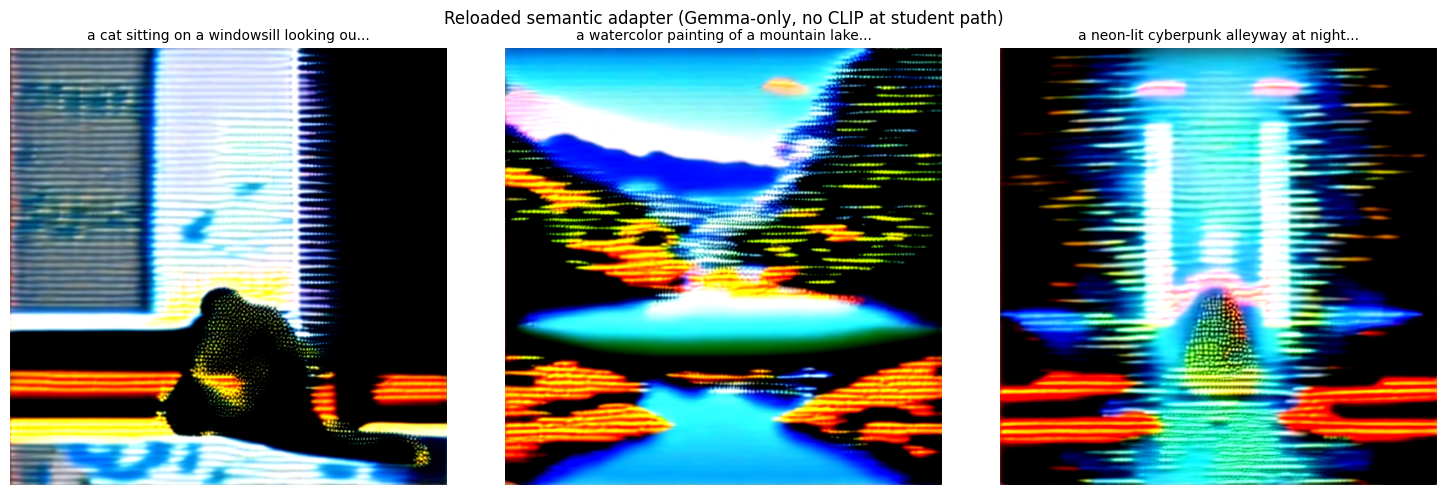

Saved validation grid: /content/drive/MyDrive/gemma3-sd/samples_reloaded_semantic_adapter.png
Final proof sample grid saved: /content/drive/MyDrive/gemma3-sd/samples_reloaded_semantic_adapter.png
Generating reloaded semantic requested test: retrofuturism_cars_popular_mechanics seed=3197632166 cfg=7.0 size=768x960 sampler=DPM++ SDE Karras
DPMSolverSDEScheduler requires the torchsde library but it was not found in your environment. You can install it with pip: `pip install torchsde`
); falling back to DPMSolverMultistepScheduler with Karras sigmas.


Generating semantic-adapter: 100%|██████████| 30/30 [00:24<00:00,  1.22it/s]


DPMSolverSDEScheduler requires the torchsde library but it was not found in your environment. You can install it with pip: `pip install torchsde`
); falling back to DPMSolverMultistepScheduler with Karras sigmas.


Generating semantic-adapter: 100%|██████████| 30/30 [00:24<00:00,  1.23it/s]


Generating reloaded semantic requested test: warrior_princess_poster seed=4267154965 cfg=7.0 size=768x960 sampler=DPM++ SDE Karras
DPMSolverSDEScheduler requires the torchsde library but it was not found in your environment. You can install it with pip: `pip install torchsde`
); falling back to DPMSolverMultistepScheduler with Karras sigmas.


Generating semantic-adapter: 100%|██████████| 30/30 [00:24<00:00,  1.23it/s]


DPMSolverSDEScheduler requires the torchsde library but it was not found in your environment. You can install it with pip: `pip install torchsde`
); falling back to DPMSolverMultistepScheduler with Karras sigmas.


Generating semantic-adapter: 100%|██████████| 30/30 [00:24<00:00,  1.22it/s]


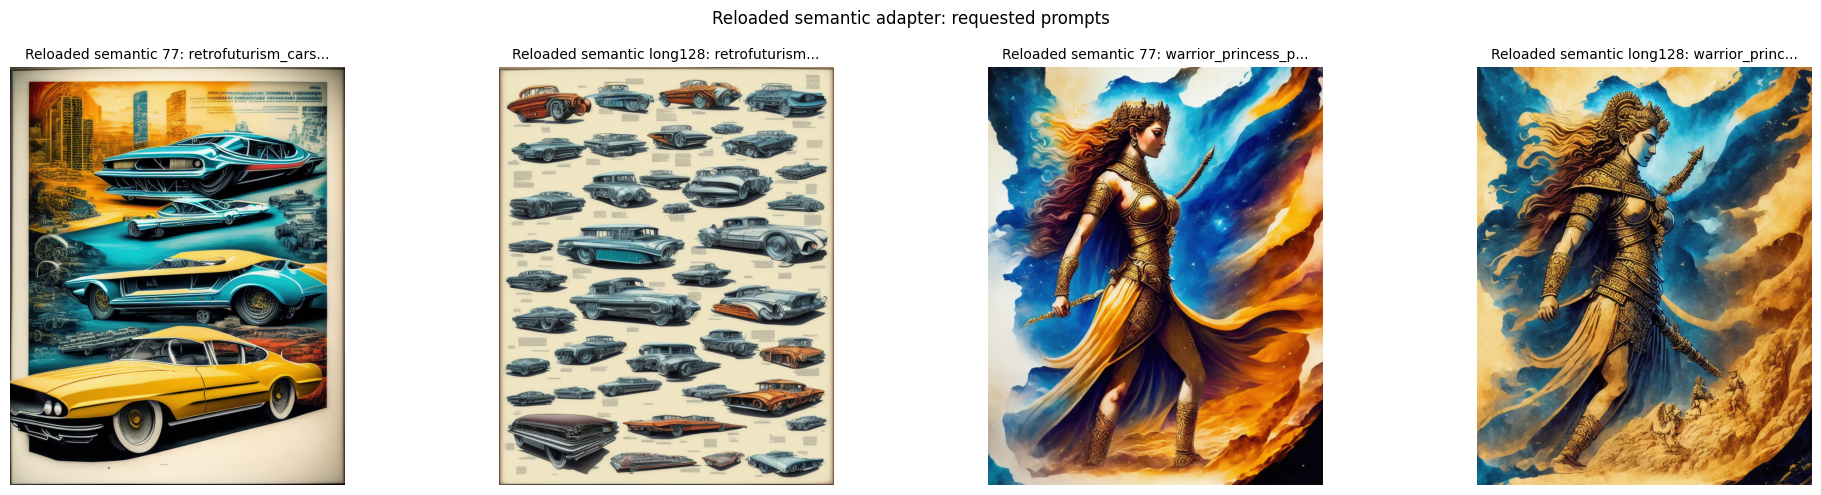

Saved validation grid: /content/drive/MyDrive/gemma3-sd/samples_reloaded_semantic_requested_prompts.png
Requested prompt proof grid saved: /content/drive/MyDrive/gemma3-sd/samples_reloaded_semantic_requested_prompts.png
[reloaded_semantic] student/teacher delta cosine = 0.247569
[reloaded_semantic] student delta norm = 20.0915, teacher delta norm = 2.9910
[reloaded_semantic] delta norm ratio = 6.7174


In [20]:
# @title 5.3 Final Proof from Freshly Reloaded Pruned Checkpoint
# Final artifact evidence must come from reloaded pruned UNet, not live dual graph.

if RUN_FINAL_PROOF and RUN_TRAINING and CONDITIONING_ARCH == "dual_native":
    pruned_path = f"{DRIVE_OUT}/gemma3_sd_gemma_only_pruned.pt"
    pruned_ckpt = torch.load(pruned_path, map_location="cpu")

    # Rebuild from the same StyleJourney base checkpoint before applying Gemma surgery.
    reloaded_pruned_unet, _, _ = load_stylejourney_components(torch_dtype=unet_dtype, target_device=device)
    n = apply_dual_native_attention(reloaded_pruned_unet, pruned_ckpt["gemma_hidden_size"])
    pcount = prune_to_gemma_only(reloaded_pruned_unet, pruned_ckpt["gemma_hidden_size"])
    print(f"Reload pruned surgery applied: dual={n}, pruned={pcount}")

    reloaded_pruned_unet.load_state_dict(pruned_ckpt["unet_state_dict"], strict=True)
    reloaded_pruned_unet.eval()
    dual_left = count_modules_by_predicate(reloaded_pruned_unet, is_dual_native_attention_module)
    gemma_only_count = count_modules_by_predicate(reloaded_pruned_unet, is_gemma_only_attention_module)
    print(f"Reloaded module counts: DualNativeAttention={dual_left}, GemmaOnlyAttention={gemma_only_count}")
    assert dual_left == 0, "Pruned model should have zero DualNativeAttention modules"
    assert gemma_only_count == pcount, "Unexpected GemmaOnlyAttention count after reload"
    print("Pruned Gemma-only checkpoint reload: PASS (strict=True)")

    @torch.no_grad()
    def prompt_sensitivity_gemma_only_unet(target_unet, prompts, seed=123, timestep=500, label="reloaded_pruned"):
        gen = torch.Generator(device=device).manual_seed(seed)
        latent = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype)
        t = torch.tensor([timestep], device=device)
        preds = []
        for ptxt in prompts:
            gh, gm = encode_gemma_prompts([ptxt])
            pred = target_unet(latent, t, encoder_hidden_states=gh, encoder_attention_mask=gm).sample.float()
            preds.append(pred)
        base = preds[0].pow(2).mean().sqrt().item() + 1e-8
        vals = []
        for i in range(len(prompts)):
            for j in range(i + 1, len(prompts)):
                diff = (preds[i] - preds[j]).pow(2).mean().sqrt().item() / base
                vals.append(diff)
                print(f"[{label}] {i} vs {j}: relative diff = {diff:.6f}")
        mean_val = float(np.mean(vals)) if vals else 0.0
        wandb.log({f"validation/{label}_mean_relative_diff": mean_val})
        return mean_val

    with torch.no_grad():
        test_latent = torch.randn(2, 4, 64, 64, device=device, dtype=unet_dtype)
        test_t = torch.tensor([500, 500], device=device).long()
        test_gemma_h, test_gemma_mask = encode_gemma_prompts(["a small red car", ""])
        test_pred = reloaded_pruned_unet(test_latent, test_t, encoder_hidden_states=test_gemma_h, encoder_attention_mask=test_gemma_mask).sample
        assert torch.isfinite(test_pred).all(), "Reloaded pruned forward produced NaN/Inf"
    print("Reloaded pruned finite forward: PASS")

    print("Prompt sensitivity (reloaded pruned Gemma-only):")
    reloaded_mean = prompt_sensitivity_gemma_only_unet(reloaded_pruned_unet, VAL_PROMPTS, label="reloaded_pruned")

    final_imgs = []
    for ptxt in VAL_PROMPTS:
        print(f"Generating reloaded-pruned Gemma-only: {ptxt}")
        final_imgs.append(generate_gemma_only_from_unet(reloaded_pruned_unet, ptxt, desc="reloaded-pruned Gemma-only"))
    final_grid = f"{DRIVE_OUT}/samples_reloaded_pruned_gemma_only.png"
    save_validation_grid(final_imgs, VAL_PROMPTS, final_grid, "Reloaded pruned Gemma-only")
    print(f"Final proof sample grid saved: {final_grid}")
elif CONDITIONING_ARCH == "dual_native":
    print("Final proof skipped. Requires RUN_FINAL_PROOF=True and RUN_TRAINING=True so diagnostic-only runs do not reload untrained artifacts.")

# ── Connector reload proof (ella_gemma_connector mode) ──
if RUN_FINAL_PROOF and CONDITIONING_ARCH == "ella_gemma_connector" and gemma_connector is not None:
    connector_ckpt_path = f"{DRIVE_OUT}/gemma3_sd_connector_final.pt"
    if os.path.exists(connector_ckpt_path):
        connector_ckpt = torch.load(connector_ckpt_path, map_location="cpu")

        # Rebuild fresh connector from config
        cfg = connector_ckpt["connector_config"]
        reloaded_connector = GemmaTimestepSemanticConnector(
            input_dim=cfg["input_dim"],
            width=cfg["width"],
            output_dim=cfg["output_dim"],
            layers=cfg["layers"],
            heads=cfg["heads"],
            num_latents=cfg["num_latents"],
            time_channel=cfg["time_channel"],
            time_embed_dim=cfg["time_embed_dim"],
        ).to(device=device, dtype=unet_dtype).eval()

        missing, unexpected = reloaded_connector.load_state_dict(connector_ckpt["connector_state_dict"], strict=True)
        print(f"Connector reload strict: PASS (missing={len(missing)}, unexpected={len(unexpected)})")

        # Rebuild fresh UNet (no surgery needed)
        reloaded_unet, _, _ = load_stylejourney_components(torch_dtype=unet_dtype, target_device=device)
        reloaded_unet.eval()

        # Smoke forward
        test_g = torch.randn(2, 128, GEMMA_CONNECTOR_INPUT_DIM, device=device, dtype=unet_dtype)
        test_t = torch.randint(0, scheduler.config.num_train_timesteps, (2,), device=device).long()
        test_context = reloaded_connector(test_g, test_t)
        test_latent = torch.randn(2, 4, 64, 64, device=device, dtype=unet_dtype)
        test_pred = reloaded_unet(test_latent, test_t, encoder_hidden_states=test_context).sample
        assert torch.isfinite(test_pred).all(), "Reloaded connector+UNet forward produced NaN/Inf"
        print("Gemma-only connector finite forward: PASS")

        # Generate proof grid. Keep the full denoising loop under inference_mode;
        # otherwise PyTorch retains one UNet graph per diffusion step and OOMs even on 40GB GPUs.
        print("CLIP loaded for final proof: False")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        proof_imgs = []
        with torch.inference_mode():
            for ptxt in VAL_PROMPTS:
                print(f"Generating reloaded connector Gemma-only: {ptxt}")
                # Use reloaded_connector for generation
                gen = torch.Generator(device=device).manual_seed(VAL_SEED)
                infer_scheduler = DPMSolverMultistepScheduler.from_config(scheduler.config)
                infer_scheduler.set_timesteps(VAL_STEPS, device=device)
                cond_g, cond_m = encode_gemma_prompts([ptxt])
                uncond_g, uncond_m = encode_gemma_prompts([""])
                g_h = torch.cat([uncond_g, cond_g], dim=0)
                g_m = torch.cat([uncond_m, cond_m], dim=0)
                latents = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype) * infer_scheduler.init_noise_sigma
                for t_step in tqdm(infer_scheduler.timesteps, desc="Proof reloaded connector"):
                    inp = torch.cat([latents] * 2, dim=0)
                    inp = infer_scheduler.scale_model_input(inp, t_step)
                    t_b = t_step.unsqueeze(0).expand(2).to(device=device)
                    ctx = reloaded_connector(g_h.to(dtype=unet_dtype), t_b, g_m)
                    pred = reloaded_unet(inp, t_step, encoder_hidden_states=ctx).sample
                    u, p = pred.chunk(2)
                    pred = u + VAL_GUIDANCE * (p - u)
                    latents = infer_scheduler.step(pred, t_step, latents).prev_sample
                proof_imgs.append(decode_latents_to_image(latents))
        proof_grid = f"{DRIVE_OUT}/samples_reloaded_connector_gemma_only.png"
        save_validation_grid(proof_imgs, VAL_PROMPTS, proof_grid, "Reloaded connector Gemma-only (no CLIP)")
        print(f"Final proof sample grid saved: {proof_grid}")
    else:
        print(f"Connector checkpoint not found: {connector_ckpt_path}")
        print("Connector reload proof: SKIPPED (no checkpoint)")


# ── Semantic adapter reload proof (gemma_clip_semantic_adapter mode) ──
if RUN_FINAL_PROOF and CONDITIONING_ARCH == "gemma_clip_semantic_adapter" and semantic_adapter is not None:
    semantic_ckpt_path = f"{DRIVE_OUT}/gemma_semantic_adapter_phase1.pt"
    if os.path.exists(semantic_ckpt_path):
        semantic_ckpt = torch.load(semantic_ckpt_path, map_location="cpu")
        cfg = semantic_ckpt["config"]
        reloaded_semantic_adapter = GemmaToClipSemanticAdapter(
            gemma_dim=cfg["gemma_dim"],
            clip_dim=cfg["clip_dim"],
            width=cfg["width"],
            num_clip_tokens=cfg["num_clip_tokens"],
            layers=cfg["layers"],
            heads=cfg["heads"],
            ff_mult=cfg["ff_mult"],
            dropout=cfg["dropout"],
        ).to(device=device, dtype=unet_dtype).eval()
        reloaded_semantic_adapter.load_state_dict(semantic_ckpt["state_dict"], strict=True)
        print("Semantic adapter reload proof: PASS (strict=True)")
        with torch.no_grad():
            gh, gm = encode_gemma_prompts(["a small red car", ""])
            ctx = reloaded_semantic_adapter(gh.to(dtype=unet_dtype), gm)
            assert ctx.shape == (2, SEMANTIC_NUM_TOKENS, SEMANTIC_WIDTH), ctx.shape
            test_latent = torch.randn(2, 4, 64, 64, device=device, dtype=unet_dtype)
            test_t = torch.tensor([500, 500], device=device).long()
            test_pred = unet(test_latent, test_t, encoder_hidden_states=ctx).sample
            assert torch.isfinite(test_pred).all(), "Reloaded semantic adapter + frozen UNet forward produced NaN/Inf"
        print("Reloaded semantic adapter finite UNet forward: PASS")
        del ctx, test_latent, test_t, test_pred
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        proof_imgs = []
        # Full denoising proof must be inference-only. Without this, autograd stores
        # all UNet activations across scheduler steps and OOMs around step ~11/30 on 40GB GPUs.
        with torch.inference_mode():
            for ptxt in VAL_PROMPTS:
                print(f"Generating reloaded semantic adapter: {ptxt}")
                gen = torch.Generator(device=device).manual_seed(VAL_SEED)
                infer_scheduler = DPMSolverMultistepScheduler.from_config(scheduler.config)
                infer_scheduler.set_timesteps(VAL_STEPS, device=device)
                cond_g, cond_m = encode_gemma_prompts([ptxt])
                uncond_g, uncond_m = encode_gemma_prompts([""])
                g_h = torch.cat([uncond_g, cond_g], dim=0)
                g_m = torch.cat([uncond_m, cond_m], dim=0)
                latents = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype) * infer_scheduler.init_noise_sigma
                for t_step in tqdm(infer_scheduler.timesteps, desc="Proof reloaded semantic"):
                    inp = torch.cat([latents] * 2, dim=0)
                    inp = infer_scheduler.scale_model_input(inp, t_step)
                    ctx = reloaded_semantic_adapter(g_h.to(dtype=unet_dtype), g_m)
                    pred = unet(inp, t_step, encoder_hidden_states=ctx).sample
                    u, p = pred.chunk(2)
                    pred = u + VAL_GUIDANCE * (p - u)
                    latents = infer_scheduler.step(pred, t_step, latents).prev_sample
                proof_imgs.append(decode_latents_to_image(latents))
        proof_grid = f"{DRIVE_OUT}/samples_reloaded_semantic_adapter.png"
        save_validation_grid(proof_imgs, VAL_PROMPTS, proof_grid, "Reloaded semantic adapter (Gemma-only, no CLIP at student path)")
        print(f"Final proof sample grid saved: {proof_grid}")
        live_semantic_adapter = semantic_adapter
        semantic_adapter = reloaded_semantic_adapter
        try:
            if globals().get("TEST_GENERATION_CASES") and "generate_semantic_adapter" in globals():
                requested_imgs = []
                requested_labels = []
                for case in TEST_GENERATION_CASES:
                    kwargs = dict(
                        steps=case.get("steps", VAL_STEPS),
                        guidance=case.get("guidance", VAL_GUIDANCE),
                        seed=case.get("seed", VAL_SEED),
                        negative_prompt=case.get("negative_prompt", ""),
                        width=case.get("width", 512),
                        height=case.get("height", 512),
                        sampler=case.get("sampler", None),
                    )
                    print(f"Generating reloaded semantic requested test: {case['name']} seed={kwargs['seed']} cfg={kwargs['guidance']} size={kwargs['width']}x{kwargs['height']} sampler={case.get('sampler')}")
                    requested_imgs.append(generate_semantic_adapter(case["prompt"], use_long_tokens=False, **kwargs))
                    requested_labels.append(f"Reloaded semantic 77: {case['name']}")
                    if RUN_LONG_TOKEN_PHASE and long_token_resampler is not None:
                        requested_imgs.append(generate_semantic_adapter(case["prompt"], use_long_tokens=True, **kwargs))
                        requested_labels.append(f"Reloaded semantic long128: {case['name']}")
                requested_grid = f"{DRIVE_OUT}/samples_reloaded_semantic_requested_prompts.png"
                save_validation_grid(requested_imgs, requested_labels, requested_grid, "Reloaded semantic adapter: requested prompts")
                print(f"Requested prompt proof grid saved: {requested_grid}")
            compute_teacher_student_delta_alignment(VAL_PROMPTS[0], label="reloaded_semantic")
        finally:
            semantic_adapter = live_semantic_adapter
    else:
        print(f"Semantic adapter checkpoint not found: {semantic_ckpt_path}")
        print("Semantic adapter reload proof: SKIPPED (no checkpoint)")


## Current Contract / Handoff Notes

This notebook is one integrated diagnostic + training artifact for SD1.5 CLIP → Gemma conditioning replacement.

Non-negotiable contract:
- Student forward is Gemma-only: `clip_scale=0.0`, `gemma_scale=1.0`.
- CLIP is allowed only as a frozen teacher/scaffold during training diagnostics/losses.
- Do not use the failed CLIP→Gemma linear bake path.
- Gemma masks are propagated in training, generation, and pruned inference.
- Gemma Q and OUT are copied from the original CLIP branch; Gemma K/V are the native trainable text-side path.
- Text-delta loss trains the student to match CLIP's conditional-unconditional effect.
- Final proof must come from a freshly reloaded pruned Gemma-only checkpoint.

Quality gate:
- Treat lower MSE as insufficient evidence. Continue scaling only if Gemma/CLIP prompt-sensitivity ratio and fixed validation grids improve.
- If sensitivity stays flat while loss falls, stop and change representation/objective (for example Gemma layer choice), not whole-UNet finetune.

Artifact status:
- The pruned checkpoint is a custom Gemma-only UNet checkpoint requiring this notebook's surgery/reload helper.
- It is not yet a standalone CLIP-free Diffusers pipeline.

- Cell 5.2 prunes the live UNet as a terminal save step; rerun cells 3.x before re-running dual-graph diagnostics after saving.

- `TRAIN_BATCH_SIZE` default is 2. Text-delta uses cond/uncond pairs, so actual UNet batch is `2 * TRAIN_BATCH_SIZE`; increase to 3/4 only after watching peak VRAM.

- `short_train` is a controlled falsifier: Phase A stops at 100 optimizer steps, Phase B stops at 200 optimizer steps, and fixed Gemma-only grids are saved every 50 optimizer steps by default.

- ELLA-adjusted path intentionally defers CLIP/Gemma token-count curriculum. The preferred next architecture is Gemma → timestep-aware semantic connector → frozen original UNet cross-attention, with CLIP used only as optional teacher/diagnostic and not loaded for final connector proof.
- `CONDITIONING_ARCH="dual_native"` remains available as the no-connector/future-UNet-training option; `CONDITIONING_ARCH="gemma_clip_semantic_adapter"` is the current default semantic-adapter path.

- Overfit validation uses exact captions sampled from the deterministic training subset (`TRAIN_VAL_PROMPTS`) as the primary grid. Generic `VAL_PROMPTS` are only held-out controls; failure on generic controls is not a failure to overfit.
